# Earthworm classification under cue suppression

This notebook analyses the matched-condition training experiments and compares them with stress tests applied to models trained on original RGB images.

The experimental design includes:

- a dense colour-saturation series from original RGB to greyscale;
- channel shuffling;
- bilateral filtering;
- Gaussian blur;
- patch shuffling;
- ConvNeXt-Base and ViT-B/16 architectures;
- genus, species, age/life-stage, and optional mean macro-F1.

## Questions addressed

1. How does classification performance change as colour saturation is removed?
2. How much of the stress-test loss is recovered by matched-condition training?
3. Do ConvNeXt and ViT differ in their sensitivity to colour, texture, or spatial-structure perturbations?
4. Which tasks depend most strongly on each visual cue?

**Interpretive caution:** matched-condition curves do not measure robustness to an unseen perturbation. Each point represents a separately trained model. Stress-test curves quantify distribution-shift sensitivity, whereas matched-condition curves quantify performance when the altered image distribution is available during training.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

# Place this notebook in the aggregation output directory, or change this path.
PROJECT_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "config.yaml").is_file()), Path.cwd())
RESULTS_ROOT = PROJECT_ROOT / "outputs_slurm/persistent_cache_sweep_20260713_150423"

# Optional explicit paths. Leave as None to use automatic discovery.
MANIFEST_PATH: Path | None = None
MATCHED_LONG_PATH: Path | None = None
CUE_RATIOS_PATH: Path | None = None
COMPARISON_PATH: Path | None = None

FIGURE_DIR = RESULTS_ROOT / "figures_cue_suppression"
TABLE_DIR = RESULTS_ROOT / "tables_cue_suppression"

SAVE_FIGURES = True
SAVE_TABLES = True
FIGURE_DPI = 300

TASK_ORDER = ["genus", "species", "age", "mean"]
PRIMARY_TASK = "species"
INCLUDE_MEAN_TASK = True

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Results directory:", RESULTS_ROOT.resolve())


Results directory: /faststorage/project/worm-species/source/outputs_slurm/persistent_cache_sweep_20260713_150423


## 1. File discovery and robust loading

The aggregation script normally creates:

- `matched_condition_macro_f1_long.csv`
- `rgb_model_cue_suppression_macro_f1_ratios.csv`
- `matched_vs_rgb_stress_test.csv`

The notebook can also read a headerless export of `matched_condition_macro_f1_long.csv`.


In [2]:
MATCHED_LONG_COLUMNS = [
    "run_name",
    "model",
    "task",
    "train_condition",
    "train_feature",
    "train_transform",
    "train_strength",
    "matched_test_macro_f1",
    "best_epoch",
    "best_val_score",
    "selection_metric",
    "out_dir",
    "summary_path",
]


def first_existing(paths: Iterable[Path]) -> Path | None:
    for path in paths:
        if path.exists():
            return path
    return None


def discover_condition_manifest(root: Path) -> Path | None:
    preferred = first_existing([
        root / "condition_manifest.json",
        root / "matched_condition_manifest.json",
        root / "sweep_manifest.json",
        root / "conditions.json",
    ])
    if preferred is not None:
        return preferred

    for path in sorted(root.glob("*.json")):
        try:
            payload = json.loads(path.read_text())
        except Exception:
            continue
        if isinstance(payload, dict) and isinstance(payload.get("conditions"), list):
            return path
    return None


def discover_headerless_matched_file(root: Path) -> Path | None:
    for path in sorted([*root.glob("*.txt"), *root.glob("*.csv")]):
        if path.name in {
            "matched_condition_macro_f1_long.csv",
            "rgb_model_cue_suppression_macro_f1_ratios.csv",
            "matched_vs_rgb_stress_test.csv",
        }:
            continue

        try:
            first_line = path.open().readline().strip()
        except Exception:
            continue

        if len(first_line.split(",")) == len(MATCHED_LONG_COLUMNS):
            return path
    return None


manifest_path = MANIFEST_PATH or discover_condition_manifest(RESULTS_ROOT)
matched_long_path = MATCHED_LONG_PATH or first_existing([
    RESULTS_ROOT / "matched_condition_macro_f1_long.csv",
    discover_headerless_matched_file(RESULTS_ROOT) or Path("__missing__"),
])
cue_ratios_path = CUE_RATIOS_PATH or first_existing([
    RESULTS_ROOT / "rgb_model_cue_suppression_macro_f1_ratios.csv",
])
comparison_path = COMPARISON_PATH or first_existing([
    RESULTS_ROOT / "matched_vs_rgb_stress_test.csv",
])

print("Manifest:", manifest_path)
print("Matched-condition long table:", matched_long_path)
print("RGB stress-test ratio table:", cue_ratios_path)
print("Precomputed comparison table:", comparison_path)


Manifest: outputs_slurm/persistent_cache_sweep_20260713_150423/dual_cue_experiment_plan.json
Matched-condition long table: outputs_slurm/persistent_cache_sweep_20260713_150423/matched_condition_macro_f1_long.csv
RGB stress-test ratio table: outputs_slurm/persistent_cache_sweep_20260713_150423/rgb_model_cue_suppression_macro_f1_ratios.csv
Precomputed comparison table: outputs_slurm/persistent_cache_sweep_20260713_150423/matched_vs_rgb_stress_test.csv


In [3]:
def read_csv_flexible(
    path: Path | None,
    expected_columns: list[str] | None = None,
) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()

    if expected_columns is None:
        frame = pd.read_csv(path)
        print(f"Loaded {path.name}: {len(frame):,} rows")
        return frame

    with path.open() as handle:
        first_line = handle.readline().strip()

    first_fields = [field.strip() for field in first_line.split(",")]
    has_expected_header = set(expected_columns).issubset(first_fields)

    if has_expected_header:
        frame = pd.read_csv(path)
    elif len(first_fields) == len(expected_columns):
        frame = pd.read_csv(path, header=None, names=expected_columns)
    else:
        frame = pd.read_csv(path)

    print(f"Loaded {path.name}: {len(frame):,} rows")
    return frame


def load_manifest(path: Path | None) -> tuple[dict, pd.DataFrame]:
    if path is None or not path.exists():
        return {}, pd.DataFrame()

    payload = json.loads(path.read_text())
    conditions = pd.DataFrame(payload.get("conditions", []))

    if not conditions.empty:
        conditions = conditions.rename(columns={
            "feature": "manifest_feature",
            "transform": "manifest_transform",
            "strength": "manifest_strength",
            "retention": "manifest_retention",
        })

    print(
        f"Loaded {path.name}: "
        f"{len(conditions):,} conditions, "
        f"{payload.get('n_total_runs', 'unknown')} expected runs"
    )
    return payload, conditions


manifest, condition_metadata = load_manifest(manifest_path)
matched_long_raw = read_csv_flexible(
    matched_long_path,
    expected_columns=MATCHED_LONG_COLUMNS,
)
cue_ratios_raw = read_csv_flexible(cue_ratios_path)
comparison_raw = read_csv_flexible(comparison_path)

display(pd.DataFrame({
    "dataset": [
        "condition metadata",
        "matched-condition results",
        "RGB stress-test ratios",
        "precomputed comparison",
    ],
    "rows": [
        len(condition_metadata),
        len(matched_long_raw),
        len(cue_ratios_raw),
        len(comparison_raw),
    ],
    "columns": [
        len(condition_metadata.columns),
        len(matched_long_raw.columns),
        len(cue_ratios_raw.columns),
        len(comparison_raw.columns),
    ],
}))


Loaded dual_cue_experiment_plan.json: 112 conditions, 224 expected runs
Loaded matched_condition_macro_f1_long.csv: 896 rows
Loaded rgb_model_cue_suppression_macro_f1_ratios.csv: 684 rows
Loaded matched_vs_rgb_stress_test.csv: 684 rows


,dataset,rows,columns
0,condition metadata,112,12
1,matched-condition results,896,13
2,RGB stress-test ratios,684,14
3,precomputed comparison,684,24


## 2. Standardise experimental metadata

For saturation experiments:

\[
\text{retained saturation} = 1 - \text{suppression strength}.
\]

The condition names encode retained saturation directly: for example, `saturation_003pct` contains 3% of the original saturation, while its suppression strength is 0.97.


In [4]:
def pretty_model_name(value: object) -> str:
    if pd.isna(value):
        return "Unknown"

    text = str(value)
    mapping = {
        "convnext_base": "ConvNeXt-Base",
        "vit_b_16": "ViT-B/16",
    }
    return mapping.get(text.lower(), text.replace("_", " "))


def retention_from_condition(condition: object) -> float:
    if pd.isna(condition):
        return float("nan")

    text = str(condition).strip().lower()

    if text in {"original", "rgb", "baseline"}:
        return 1.0
    if text in {"grayscale", "greyscale"}:
        return 0.0

    match = re.fullmatch(r"saturation_(\d{3})pct", text)
    if match:
        return float(match.group(1)) / 100.0

    return float("nan")


def readable_condition(value: object) -> str:
    if pd.isna(value):
        return "Unknown"

    text = str(value)

    if text == "original":
        return "Original RGB"
    if text in {"grayscale", "greyscale"}:
        return "Greyscale"

    saturation = re.fullmatch(r"saturation_(\d{3})pct", text)
    if saturation:
        return f"{int(saturation.group(1))}% saturation"

    replacements = {
        "channel_shuffle_201": "Channel shuffle (2,0,1)",
        "bilateral_d5_c25_s25": "Bilateral: d=5, σ=25",
        "bilateral_d7_c50_s50": "Bilateral: d=7, σ=50",
        "bilateral_d9_c100_s100": "Bilateral: d=9, σ=100",
        "gaussian_sigma_0.5": "Gaussian blur: σ=0.5",
        "gaussian_sigma_1": "Gaussian blur: σ=1",
        "gaussian_sigma_2": "Gaussian blur: σ=2",
        "gaussian_sigma_4": "Gaussian blur: σ=4",
        "patch_shuffle_grid_2": "Patch shuffle: 2×2",
        "patch_shuffle_grid_4": "Patch shuffle: 4×4",
        "patch_shuffle_grid_8": "Patch shuffle: 8×8",
    }
    return replacements.get(text, text.replace("_", " "))


def add_common_columns(
    frame: pd.DataFrame,
    condition_col: str,
    feature_col: str | None,
    transform_col: str | None,
    strength_col: str | None,
) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    out = frame.copy()

    if "model" in out.columns:
        out["model_label"] = out["model"].map(pretty_model_name)

    out["condition"] = out[condition_col].astype(str)

    if not condition_metadata.empty:
        metadata = condition_metadata.copy()
        keep = [
            column for column in [
                "condition",
                "manifest_feature",
                "manifest_transform",
                "manifest_strength",
                "manifest_retention",
                "order",
                "diameter",
                "sigma_colour",
                "sigma_space",
                "sigma",
                "grid_size",
                "seed",
            ]
            if column in metadata.columns
        ]
        out = out.merge(
            metadata[keep],
            on="condition",
            how="left",
            validate="many_to_one",
        )

    source_feature = (
        out[feature_col]
        if feature_col is not None and feature_col in out.columns
        else pd.Series(pd.NA, index=out.index)
    )
    source_transform = (
        out[transform_col]
        if transform_col is not None and transform_col in out.columns
        else pd.Series(pd.NA, index=out.index)
    )
    source_strength = (
        pd.to_numeric(out[strength_col], errors="coerce")
        if strength_col is not None and strength_col in out.columns
        else pd.Series(np.nan, index=out.index)
    )

    manifest_feature = out.get(
        "manifest_feature",
        pd.Series(pd.NA, index=out.index),
    )
    manifest_transform = out.get(
        "manifest_transform",
        pd.Series(pd.NA, index=out.index),
    )
    manifest_strength = pd.to_numeric(
        out.get("manifest_strength", pd.Series(np.nan, index=out.index)),
        errors="coerce",
    )
    manifest_retention = pd.to_numeric(
        out.get("manifest_retention", pd.Series(np.nan, index=out.index)),
        errors="coerce",
    )

    out["feature_group"] = manifest_feature.combine_first(source_feature)
    out["transform_name"] = manifest_transform.combine_first(source_transform)
    out["perturbation_strength"] = manifest_strength.combine_first(source_strength)

    inferred_retention = out["condition"].map(retention_from_condition)
    out["retained_saturation"] = manifest_retention.combine_first(inferred_retention)

    out.loc[out["condition"] == "original", "retained_saturation"] = 1.0
    out.loc[
        out["condition"].isin(["grayscale", "greyscale"]),
        "retained_saturation",
    ] = 0.0

    out["saturation_suppression"] = 1.0 - out["retained_saturation"]
    out["condition_label"] = out["condition"].map(readable_condition)

    if "task" in out.columns:
        out["task"] = out["task"].astype(str).str.lower()
        if not INCLUDE_MEAN_TASK:
            out = out[out["task"] != "mean"].copy()

    return out


matched_long = add_common_columns(
    matched_long_raw,
    condition_col="train_condition",
    feature_col="train_feature",
    transform_col="train_transform",
    strength_col="train_strength",
)

cue_ratios = add_common_columns(
    cue_ratios_raw,
    condition_col="condition",
    feature_col="feature",
    transform_col="transform",
    strength_col="strength",
)

display(matched_long.head())


,run_name,model,task,train_condition,train_feature,train_transform,train_strength,matched_test_macro_f1,best_epoch,best_val_score,selection_metric,out_dir,summary_path,model_label,condition,manifest_feature,manifest_transform,manifest_strength,manifest_retention,order,diameter,sigma_colour,sigma_space,sigma,grid_size,seed,feature_group,transform_name,perturbation_strength,retained_saturation,saturation_suppression,condition_label
0,convnext_base__rel_path_seg__genus__1426341c_b...,convnext_base,genus,original,baseline,original,0.000,0.956,15,0.888,mean_macro_f1,/tmp/49375468/worm_species/outputs/run_000/con...,run_000/convnext_base__rel_path_seg__genus__14...,ConvNeXt-Base,original,baseline,original,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline,original,0.000,1.000,0.000,Original RGB
1,convnext_base__rel_path_seg__genus__1426341c_b...,convnext_base,species,original,baseline,original,0.000,0.762,15,0.888,mean_macro_f1,/tmp/49375468/worm_species/outputs/run_000/con...,run_000/convnext_base__rel_path_seg__genus__14...,ConvNeXt-Base,original,baseline,original,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline,original,0.000,1.000,0.000,Original RGB
2,convnext_base__rel_path_seg__genus__1426341c_b...,convnext_base,age,original,baseline,original,0.000,0.824,15,0.888,mean_macro_f1,/tmp/49375468/worm_species/outputs/run_000/con...,run_000/convnext_base__rel_path_seg__genus__14...,ConvNeXt-Base,original,baseline,original,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline,original,0.000,1.000,0.000,Original RGB
3,convnext_base__rel_path_seg__genus__1426341c_b...,convnext_base,mean,original,baseline,original,0.000,0.847,15,0.888,mean_macro_f1,/tmp/49375468/worm_species/outputs/run_000/con...,run_000/convnext_base__rel_path_seg__genus__14...,ConvNeXt-Base,original,baseline,original,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline,original,0.000,1.000,0.000,Original RGB
4,convnext_base__rel_path_seg__genus__764e0e2d_b...,convnext_base,genus,channel_shuffle_201,colour,channel_shuffle,1.000,0.976,20,0.891,mean_macro_f1,/tmp/49376299/worm_species/outputs/run_101/con...,run_101/convnext_base__rel_path_seg__genus__76...,ConvNeXt-Base,channel_shuffle_201,colour,channel_shuffle,1.000,NaN,"[2, 0, 1]",NaN,NaN,NaN,NaN,NaN,NaN,colour,channel_shuffle,1.000,NaN,NaN,"Channel shuffle (2,0,1)"


## 3. Construct or standardise the matched-versus-stress-test comparison

The comparison is matched on architecture, task, and perturbation condition. The original and greyscale conditions are also given aliases corresponding to 100% and 0% retained saturation when required.


In [5]:
def add_endpoint_aliases(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    frames = [frame.copy()]

    original = frame[frame["condition"] == "original"].copy()
    if not original.empty:
        original["condition"] = "saturation_100pct"
        original["condition_label"] = "100% saturation"
        original["retained_saturation"] = 1.0
        original["condition_alias_of"] = "original"
        frames.append(original)

    greyscale = frame[
        frame["condition"].isin(["grayscale", "greyscale"])
    ].copy()
    if not greyscale.empty:
        greyscale["condition"] = "saturation_000pct"
        greyscale["condition_label"] = "0% saturation"
        greyscale["retained_saturation"] = 0.0
        greyscale["condition_alias_of"] = "grayscale"
        frames.append(greyscale)

    return pd.concat(frames, ignore_index=True)


def build_comparison_table(
    matched: pd.DataFrame,
    stress: pd.DataFrame,
) -> pd.DataFrame:
    if matched.empty or stress.empty:
        return pd.DataFrame()

    matched_work = add_endpoint_aliases(matched)

    matched_summary = (
        matched_work
        .groupby(
            [
                "model",
                "model_label",
                "task",
                "condition",
                "feature_group",
                "transform_name",
                "perturbation_strength",
                "retained_saturation",
                "condition_label",
            ],
            dropna=False,
        )
        .agg(
            matched_test_macro_f1=("matched_test_macro_f1", "mean"),
            matched_n_runs=("matched_test_macro_f1", "count"),
            mean_best_epoch=("best_epoch", "mean"),
            mean_best_val_score=("best_val_score", "mean"),
        )
        .reset_index()
    )

    stress_summary = (
        stress
        .groupby(
            ["model", "task", "condition"],
            dropna=False,
        )
        .agg(
            rgb_model_test_macro_f1=("macro_f1", "mean"),
            rgb_original_macro_f1=("original_macro_f1", "mean"),
            rgb_ratio_to_original=("ratio_to_original", "mean"),
            rgb_relative_drop=("relative_drop", "mean"),
            rgb_n_rows=("macro_f1", "count"),
        )
        .reset_index()
    )

    out = matched_summary.merge(
        stress_summary,
        on=["model", "task", "condition"],
        how="inner",
        validate="one_to_one",
    )

    out["adaptation_gain_macro_f1"] = (
        out["matched_test_macro_f1"]
        - out["rgb_model_test_macro_f1"]
    )

    out["matched_ratio_to_rgb_original"] = np.where(
        out["rgb_original_macro_f1"].notna()
        & out["matched_test_macro_f1"].notna()
        & out["rgb_original_macro_f1"].ne(0),
        out["matched_test_macro_f1"] / out["rgb_original_macro_f1"],
        np.nan,
    )

    out["matched_relative_drop_from_rgb_original"] = (
        1.0 - out["matched_ratio_to_rgb_original"]
    )
    return out


if comparison_raw.empty:
    comparison = build_comparison_table(matched_long, cue_ratios)
    print(f"Constructed comparison table: {len(comparison):,} rows")
else:
    comparison = add_common_columns(
        comparison_raw,
        condition_col="train_condition",
        feature_col="test_feature",
        transform_col="test_transform",
        strength_col="test_strength",
    )
    print(f"Loaded precomputed comparison table: {len(comparison):,} rows")

display(comparison.head())


Loaded precomputed comparison table: 684 rows


,run_name,model,task,train_condition,train_feature,train_transform,train_strength,matched_test_macro_f1,best_epoch,best_val_score,selection_metric,out_dir,summary_path,condition_alias_of,test_feature,test_transform,test_strength,rgb_model_test_macro_f1,rgb_original_macro_f1,rgb_ratio_to_original,rgb_relative_drop,adaptation_gain_macro_f1,matched_ratio_to_rgb_original,matched_relative_drop_from_rgb_original,model_label,condition,manifest_feature,manifest_transform,manifest_strength,manifest_retention,order,diameter,sigma_colour,sigma_space,sigma,grid_size,seed,feature_group,transform_name,perturbation_strength,retained_saturation,saturation_suppression,condition_label
0,convnext_base__rel_path_seg__genus__1426341c_b...,convnext_base,age,original,baseline,original,0.000,0.824,15,0.888,mean_macro_f1,/tmp/49375468/worm_species/outputs/run_000/con...,run_000/convnext_base__rel_path_seg__genus__14...,NaN,baseline,original,0.000,0.824,0.824,1.000,0.000,0.000,1.000,0.000,ConvNeXt-Base,original,baseline,original,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline,original,0.000,1.000,0.000,Original RGB
1,convnext_base__rel_path_seg__genus__764e0e2d_b...,convnext_base,age,channel_shuffle_201,colour,channel_shuffle,1.000,0.805,20,0.891,mean_macro_f1,/tmp/49376299/worm_species/outputs/run_101/con...,run_101/convnext_base__rel_path_seg__genus__76...,NaN,colour,channel_shuffle,1.000,0.437,0.824,0.530,0.470,0.369,0.977,0.023,ConvNeXt-Base,channel_shuffle_201,colour,channel_shuffle,1.000,NaN,"[2, 0, 1]",NaN,NaN,NaN,NaN,NaN,NaN,colour,channel_shuffle,1.000,NaN,NaN,"Channel shuffle (2,0,1)"
2,convnext_base__rel_path_seg__genus__8f475028_b...,convnext_base,age,grayscale,colour,grayscale,1.000,0.813,45,0.825,mean_macro_f1,/tmp/49376298/worm_species/outputs/run_100/con...,run_100/convnext_base__rel_path_seg__genus__8f...,NaN,colour,grayscale,1.000,0.573,0.824,0.695,0.305,0.240,0.986,0.014,ConvNeXt-Base,grayscale,colour,grayscale,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colour,grayscale,1.000,0.000,1.000,Greyscale
3,convnext_base__rel_path_seg__genus__1426341c_b...,convnext_base,age,saturation_100pct,baseline,original,0.000,0.824,15,0.888,mean_macro_f1,/tmp/49375468/worm_species/outputs/run_000/con...,run_000/convnext_base__rel_path_seg__genus__14...,original,colour,saturation,0.000,0.824,0.824,1.000,0.000,0.000,1.000,0.000,ConvNeXt-Base,saturation_100pct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colour,saturation,0.000,1.000,0.000,100% saturation
4,convnext_base__rel_path_seg__genus__8f297317_b...,convnext_base,age,saturation_099pct,colour,saturation,0.010,0.816,20,0.880,mean_macro_f1,/tmp/49375469/worm_species/outputs/run_001/con...,run_001/convnext_base__rel_path_seg__genus__8f...,NaN,colour,saturation,0.010,0.827,0.824,1.003,-0.003,-0.011,0.990,0.010,ConvNeXt-Base,saturation_099pct,colour,saturation,0.010,0.990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,colour,saturation,0.010,0.990,0.010,99% saturation


## 4. Experimental coverage and data-quality checks

In [6]:
def ordered_tasks(frame: pd.DataFrame) -> list[str]:
    if frame.empty or "task" not in frame.columns:
        return []

    present = frame["task"].dropna().unique().tolist()
    ordered = [task for task in TASK_ORDER if task in present]
    ordered.extend(sorted(task for task in present if task not in ordered))
    return ordered


observed_run_count = (
    matched_long["run_name"].nunique()
    if "run_name" in matched_long.columns
    else np.nan
)

coverage_summary = pd.DataFrame({
    "quantity": [
        "Expected conditions",
        "Expected model–condition runs",
        "Observed unique model–condition runs",
        "Observed task-level rows",
    ],
    "value": [
        manifest.get("n_unique_training_conditions", np.nan),
        manifest.get("n_total_runs", np.nan),
        observed_run_count,
        len(matched_long),
    ],
})
display(coverage_summary)

if not matched_long.empty:
    coverage = (
        matched_long
        .groupby(["model_label", "condition"])["task"]
        .nunique()
        .unstack("model_label")
        .sort_index()
    )
    display(coverage)

    missing_core = matched_long[
        matched_long[
            ["model", "task", "condition", "matched_test_macro_f1"]
        ].isna().any(axis=1)
    ]
    print("Rows missing core fields:", len(missing_core))

    unexpected_saturation = matched_long[
        matched_long["transform_name"].eq("saturation")
        & ~matched_long["retained_saturation"].between(0, 1)
    ]
    print("Saturation rows without valid retention:", len(unexpected_saturation))

    duplicates = matched_long[
        matched_long.duplicated(
            ["run_name", "task"],
            keep=False,
        )
    ]
    print("Duplicate run–task rows:", len(duplicates))


,quantity,value
0,Expected conditions,112
1,Expected model–condition runs,224
2,Observed unique model–condition runs,224
3,Observed task-level rows,896


model_label,ConvNeXt-Base,ViT-B/16
condition,,
bilateral_d5_c25_s25,4,4
bilateral_d7_c50_s50,4,4
bilateral_d9_c100_s100,4,4
channel_shuffle_201,4,4
gaussian_sigma_0.5,4,4
...,...,...
saturation_095pct,4,4
saturation_096pct,4,4
saturation_097pct,4,4


Rows missing core fields: 0
Saturation rows without valid retention: 0
Duplicate run–task rows: 0


## 5. Plotting and export helpers

In [7]:
def save_figure(fig: plt.Figure, filename: str) -> None:
    if not SAVE_FIGURES:
        return

    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print("Saved:", path)


def save_table(frame: pd.DataFrame, filename: str) -> None:
    if not SAVE_TABLES:
        return

    path = TABLE_DIR / filename
    frame.to_csv(path, index=False)
    print("Saved:", path)


def aggregate_metric(
    frame: pd.DataFrame,
    value_col: str,
    group_cols: list[str],
) -> pd.DataFrame:
    required = [*group_cols, value_col]
    clean = frame.dropna(subset=[
        column for column in required if column in frame.columns
    ])

    out = (
        clean
        .groupby(group_cols, dropna=False)[value_col]
        .agg(mean="mean", sd="std", n="count")
        .reset_index()
    )
    out["se"] = out["sd"] / np.sqrt(out["n"])
    return out


def add_zero_and_one_guides(ax: plt.Axes) -> None:
    ax.axvline(0.0, linewidth=0.8, linestyle=":")
    ax.axvline(1.0, linewidth=0.8, linestyle=":")
    ax.grid(alpha=0.25)


def saturation_subset(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    return frame[
        frame["retained_saturation"].notna()
        & frame["condition"].isin(
            ["original", "grayscale", "greyscale"]
        )
        | frame["transform_name"].eq("saturation")
        | frame["condition"].str.startswith("saturation_", na=False)
    ].copy()


## 6. Matched-condition saturation curves

Each point is a separately trained model evaluated under the same saturation condition used for training.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/matched_saturation_curves.png


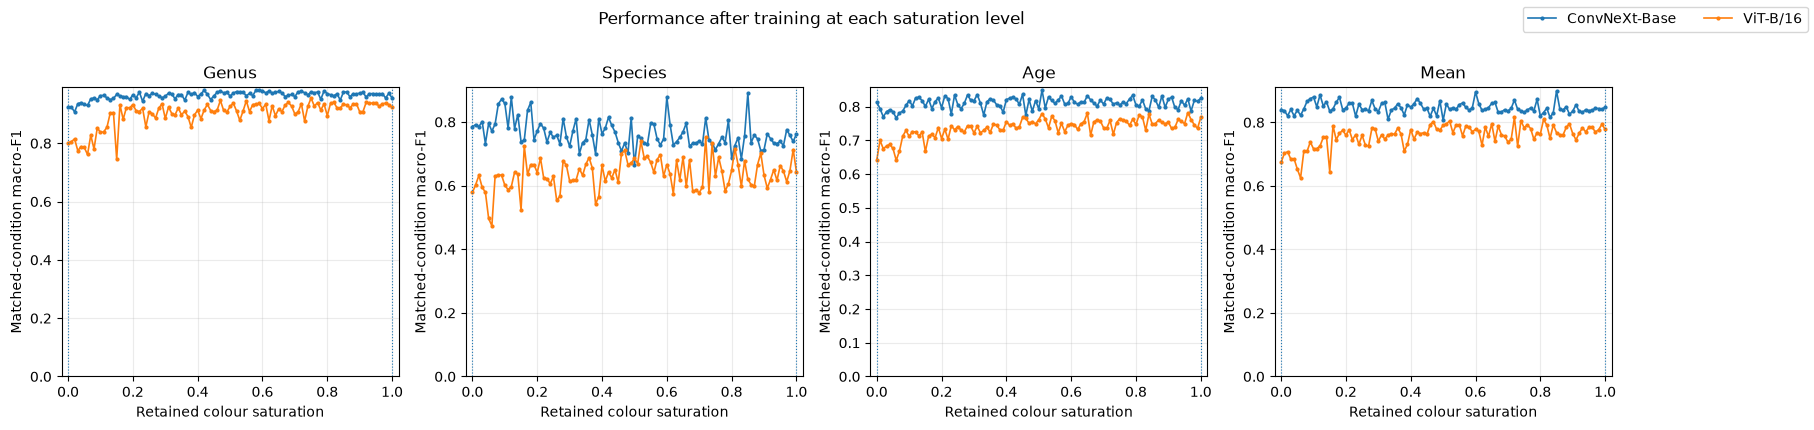

In [8]:
saturation_matched = saturation_subset(matched_long)

if saturation_matched.empty:
    print("No matched-condition saturation data were found.")
else:
    curve = aggregate_metric(
        saturation_matched,
        value_col="matched_test_macro_f1",
        group_cols=[
            "model_label",
            "task",
            "retained_saturation",
        ],
    )

    tasks = ordered_tasks(curve)
    fig, axes = plt.subplots(
        1,
        len(tasks),
        figsize=(5.0 * max(len(tasks), 1), 4.2),
        squeeze=False,
    )

    for ax, task in zip(axes[0], tasks):
        task_data = curve[curve["task"] == task]

        for model, model_data in task_data.groupby("model_label"):
            model_data = model_data.sort_values("retained_saturation")
            ax.plot(
                model_data["retained_saturation"],
                model_data["mean"],
                marker=".",
                markersize=4,
                linewidth=1.2,
                label=model,
            )

        ax.set_title(task.capitalize())
        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel("Matched-condition macro-F1")
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(bottom=0)
        add_zero_and_one_guides(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper right",
            ncol=max(1, len(labels)),
        )
        fig.subplots_adjust(top=0.80)

    fig.suptitle("Performance after training at each saturation level")
    save_figure(fig, "matched_saturation_curves.png")
    plt.show()


## 7. RGB stress test versus matched-condition training

The difference between these curves estimates the performance loss attributable to training–test mismatch at each saturation level.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/stress_test_vs_matched_saturation.png


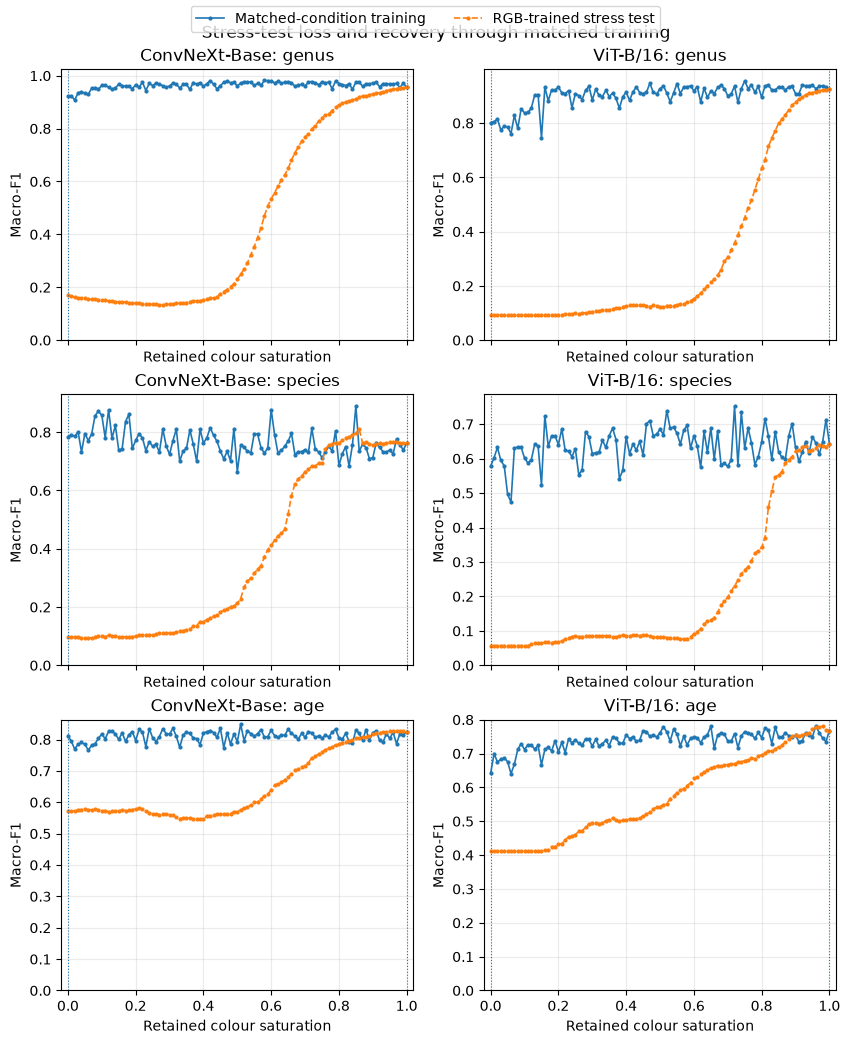

In [9]:
saturation_comparison = saturation_subset(comparison)

if saturation_comparison.empty:
    print(
        "No comparison data were found. "
        "Provide the RGB cue-suppression ratio table to build this analysis."
    )
else:
    long_form = saturation_comparison.melt(
        id_vars=[
            "model_label",
            "task",
            "retained_saturation",
        ],
        value_vars=[
            "rgb_model_test_macro_f1",
            "matched_test_macro_f1",
        ],
        var_name="regime",
        value_name="macro_f1",
    )

    long_form["regime"] = long_form["regime"].map({
        "rgb_model_test_macro_f1": "RGB-trained stress test",
        "matched_test_macro_f1": "Matched-condition training",
    })

    curve = aggregate_metric(
        long_form,
        value_col="macro_f1",
        group_cols=[
            "model_label",
            "task",
            "regime",
            "retained_saturation",
        ],
    )

    tasks = ordered_tasks(curve)
    models = sorted(curve["model_label"].dropna().unique())

    fig, axes = plt.subplots(
        len(tasks),
        len(models),
        figsize=(
            5.0 * max(len(models), 1),
            3.7 * max(len(tasks), 1),
        ),
        squeeze=False,
        sharex=True,
    )

    for row_index, task in enumerate(tasks):
        for column_index, model in enumerate(models):
            ax = axes[row_index][column_index]
            subset = curve[
                curve["task"].eq(task)
                & curve["model_label"].eq(model)
            ]

            for regime, regime_data in subset.groupby("regime"):
                regime_data = regime_data.sort_values("retained_saturation")
                linestyle = "--" if regime == "RGB-trained stress test" else "-"
                ax.plot(
                    regime_data["retained_saturation"],
                    regime_data["mean"],
                    marker=".",
                    markersize=4,
                    linewidth=1.2,
                    linestyle=linestyle,
                    label=regime,
                )

            ax.set_title(f"{model}: {task}")
            ax.set_xlabel("Retained colour saturation")
            ax.set_ylabel("Macro-F1")
            ax.set_xlim(-0.02, 1.02)
            ax.set_ylim(bottom=0)
            add_zero_and_one_guides(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2)
        fig.subplots_adjust(top=0.94)

    fig.suptitle("Stress-test loss and recovery through matched training")
    save_figure(fig, "stress_test_vs_matched_saturation.png")
    plt.show()


## 8. Adaptation gain across saturation

\[
\text{adaptation gain}
=
F1_{\text{matched training}}
-
F1_{\text{RGB-trained stress test}}.
\]

A positive value indicates that exposure to the altered colour distribution during training recovers performance.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/adaptation_gain_saturation.png


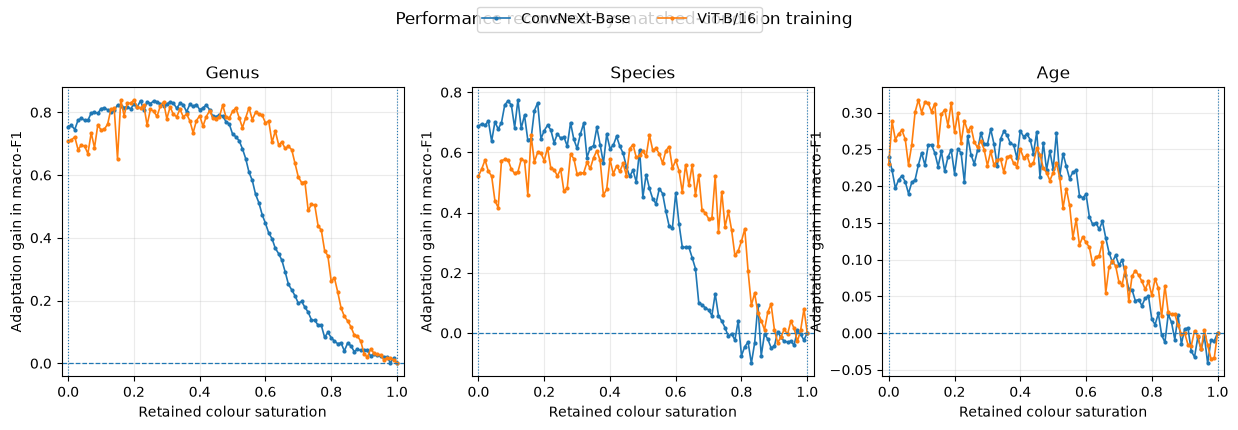

In [10]:
if saturation_comparison.empty:
    print("No saturation comparison data were found.")
else:
    gain_curve = aggregate_metric(
        saturation_comparison,
        value_col="adaptation_gain_macro_f1",
        group_cols=[
            "model_label",
            "task",
            "retained_saturation",
        ],
    )

    tasks = ordered_tasks(gain_curve)
    fig, axes = plt.subplots(
        1,
        len(tasks),
        figsize=(5.0 * max(len(tasks), 1), 4.2),
        squeeze=False,
    )

    for ax, task in zip(axes[0], tasks):
        task_data = gain_curve[gain_curve["task"] == task]

        for model, model_data in task_data.groupby("model_label"):
            model_data = model_data.sort_values("retained_saturation")
            ax.plot(
                model_data["retained_saturation"],
                model_data["mean"],
                marker=".",
                markersize=4,
                linewidth=1.2,
                label=model,
            )

        ax.axhline(0.0, linewidth=0.9, linestyle="--")
        ax.set_title(task.capitalize())
        ax.set_xlabel("Retained colour saturation")
        ax.set_ylabel("Adaptation gain in macro-F1")
        ax.set_xlim(-0.02, 1.02)
        add_zero_and_one_guides(ax)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=max(1, len(labels)),
        )
        fig.subplots_adjust(top=0.80)

    fig.suptitle("Performance recovered by matched-condition training")
    save_figure(fig, "adaptation_gain_saturation.png")
    plt.show()


## 9. Species-focused saturation figure

Species classification is treated as the primary taxonomic outcome. Genus and age remain important complementary tasks but should not be substituted for species-level discrimination.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/species_saturation_summary.png


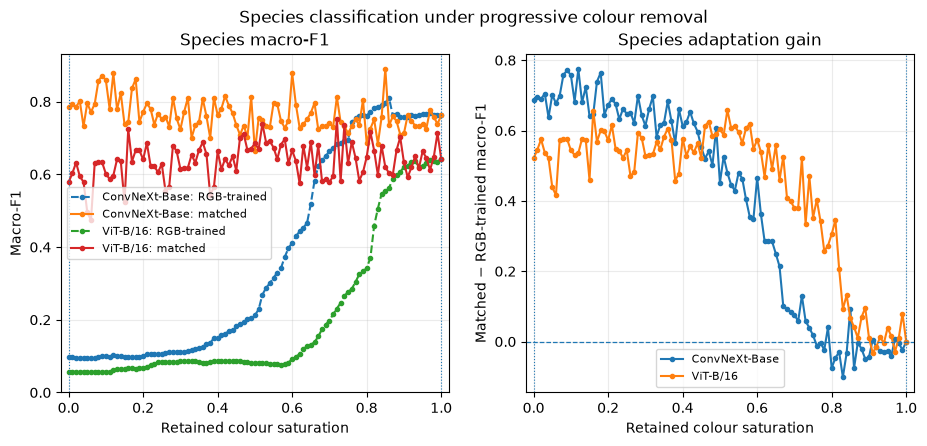

In [11]:
species = saturation_comparison[
    saturation_comparison["task"] == PRIMARY_TASK
].copy()

if species.empty:
    print(f"No comparison rows were found for task={PRIMARY_TASK!r}.")
else:
    models = sorted(species["model_label"].dropna().unique())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    performance_ax, gain_ax = axes

    for model in models:
        model_data = (
            species[species["model_label"] == model]
            .groupby("retained_saturation", as_index=False)
            .agg(
                rgb_stress=("rgb_model_test_macro_f1", "mean"),
                matched=("matched_test_macro_f1", "mean"),
                gain=("adaptation_gain_macro_f1", "mean"),
            )
            .sort_values("retained_saturation")
        )

        performance_ax.plot(
            model_data["retained_saturation"],
            model_data["rgb_stress"],
            marker=".",
            linestyle="--",
            label=f"{model}: RGB-trained",
        )
        performance_ax.plot(
            model_data["retained_saturation"],
            model_data["matched"],
            marker=".",
            linestyle="-",
            label=f"{model}: matched",
        )
        gain_ax.plot(
            model_data["retained_saturation"],
            model_data["gain"],
            marker=".",
            label=model,
        )

    performance_ax.set_title("Species macro-F1")
    performance_ax.set_xlabel("Retained colour saturation")
    performance_ax.set_ylabel("Macro-F1")
    performance_ax.set_xlim(-0.02, 1.02)
    performance_ax.set_ylim(bottom=0)
    add_zero_and_one_guides(performance_ax)
    performance_ax.legend(fontsize=8)

    gain_ax.axhline(0.0, linewidth=0.9, linestyle="--")
    gain_ax.set_title("Species adaptation gain")
    gain_ax.set_xlabel("Retained colour saturation")
    gain_ax.set_ylabel("Matched − RGB-trained macro-F1")
    gain_ax.set_xlim(-0.02, 1.02)
    add_zero_and_one_guides(gain_ax)
    gain_ax.legend(fontsize=8)

    fig.suptitle("Species classification under progressive colour removal")
    save_figure(fig, "species_saturation_summary.png")
    plt.show()


## 10. ConvNeXt–ViT difference across saturation

Positive values indicate better performance for the first model named on the y-axis label. This is a descriptive comparison unless repeated independent runs are available.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/architecture_difference_saturation.png


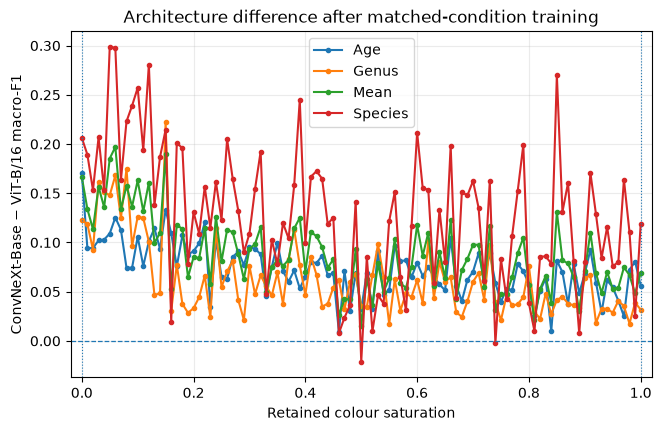

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/tables_cue_suppression/architecture_difference_saturation.csv


In [12]:
def pairwise_model_difference(
    frame: pd.DataFrame,
    value_col: str,
) -> tuple[pd.DataFrame, list[str]]:
    summary = (
        frame
        .dropna(
            subset=[
                "model_label",
                "task",
                "retained_saturation",
                value_col,
            ]
        )
        .groupby(
            ["model_label", "task", "retained_saturation"],
            as_index=False,
        )[value_col]
        .mean()
    )

    wide = summary.pivot(
        index=["task", "retained_saturation"],
        columns="model_label",
        values=value_col,
    )

    models = list(wide.columns)
    if len(models) != 2:
        return pd.DataFrame(), models

    out = wide.reset_index()
    out["difference"] = out[models[0]] - out[models[1]]
    return out, models


difference_table, compared_models = pairwise_model_difference(
    saturation_matched,
    "matched_test_macro_f1",
)

if difference_table.empty:
    print(
        "The model-difference plot requires exactly two architectures. "
        f"Found: {compared_models}"
    )
else:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    for task, task_data in difference_table.groupby("task"):
        task_data = task_data.sort_values("retained_saturation")
        ax.plot(
            task_data["retained_saturation"],
            task_data["difference"],
            marker=".",
            label=task.capitalize(),
        )

    ax.axhline(0.0, linewidth=0.9, linestyle="--")
    ax.set_xlabel("Retained colour saturation")
    ax.set_ylabel(
        f"{compared_models[0]} − {compared_models[1]} macro-F1"
    )
    ax.set_title("Architecture difference after matched-condition training")
    ax.set_xlim(-0.02, 1.02)
    add_zero_and_one_guides(ax)
    ax.legend()

    save_figure(fig, "architecture_difference_saturation.png")
    plt.show()

    save_table(
        difference_table,
        "architecture_difference_saturation.csv",
    )


## 11. Non-saturation perturbations

The remaining perturbations act on different visual cues and therefore require transformation-specific x-axes:

- channel shuffle: colour-channel identity;
- bilateral filter and Gaussian blur: texture and fine-scale detail;
- patch shuffle: global spatial arrangement and shape.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/matched_channel_shuffle.png


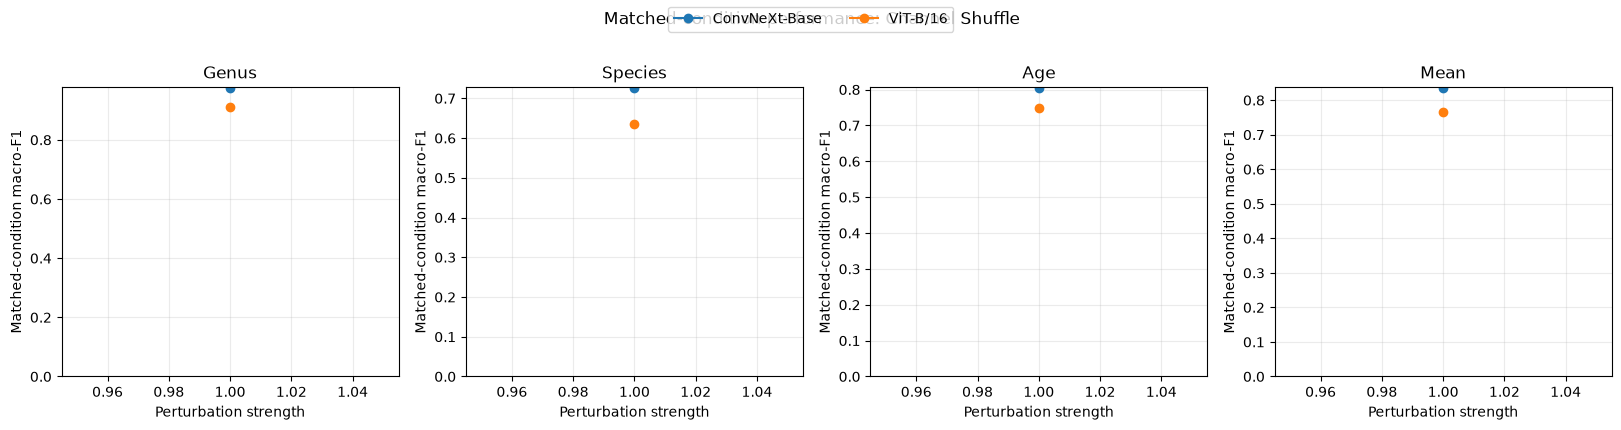

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/matched_bilateral_filter.png


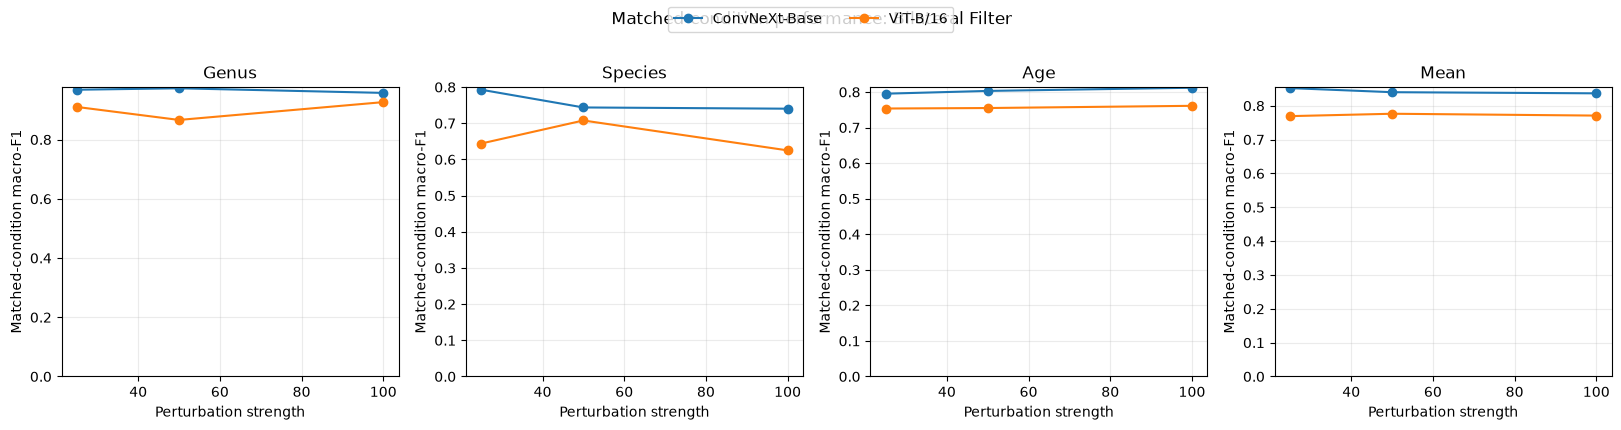

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/matched_gaussian_blur.png


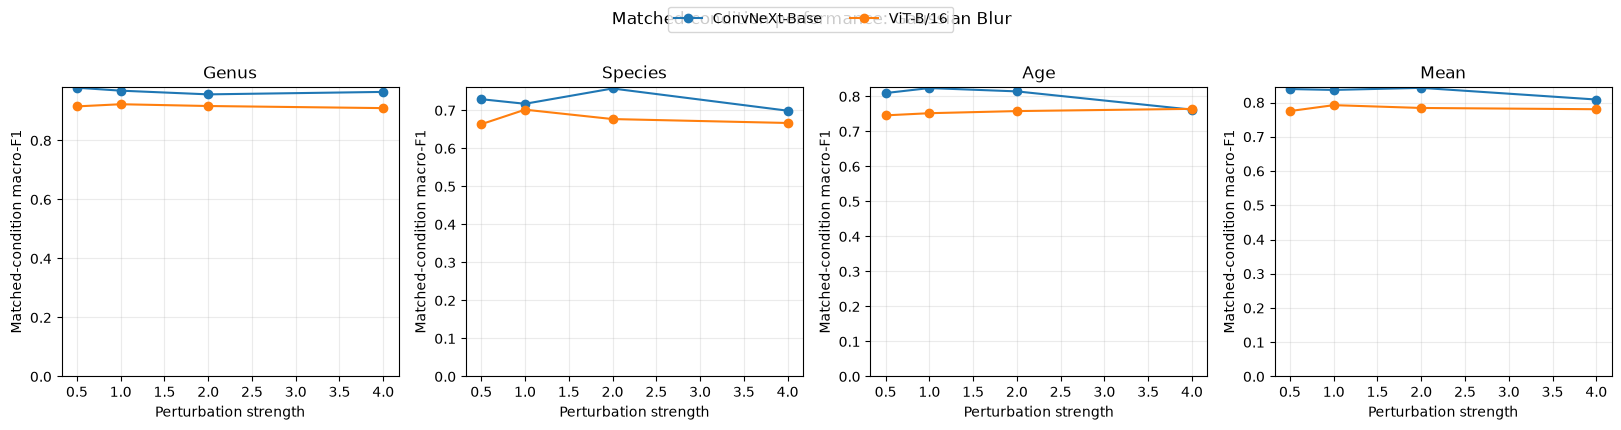

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/matched_patch_shuffle.png


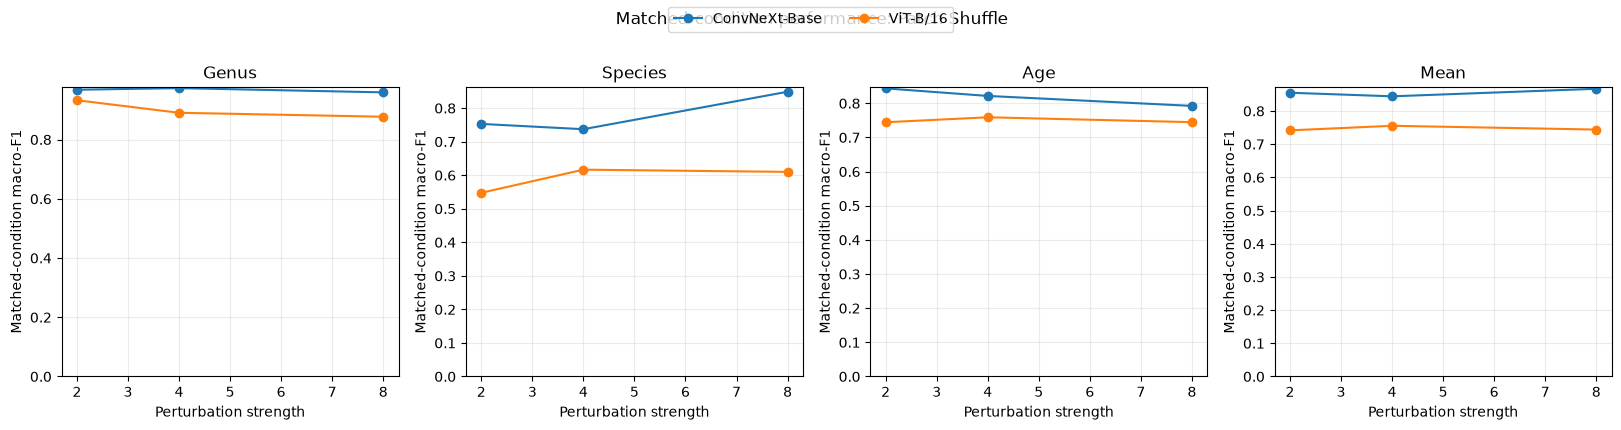

In [13]:
non_saturation = matched_long[
    matched_long["retained_saturation"].isna()
    & matched_long["condition"].ne("original")
].copy()

transform_order = [
    "channel_shuffle",
    "bilateral_filter",
    "gaussian_blur",
    "patch_shuffle",
]

for transform in transform_order:
    transform_data = non_saturation[
        non_saturation["transform_name"] == transform
    ].copy()

    if transform_data.empty:
        print(f"No matched-condition rows for {transform}.")
        continue

    curve = aggregate_metric(
        transform_data,
        value_col="matched_test_macro_f1",
        group_cols=[
            "model_label",
            "task",
            "perturbation_strength",
            "condition",
            "condition_label",
        ],
    )

    tasks = ordered_tasks(curve)
    fig, axes = plt.subplots(
        1,
        len(tasks),
        figsize=(5.0 * max(len(tasks), 1), 4.2),
        squeeze=False,
    )

    for ax, task in zip(axes[0], tasks):
        task_data = curve[curve["task"] == task]

        for model, model_data in task_data.groupby("model_label"):
            model_data = model_data.sort_values("perturbation_strength")
            ax.plot(
                model_data["perturbation_strength"],
                model_data["mean"],
                marker="o",
                label=model,
            )

        ax.set_title(task.capitalize())
        ax.set_xlabel("Perturbation strength")
        ax.set_ylabel("Matched-condition macro-F1")
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.25)

    handles, labels = axes[0][0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=max(1, len(labels)),
        )
        fig.subplots_adjust(top=0.80)

    title = transform.replace("_", " ").title()
    fig.suptitle(f"Matched-condition performance: {title}")
    save_figure(fig, f"matched_{transform}.png")
    plt.show()


## 12. Performance relative to the original matched-condition model

This normalisation compares each separately trained perturbed-condition model with the corresponding architecture and task trained on original RGB images.


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/non_saturation_relative_heatmap_ConvNeXt_Base.png


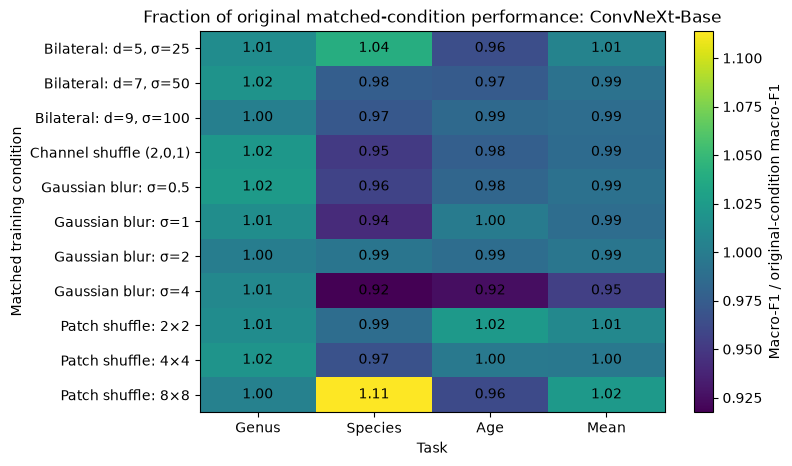

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/non_saturation_relative_heatmap_ViT_B_16.png


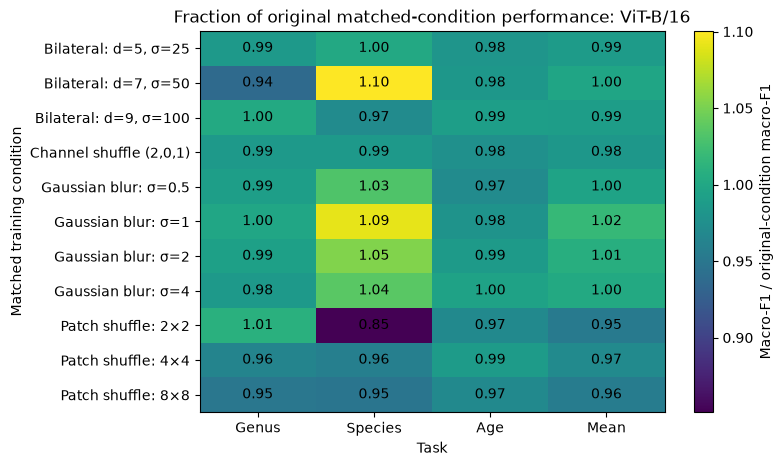

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/tables_cue_suppression/non_saturation_relative_performance.csv


In [14]:
if matched_long.empty:
    relative_matched = pd.DataFrame()
else:
    original_scores = (
        matched_long[matched_long["condition"] == "original"]
        .groupby(["model", "task"], as_index=False)
        .agg(
            original_matched_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            )
        )
    )

    relative_matched = matched_long.merge(
        original_scores,
        on=["model", "task"],
        how="left",
        validate="many_to_one",
    )

    relative_matched["ratio_to_original_matched"] = np.where(
        relative_matched["original_matched_macro_f1"].notna()
        & relative_matched["original_matched_macro_f1"].ne(0),
        relative_matched["matched_test_macro_f1"]
        / relative_matched["original_matched_macro_f1"],
        np.nan,
    )
    relative_matched["drop_from_original_matched"] = (
        1.0 - relative_matched["ratio_to_original_matched"]
    )

non_saturation_relative = relative_matched[
    relative_matched["retained_saturation"].isna()
    & relative_matched["condition"].ne("original")
].copy()

if non_saturation_relative.empty:
    print("No non-saturation rows were available.")
else:
    summary = (
        non_saturation_relative
        .groupby(
            [
                "model_label",
                "task",
                "feature_group",
                "transform_name",
                "condition",
                "condition_label",
                "perturbation_strength",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            matched_macro_f1=("matched_test_macro_f1", "mean"),
            ratio_to_original=("ratio_to_original_matched", "mean"),
            relative_drop=("drop_from_original_matched", "mean"),
        )
    )

    for model, model_data in summary.groupby("model_label"):
        pivot = model_data.pivot_table(
            index="condition_label",
            columns="task",
            values="ratio_to_original",
            aggfunc="mean",
        )

        task_columns = [
            task for task in TASK_ORDER if task in pivot.columns
        ]
        pivot = pivot.reindex(columns=task_columns)

        fig, ax = plt.subplots(
            figsize=(7.5, max(3.5, 0.45 * len(pivot)))
        )
        image = ax.imshow(pivot.to_numpy(), aspect="auto")

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([
            task.capitalize() for task in pivot.columns
        ])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("Task")
        ax.set_ylabel("Matched training condition")
        ax.set_title(
            f"Fraction of original matched-condition performance: {model}"
        )

        for row_index in range(pivot.shape[0]):
            for column_index in range(pivot.shape[1]):
                value = pivot.iloc[row_index, column_index]
                if pd.notna(value):
                    ax.text(
                        column_index,
                        row_index,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                    )

        fig.colorbar(
            image,
            ax=ax,
            label="Macro-F1 / original-condition macro-F1",
        )
        safe_model = re.sub(
            r"[^A-Za-z0-9]+",
            "_",
            model,
        ).strip("_")
        save_figure(
            fig,
            f"non_saturation_relative_heatmap_{safe_model}.png",
        )
        plt.show()

    save_table(
        summary,
        "non_saturation_relative_performance.csv",
    )


## 13. Saturation area-under-curve summaries

The normalised area under the curve summarises performance across the complete saturation range. Absolute and relative AUCs answer different questions:

- **absolute AUC:** average macro-F1 across saturation levels;
- **relative AUC:** average fraction of original-condition performance retained.


In [15]:
def normalised_trapezoidal_auc(
    group: pd.DataFrame,
    x_col: str,
    y_col: str,
) -> float:
    clean = (
        group[[x_col, y_col]]
        .dropna()
        .groupby(x_col, as_index=False)[y_col]
        .mean()
        .sort_values(x_col)
    )

    if len(clean) < 2:
        return float("nan")

    x = clean[x_col].to_numpy(dtype=float)
    y = clean[y_col].to_numpy(dtype=float)
    span = x.max() - x.min()

    if span <= 0:
        return float("nan")

    trapezoid = getattr(np, "trapezoid", np.trapz)
    return float(trapezoid(y, x) / span)


auc_rows = []

if not saturation_comparison.empty:
    for (model, task), group in saturation_comparison.groupby(
        ["model_label", "task"]
    ):
        auc_rows.append({
            "model": model,
            "task": task,
            "rgb_stress_absolute_auc": normalised_trapezoidal_auc(
                group,
                "retained_saturation",
                "rgb_model_test_macro_f1",
            ),
            "matched_absolute_auc": normalised_trapezoidal_auc(
                group,
                "retained_saturation",
                "matched_test_macro_f1",
            ),
            "rgb_relative_auc": normalised_trapezoidal_auc(
                group,
                "retained_saturation",
                "rgb_ratio_to_original",
            ),
            "matched_relative_auc": normalised_trapezoidal_auc(
                group,
                "retained_saturation",
                "matched_ratio_to_rgb_original",
            ),
            "adaptation_gain_auc": normalised_trapezoidal_auc(
                group,
                "retained_saturation",
                "adaptation_gain_macro_f1",
            ),
        })

auc_table = pd.DataFrame(auc_rows)
display(auc_table)
save_table(auc_table, "saturation_auc_summary.csv")


,model,task,rgb_stress_absolute_auc,matched_absolute_auc,rgb_relative_auc,matched_relative_auc,adaptation_gain_auc
0,ConvNeXt-Base,age,0.649,0.810,0.788,0.983,0.161
1,ConvNeXt-Base,genus,0.447,0.964,0.468,1.009,0.517
2,ConvNeXt-Base,species,0.372,0.763,0.488,1.001,0.391
3,ViT-B/16,age,0.571,0.737,0.744,0.960,0.166
4,ViT-B/16,genus,0.302,0.902,0.327,0.976,0.600
5,ViT-B/16,species,0.202,0.636,0.315,0.989,0.434


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/tables_cue_suppression/saturation_auc_summary.csv


## 14. Endpoint and manuscript-ready summary tables

In [16]:
def nearest_retention(
    frame: pd.DataFrame,
    target: float,
) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()

    out = frame.dropna(subset=["retained_saturation"]).copy()
    out["_distance"] = (
        out["retained_saturation"] - target
    ).abs()
    minimum = (
        out.groupby(["model_label", "task"])["_distance"]
        .transform("min")
    )
    return out[out["_distance"] == minimum].copy()


if saturation_comparison.empty:
    endpoint_table = pd.DataFrame()
    manuscript_table = pd.DataFrame()
else:
    original = nearest_retention(saturation_comparison, 1.0)
    greyscale = nearest_retention(saturation_comparison, 0.0)

    original_summary = (
        original
        .groupby(["model_label", "task"], as_index=False)
        .agg(
            original_rgb_macro_f1=("rgb_original_macro_f1", "mean"),
            original_matched_macro_f1=("matched_test_macro_f1", "mean"),
        )
    )

    greyscale_summary = (
        greyscale
        .groupby(["model_label", "task"], as_index=False)
        .agg(
            greyscale_rgb_stress_macro_f1=(
                "rgb_model_test_macro_f1",
                "mean",
            ),
            greyscale_matched_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            ),
            greyscale_adaptation_gain=(
                "adaptation_gain_macro_f1",
                "mean",
            ),
            greyscale_rgb_ratio_to_original=(
                "rgb_ratio_to_original",
                "mean",
            ),
            greyscale_matched_ratio_to_original=(
                "matched_ratio_to_rgb_original",
                "mean",
            ),
        )
    )

    endpoint_table = original_summary.merge(
        greyscale_summary,
        on=["model_label", "task"],
        how="outer",
    )
    endpoint_table["rgb_stress_test_drop"] = (
        endpoint_table["original_rgb_macro_f1"]
        - endpoint_table["greyscale_rgb_stress_macro_f1"]
    )
    endpoint_table["remaining_gap_after_matched_training"] = (
        endpoint_table["original_rgb_macro_f1"]
        - endpoint_table["greyscale_matched_macro_f1"]
    )

    manuscript_table = (
        saturation_comparison
        .groupby(
            ["model_label", "task", "retained_saturation"],
            as_index=False,
        )
        .agg(
            rgb_stress_macro_f1=(
                "rgb_model_test_macro_f1",
                "mean",
            ),
            matched_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            ),
            adaptation_gain=(
                "adaptation_gain_macro_f1",
                "mean",
            ),
            rgb_ratio_to_original=(
                "rgb_ratio_to_original",
                "mean",
            ),
            matched_ratio_to_original=(
                "matched_ratio_to_rgb_original",
                "mean",
            ),
        )
        .sort_values(
            ["task", "model_label", "retained_saturation"]
        )
    )

display(endpoint_table)
display(manuscript_table.head(20))

save_table(endpoint_table, "saturation_endpoint_summary.csv")
save_table(manuscript_table, "saturation_manuscript_table.csv")


,model_label,task,original_rgb_macro_f1,original_matched_macro_f1,greyscale_rgb_stress_macro_f1,greyscale_matched_macro_f1,greyscale_adaptation_gain,greyscale_rgb_ratio_to_original,greyscale_matched_ratio_to_original,rgb_stress_test_drop,remaining_gap_after_matched_training
0,ConvNeXt-Base,age,0.824,0.824,0.573,0.813,0.240,0.695,0.986,0.251,0.012
1,ConvNeXt-Base,genus,0.956,0.956,0.169,0.924,0.755,0.177,0.967,0.786,0.031
2,ConvNeXt-Base,species,0.762,0.762,0.097,0.785,0.688,0.127,1.030,0.665,-0.023
3,ViT-B/16,age,0.768,0.768,0.412,0.642,0.230,0.536,0.836,0.356,0.126
4,ViT-B/16,genus,0.924,0.924,0.093,0.801,0.708,0.101,0.867,0.831,0.123
5,ViT-B/16,species,0.643,0.643,0.057,0.578,0.521,0.089,0.899,0.586,0.065


,model_label,task,retained_saturation,rgb_stress_macro_f1,matched_macro_f1,adaptation_gain,rgb_ratio_to_original,matched_ratio_to_original
0,ConvNeXt-Base,age,0.000,0.573,0.813,0.240,0.695,0.986
1,ConvNeXt-Base,age,0.010,0.572,0.794,0.222,0.694,0.963
2,ConvNeXt-Base,age,0.020,0.572,0.770,0.197,0.694,0.934
3,ConvNeXt-Base,age,0.030,0.576,0.785,0.209,0.699,0.952
4,ConvNeXt-Base,age,0.040,0.577,0.791,0.214,0.700,0.959
5,ConvNeXt-Base,age,0.050,0.579,0.785,0.206,0.702,0.952
6,ConvNeXt-Base,age,0.060,0.576,0.766,0.190,0.699,0.929
7,ConvNeXt-Base,age,0.070,0.576,0.781,0.205,0.699,0.948
8,ConvNeXt-Base,age,0.080,0.578,0.787,0.208,0.701,0.954
9,ConvNeXt-Base,age,0.090,0.575,0.803,0.229,0.697,0.975


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/tables_cue_suppression/saturation_endpoint_summary.csv
Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/tables_cue_suppression/saturation_manuscript_table.csv


## 15. Descriptive uncertainty across repeated runs

Bootstrap intervals are meaningful only when each model–task–condition cell contains multiple independently trained runs. They are not a substitute for replication when only one run is available.


In [17]:
def bootstrap_mean_interval(
    values: pd.Series,
    n_bootstrap: int = 5000,
    confidence: float = 0.95,
    seed: int = 42,
) -> tuple[float, float, float, int]:
    clean = values.dropna().to_numpy(dtype=float)
    n = len(clean)

    if n == 0:
        return np.nan, np.nan, np.nan, 0
    if n == 1:
        return float(clean[0]), np.nan, np.nan, 1

    rng = np.random.default_rng(seed)
    draws = rng.choice(
        clean,
        size=(n_bootstrap, n),
        replace=True,
    )
    means = draws.mean(axis=1)

    alpha = 1.0 - confidence
    lower, upper = np.quantile(
        means,
        [alpha / 2.0, 1.0 - alpha / 2.0],
    )
    return float(clean.mean()), float(lower), float(upper), n


uncertainty_rows = []

if not comparison.empty:
    for keys, group in comparison.groupby(
        ["model_label", "task", "condition"],
        dropna=False,
    ):
        mean, lower, upper, n = bootstrap_mean_interval(
            group["adaptation_gain_macro_f1"]
        )
        uncertainty_rows.append({
            "model": keys[0],
            "task": keys[1],
            "condition": keys[2],
            "mean_adaptation_gain": mean,
            "ci_lower": lower,
            "ci_upper": upper,
            "n_independent_rows": n,
        })

uncertainty_table = pd.DataFrame(uncertainty_rows)
display(uncertainty_table.head(20))
save_table(
    uncertainty_table,
    "adaptation_gain_bootstrap_intervals.csv",
)


,model,task,condition,mean_adaptation_gain,ci_lower,ci_upper,n_independent_rows
0,ConvNeXt-Base,age,bilateral_d5_c25_s25,-0.024,NaN,NaN,1
1,ConvNeXt-Base,age,bilateral_d7_c50_s50,0.004,NaN,NaN,1
2,ConvNeXt-Base,age,bilateral_d9_c100_s100,0.061,NaN,NaN,1
3,ConvNeXt-Base,age,channel_shuffle_201,0.369,NaN,NaN,1
4,ConvNeXt-Base,age,gaussian_sigma_0.5,-0.008,NaN,NaN,1
5,ConvNeXt-Base,age,gaussian_sigma_1,0.023,NaN,NaN,1
6,ConvNeXt-Base,age,gaussian_sigma_2,0.092,NaN,NaN,1
7,ConvNeXt-Base,age,gaussian_sigma_4,0.066,NaN,NaN,1
8,ConvNeXt-Base,age,grayscale,0.240,NaN,NaN,1
9,ConvNeXt-Base,age,original,0.000,NaN,NaN,1


Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/tables_cue_suppression/adaptation_gain_bootstrap_intervals.csv


In [18]:
uncertainty_table.to_csv(
    TABLE_DIR / "adaptation_gain_bootstrap_intervals.csv",
    index=False,
)

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/bar_matched_colour_100_50_0.png


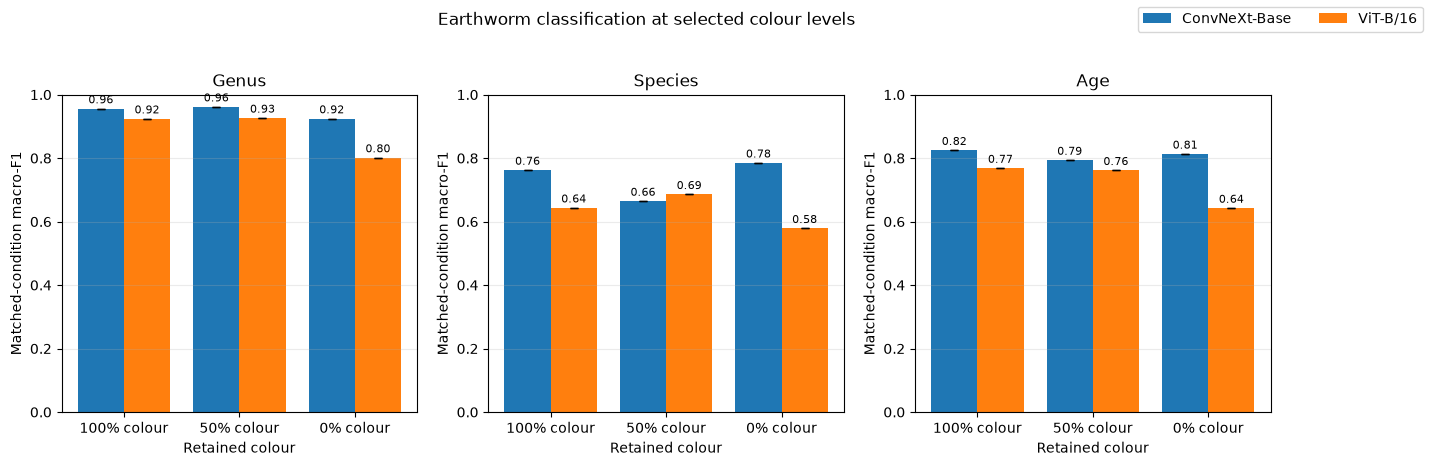

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/bar_rgb_stress_vs_matched_colour_100_50_0.png


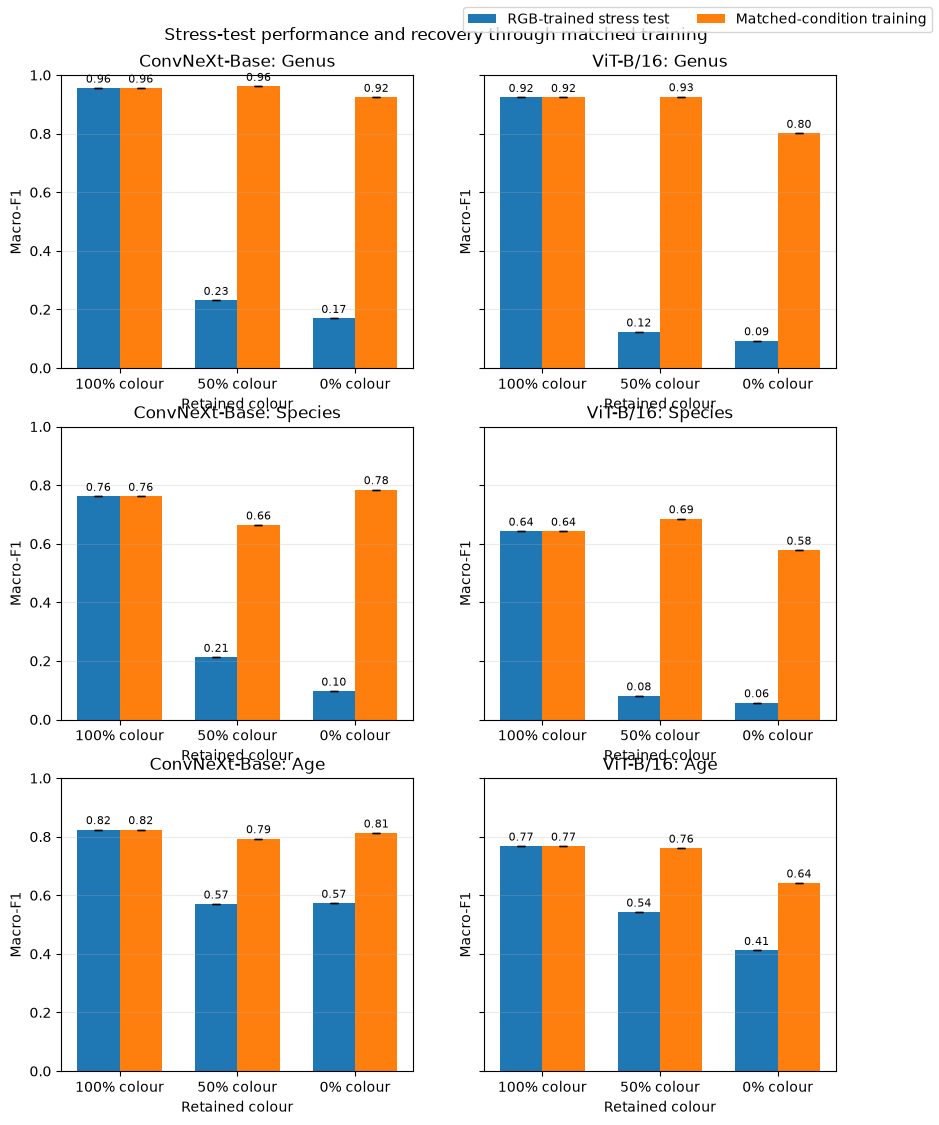

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/bar_adaptation_gain_colour_100_50_0.png


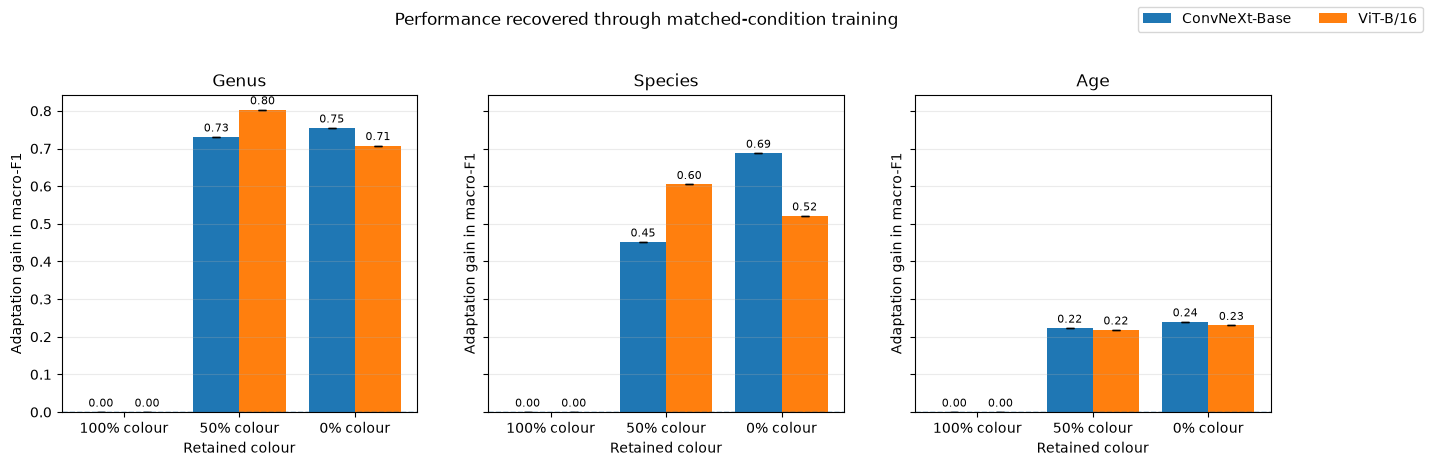

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/bar_combined_representative_conditions_relative.png


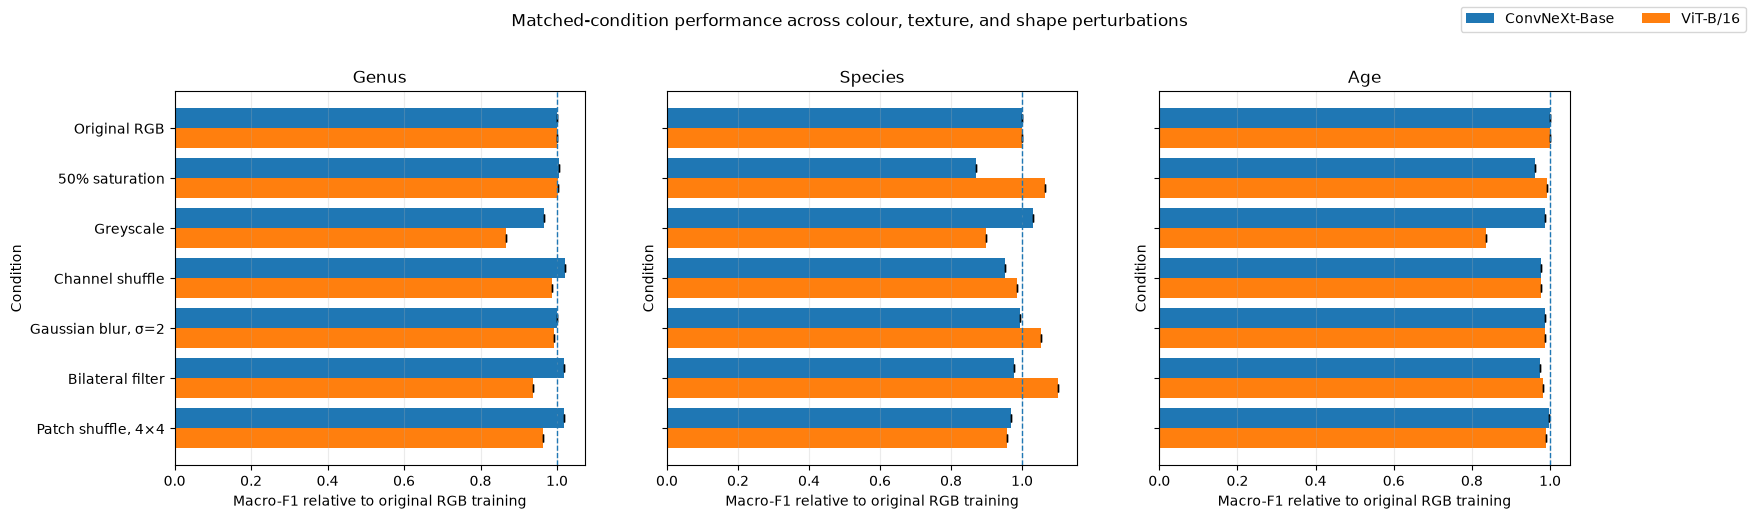

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/bar_species_combined_conditions_absolute.png


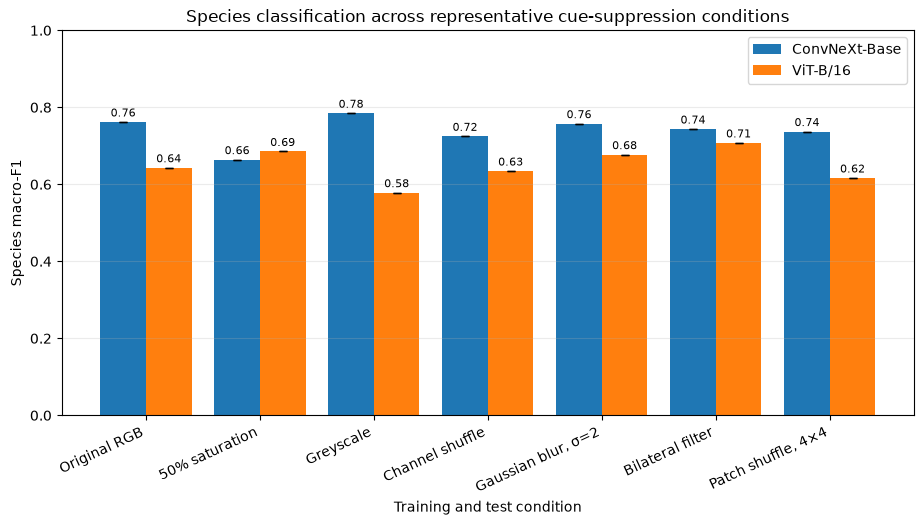

In [19]:
# ============================================================
# COMPACT BAR PLOTS
# 1. 100%, 50%, and 0% retained colour
# 2. RGB stress test versus matched-condition training
# 3. Combined colour, texture, and shape conditions
# ============================================================

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

TASKS_TO_PLOT = ["genus", "species", "age"]

COLOUR_LEVELS = {
    "100% colour": 1.0,
    "50% colour": 0.5,
    "0% colour": 0.0,
}

REPRESENTATIVE_CONDITIONS = {
    "Original RGB": "original",
    "50% saturation": "saturation_050pct",
    "Greyscale": "grayscale",
    "Channel shuffle": "channel_shuffle_201",
    "Gaussian blur, σ=2": "gaussian_sigma_2",
    "Bilateral filter": "bilateral_d7_c50_s50",
    "Patch shuffle, 4×4": "patch_shuffle_grid_4",
}

from matplotlib.container import BarContainer


def add_bar_labels(
    ax: plt.Axes,
    decimals: int = 2,
    fontsize: int = 8,
) -> None:
    """Add labels only to vertical bar containers."""

    for container in ax.containers:
        if not isinstance(container, BarContainer):
            continue

        labels = []

        for bar in container.patches:
            height = bar.get_height()

            if height is not None and np.isfinite(height):
                labels.append(f"{height:.{decimals}f}")
            else:
                labels.append("")

        ax.bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=fontsize,
        )
def summarise_with_se(
    frame: pd.DataFrame,
    group_columns: list[str],
    value_column: str,
) -> pd.DataFrame:
    """Calculate mean, SD, count, and standard error."""
    summary = (
        frame
        .dropna(subset=[*group_columns, value_column])
        .groupby(group_columns, as_index=False)[value_column]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    summary["se"] = summary["std"] / np.sqrt(summary["count"])
    summary["se"] = summary["se"].fillna(0.0)

    return summary


def safe_filename(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()


# ============================================================
# FIGURE 1
# Matched-condition performance at 100%, 50%, and 0% colour
# ============================================================

colour_rows = []

for colour_label, target_retention in COLOUR_LEVELS.items():
    subset = matched_long[
        matched_long["retained_saturation"].notna()
        & np.isclose(
            matched_long["retained_saturation"],
            target_retention,
            atol=1e-6,
        )
    ].copy()

    subset["colour_level"] = colour_label
    subset["colour_order"] = target_retention
    colour_rows.append(subset)

colour_selected = pd.concat(colour_rows, ignore_index=True)

colour_summary = summarise_with_se(
    colour_selected,
    group_columns=[
        "task",
        "colour_level",
        "colour_order",
        "model_label",
    ],
    value_column="matched_test_macro_f1",
)

models = sorted(colour_summary["model_label"].unique())
colour_order = list(COLOUR_LEVELS.keys())

fig, axes = plt.subplots(
    1,
    len(TASKS_TO_PLOT),
    figsize=(5.2 * len(TASKS_TO_PLOT), 4.6),
    squeeze=False,
    sharey=False,
)

for ax, task in zip(axes[0], TASKS_TO_PLOT):
    task_data = colour_summary[
        colour_summary["task"] == task
    ].copy()

    x = np.arange(len(colour_order))
    width = 0.8 / max(len(models), 1)

    for model_index, model in enumerate(models):
        model_data = (
            task_data[task_data["model_label"] == model]
            .set_index("colour_level")
            .reindex(colour_order)
        )

        offset = (
            model_index - (len(models) - 1) / 2
        ) * width

        ax.bar(
            x + offset,
            model_data["mean"],
            width=width,
            yerr=model_data["se"],
            capsize=3,
            label=model,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(colour_order)
    ax.set_title(task.capitalize())
    ax.set_xlabel("Retained colour")
    ax.set_ylabel("Matched-condition macro-F1")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)

    add_bar_labels(ax)

handles, labels = axes[0][0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper right",
        ncol=len(labels),
    )
    fig.subplots_adjust(top=0.80)

fig.suptitle(
    "Earthworm classification at selected colour levels"
)

if SAVE_FIGURES:
    save_figure(
        fig,
        "bar_matched_colour_100_50_0.png",
    )

plt.show()


# ============================================================
# FIGURE 2
# RGB-trained stress test versus matched-condition training
# at 100%, 50%, and 0% colour
# ============================================================

comparison_rows = []

for colour_label, target_retention in COLOUR_LEVELS.items():
    subset = comparison[
        comparison["retained_saturation"].notna()
        & np.isclose(
            comparison["retained_saturation"],
            target_retention,
            atol=1e-6,
        )
    ].copy()

    subset["colour_level"] = colour_label
    subset["colour_order"] = target_retention
    comparison_rows.append(subset)

colour_comparison = pd.concat(
    comparison_rows,
    ignore_index=True,
)

colour_comparison_long = colour_comparison.melt(
    id_vars=[
        "model_label",
        "task",
        "colour_level",
        "colour_order",
    ],
    value_vars=[
        "rgb_model_test_macro_f1",
        "matched_test_macro_f1",
    ],
    var_name="training_regime",
    value_name="macro_f1",
)

colour_comparison_long["training_regime"] = (
    colour_comparison_long["training_regime"].map({
        "rgb_model_test_macro_f1":
            "RGB-trained stress test",
        "matched_test_macro_f1":
            "Matched-condition training",
    })
)

regime_summary = summarise_with_se(
    colour_comparison_long,
    group_columns=[
        "model_label",
        "task",
        "colour_level",
        "training_regime",
    ],
    value_column="macro_f1",
)

regime_order = [
    "RGB-trained stress test",
    "Matched-condition training",
]

fig, axes = plt.subplots(
    len(TASKS_TO_PLOT),
    len(models),
    figsize=(
        5.0 * len(models),
        4.0 * len(TASKS_TO_PLOT),
    ),
    squeeze=False,
    sharey=True,
)

for row_index, task in enumerate(TASKS_TO_PLOT):
    for column_index, model in enumerate(models):
        ax = axes[row_index, column_index]

        panel = regime_summary[
            regime_summary["task"].eq(task)
            & regime_summary["model_label"].eq(model)
        ]

        x = np.arange(len(colour_order))
        width = 0.36

        for regime_index, regime in enumerate(regime_order):
            regime_data = (
                panel[
                    panel["training_regime"] == regime
                ]
                .set_index("colour_level")
                .reindex(colour_order)
            )

            offset = (
                regime_index - (len(regime_order) - 1) / 2
            ) * width

            ax.bar(
                x + offset,
                regime_data["mean"],
                width=width,
                yerr=regime_data["se"],
                capsize=3,
                label=regime,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(colour_order)
        ax.set_ylim(0, 1)
        ax.set_title(f"{model}: {task.capitalize()}")
        ax.set_xlabel("Retained colour")
        ax.set_ylabel("Macro-F1")
        ax.grid(axis="y", alpha=0.25)

        add_bar_labels(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper right",
        ncol=2,
    )
    fig.subplots_adjust(top=0.94)

fig.suptitle(
    "Stress-test performance and recovery through matched training"
)

if SAVE_FIGURES:
    save_figure(
        fig,
        "bar_rgb_stress_vs_matched_colour_100_50_0.png",
    )

plt.show()


# ============================================================
# FIGURE 3
# Adaptation gain at 100%, 50%, and 0% colour
# ============================================================

adaptation_summary = summarise_with_se(
    colour_comparison,
    group_columns=[
        "model_label",
        "task",
        "colour_level",
    ],
    value_column="adaptation_gain_macro_f1",
)

fig, axes = plt.subplots(
    1,
    len(TASKS_TO_PLOT),
    figsize=(5.2 * len(TASKS_TO_PLOT), 4.6),
    squeeze=False,
    sharey=True,
)

for ax, task in zip(axes[0], TASKS_TO_PLOT):
    task_data = adaptation_summary[
        adaptation_summary["task"] == task
    ]

    x = np.arange(len(colour_order))
    width = 0.8 / max(len(models), 1)

    for model_index, model in enumerate(models):
        model_data = (
            task_data[
                task_data["model_label"] == model
            ]
            .set_index("colour_level")
            .reindex(colour_order)
        )

        offset = (
            model_index - (len(models) - 1) / 2
        ) * width

        ax.bar(
            x + offset,
            model_data["mean"],
            width=width,
            yerr=model_data["se"],
            capsize=3,
            label=model,
        )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(colour_order)
    ax.set_title(task.capitalize())
    ax.set_xlabel("Retained colour")
    ax.set_ylabel("Adaptation gain in macro-F1")
    ax.grid(axis="y", alpha=0.25)

    add_bar_labels(ax)

handles, labels = axes[0][0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper right",
        ncol=len(labels),
    )
    fig.subplots_adjust(top=0.80)

fig.suptitle(
    "Performance recovered through matched-condition training"
)

if SAVE_FIGURES:
    save_figure(
        fig,
        "bar_adaptation_gain_colour_100_50_0.png",
    )

plt.show()


# ============================================================
# FIGURE 4
# Combined representative cue-suppression conditions
#
# Performance is divided by the corresponding original RGB
# matched-condition score so that colour, texture, and shape
# conditions can be compared on one scale.
# ============================================================

original_scores = (
    matched_long[
        matched_long["condition"] == "original"
    ]
    .groupby(
        ["model", "model_label", "task"],
        as_index=False,
    )
    .agg(
        original_macro_f1=(
            "matched_test_macro_f1",
            "mean",
        )
    )
)

combined = matched_long[
    matched_long["condition"].isin(
        REPRESENTATIVE_CONDITIONS.values()
    )
].copy()

condition_label_map = {
    condition: label
    for label, condition in REPRESENTATIVE_CONDITIONS.items()
}

combined["combined_condition"] = (
    combined["condition"].map(condition_label_map)
)

combined = combined.merge(
    original_scores,
    on=["model", "model_label", "task"],
    how="left",
    validate="many_to_one",
)

combined["relative_macro_f1"] = np.where(
    combined["original_macro_f1"].notna()
    & combined["original_macro_f1"].ne(0),
    combined["matched_test_macro_f1"]
    / combined["original_macro_f1"],
    np.nan,
)

combined_order = list(REPRESENTATIVE_CONDITIONS.keys())

combined_summary = summarise_with_se(
    combined,
    group_columns=[
        "task",
        "combined_condition",
        "model_label",
    ],
    value_column="relative_macro_f1",
)

fig, axes = plt.subplots(
    1,
    len(TASKS_TO_PLOT),
    figsize=(6.0 * len(TASKS_TO_PLOT), 5.2),
    squeeze=False,
    sharey=True,
)

for ax, task in zip(axes[0], TASKS_TO_PLOT):
    task_data = combined_summary[
        combined_summary["task"] == task
    ]

    y = np.arange(len(combined_order))
    height = 0.8 / max(len(models), 1)

    for model_index, model in enumerate(models):
        model_data = (
            task_data[
                task_data["model_label"] == model
            ]
            .set_index("combined_condition")
            .reindex(combined_order)
        )

        offset = (
            model_index - (len(models) - 1) / 2
        ) * height

        ax.barh(
            y + offset,
            model_data["mean"],
            height=height,
            xerr=model_data["se"],
            capsize=3,
            label=model,
        )

    ax.axvline(1.0, linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(combined_order)
    ax.invert_yaxis()
    ax.set_title(task.capitalize())
    ax.set_xlabel(
        "Macro-F1 relative to original RGB training"
    )
    ax.set_ylabel("Condition")
    ax.grid(axis="x", alpha=0.25)

handles, labels = axes[0][0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper right",
        ncol=len(labels),
    )
    fig.subplots_adjust(top=0.83)

fig.suptitle(
    "Matched-condition performance across colour, texture, and shape perturbations"
)

if SAVE_FIGURES:
    save_figure(
        fig,
        "bar_combined_representative_conditions_relative.png",
    )

plt.show()


# ============================================================
# FIGURE 5
# Absolute species macro-F1 across combined conditions
# ============================================================

species_combined = combined_summary[
    combined_summary["task"] == "species"
].copy()

species_absolute = summarise_with_se(
    combined[
        combined["task"] == "species"
    ],
    group_columns=[
        "combined_condition",
        "model_label",
    ],
    value_column="matched_test_macro_f1",
)

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(combined_order))
width = 0.8 / max(len(models), 1)

for model_index, model in enumerate(models):
    model_data = (
        species_absolute[
            species_absolute["model_label"] == model
        ]
        .set_index("combined_condition")
        .reindex(combined_order)
    )

    offset = (
        model_index - (len(models) - 1) / 2
    ) * width

    ax.bar(
        x + offset,
        model_data["mean"],
        width=width,
        yerr=model_data["se"],
        capsize=3,
        label=model,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    combined_order,
    rotation=25,
    ha="right",
)
ax.set_ylim(0, 1)
ax.set_xlabel("Training and test condition")
ax.set_ylabel("Species macro-F1")
ax.set_title(
    "Species classification across representative cue-suppression conditions"
)
ax.grid(axis="y", alpha=0.25)
ax.legend()

add_bar_labels(ax)

if SAVE_FIGURES:
    save_figure(
        fig,
        "bar_species_combined_conditions_absolute.png",
    )

plt.show()

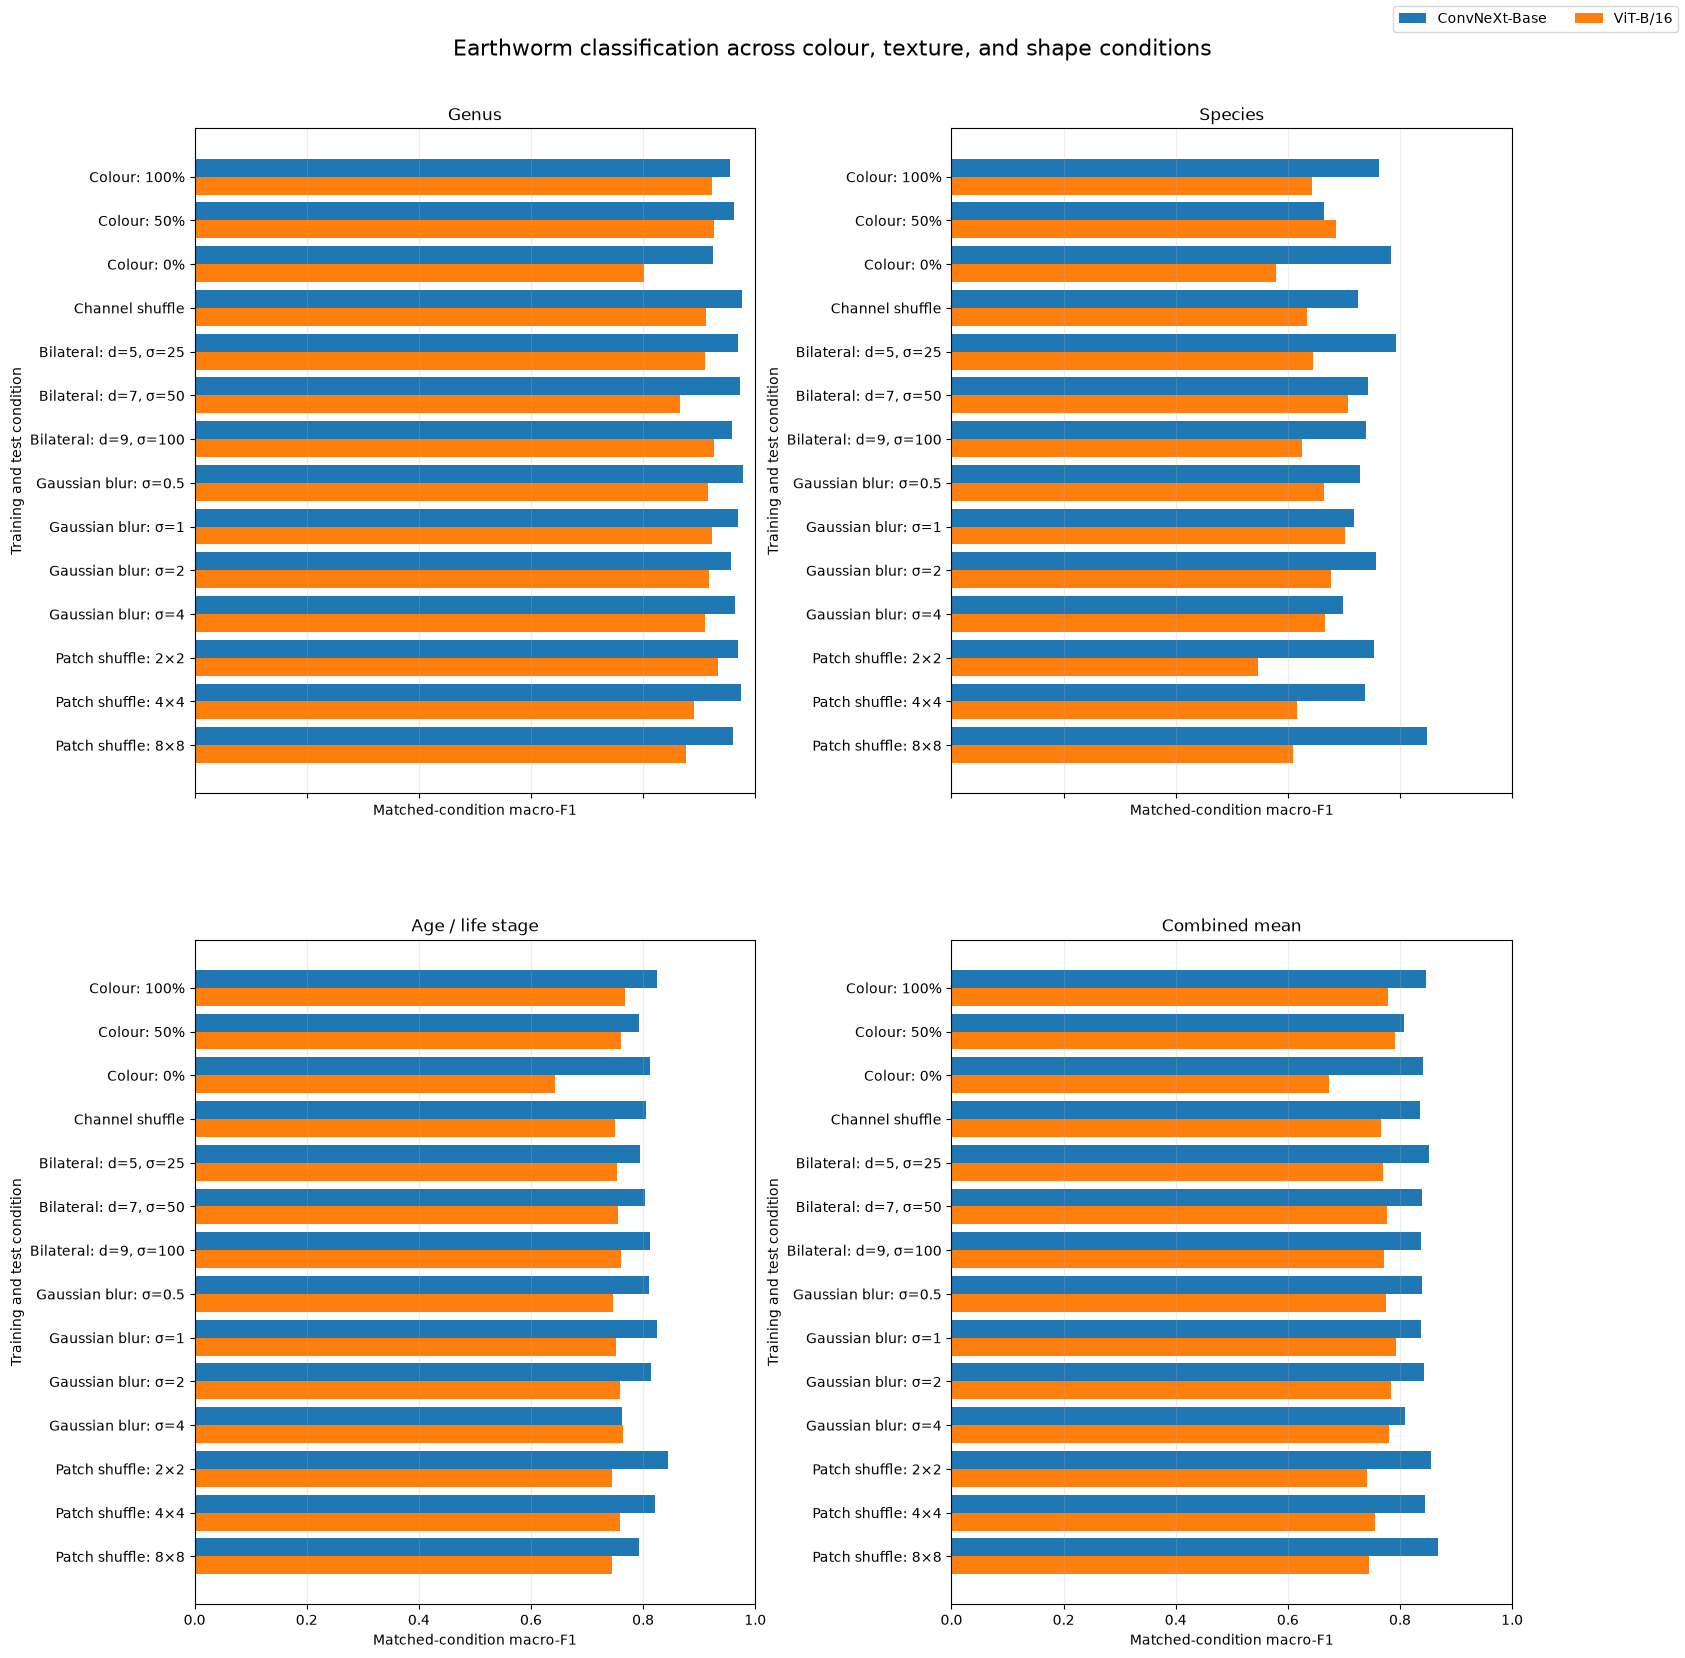

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/bar_all_conditions_all_tasks_both_models_matched.png


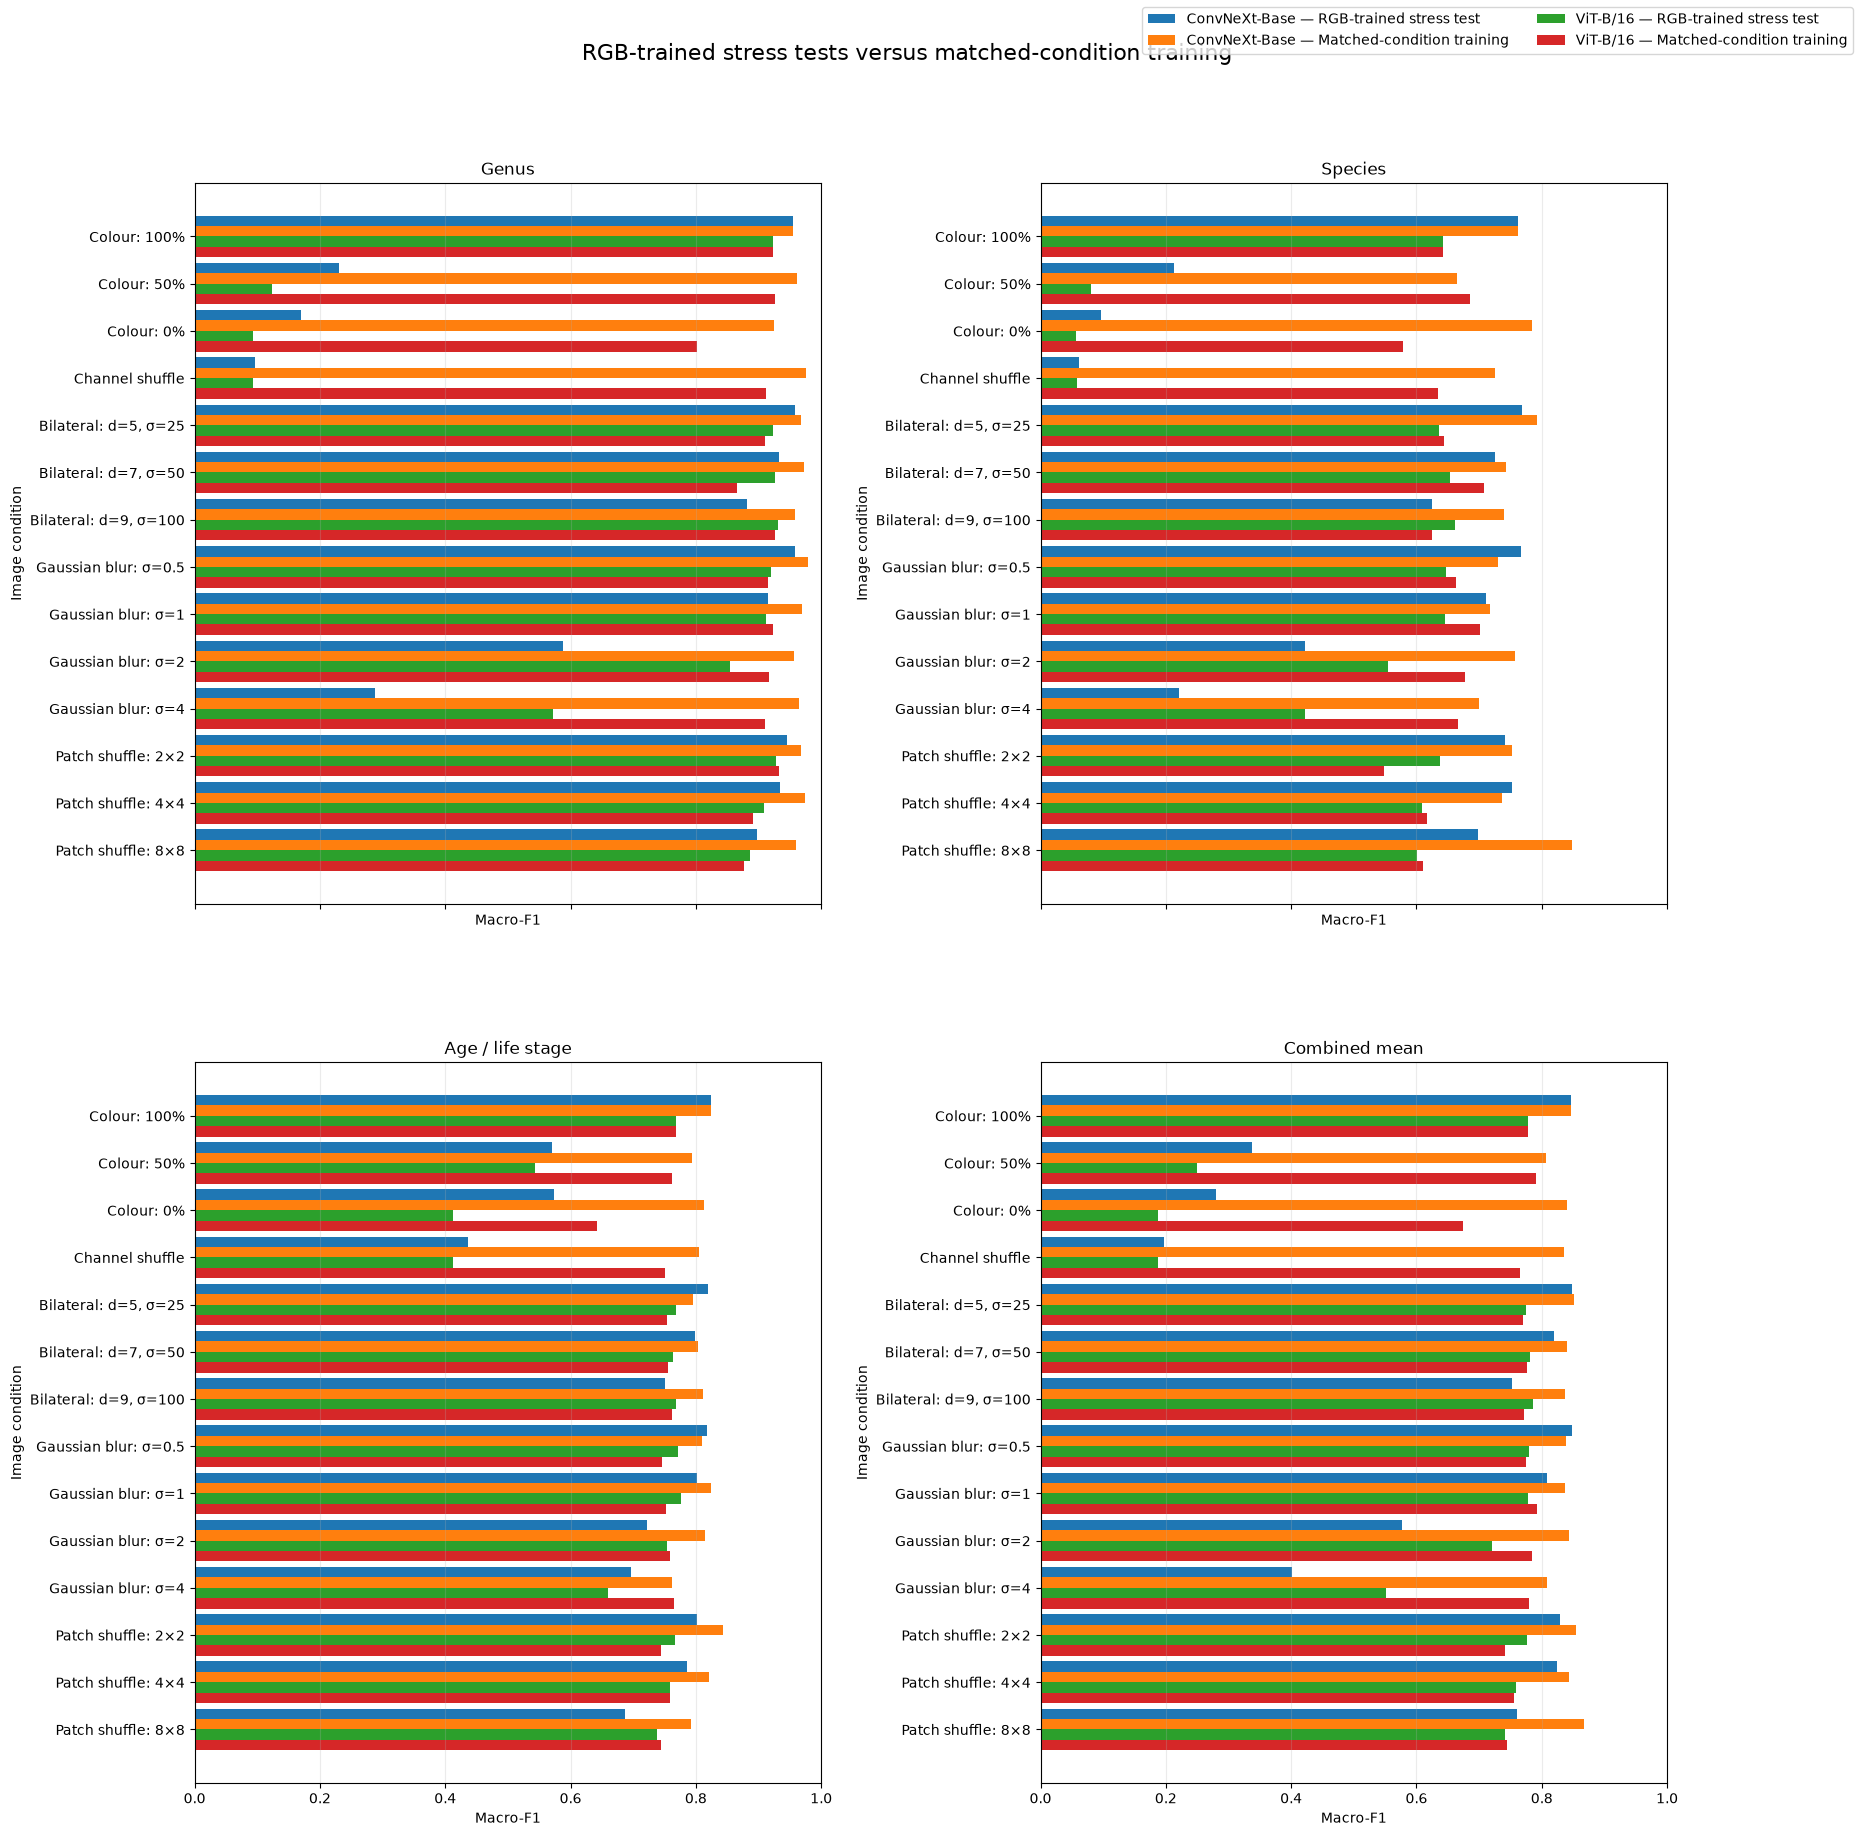

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/bar_all_conditions_all_tasks_both_models_trained_vs_test.png


In [20]:
# ============================================================
# ALL CONDITIONS, BUT ONLY THREE COLOUR LEVELS
#
# Figure 1:
#   Matched-condition macro-F1
#   - genus, species, age, and combined mean
#   - both models
#
# Figure 2:
#   RGB-trained stress test versus matched-condition training
#   - genus, species, age, and combined mean
#   - both models
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Output configuration
# ------------------------------------------------------------

OUTPUT_DIR = globals().get(
    "FIGURE_DIR",
    Path.cwd() / "figures_cue_suppression",
)
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DPI = globals().get("FIGURE_DPI", 300)


# ------------------------------------------------------------
# Conditions to retain
#
# All non-colour conditions are retained.
# For saturation, only 100%, 50%, and 0% are retained.
# ------------------------------------------------------------

CONDITION_ORDER = [
    "Colour: 100%",
    "Colour: 50%",
    "Colour: 0%",
    "Channel shuffle",
    "Bilateral: d=5, σ=25",
    "Bilateral: d=7, σ=50",
    "Bilateral: d=9, σ=100",
    "Gaussian blur: σ=0.5",
    "Gaussian blur: σ=1",
    "Gaussian blur: σ=2",
    "Gaussian blur: σ=4",
    "Patch shuffle: 2×2",
    "Patch shuffle: 4×4",
    "Patch shuffle: 8×8",
]

TASK_ORDER = [
    "genus",
    "species",
    "age",
    "mean",
]

TASK_TITLES = {
    "genus": "Genus",
    "species": "Species",
    "age": "Age / life stage",
    "mean": "Combined mean",
}


def canonical_condition(condition: object) -> str | None:
    """
    Convert raw condition names into the selected display conditions.

    Intermediate saturation levels are excluded.
    """

    if pd.isna(condition):
        return None

    condition = str(condition).strip().lower()

    mapping = {
        # Colour endpoints
        "original": "Colour: 100%",
        "saturation_100pct": "Colour: 100%",
        "saturation_050pct": "Colour: 50%",
        "grayscale": "Colour: 0%",
        "greyscale": "Colour: 0%",
        "saturation_000pct": "Colour: 0%",

        # Channel identity
        "channel_shuffle_201": "Channel shuffle",

        # Bilateral filters
        "bilateral_d5_c25_s25": "Bilateral: d=5, σ=25",
        "bilateral_d7_c50_s50": "Bilateral: d=7, σ=50",
        "bilateral_d9_c100_s100": "Bilateral: d=9, σ=100",

        # Gaussian blur
        "gaussian_sigma_0.5": "Gaussian blur: σ=0.5",
        "gaussian_sigma_1": "Gaussian blur: σ=1",
        "gaussian_sigma_2": "Gaussian blur: σ=2",
        "gaussian_sigma_4": "Gaussian blur: σ=4",

        # Spatial disruption
        "patch_shuffle_grid_2": "Patch shuffle: 2×2",
        "patch_shuffle_grid_4": "Patch shuffle: 4×4",
        "patch_shuffle_grid_8": "Patch shuffle: 8×8",
    }

    return mapping.get(condition)


def get_condition_column(frame: pd.DataFrame) -> str:
    """Find the condition column in a standardised or raw table."""

    for column in [
        "condition",
        "train_condition",
        "test_condition",
    ]:
        if column in frame.columns:
            return column

    raise KeyError(
        "Could not find a condition column. Expected one of: "
        "'condition', 'train_condition', or 'test_condition'."
    )


def ensure_model_label(frame: pd.DataFrame) -> pd.DataFrame:
    """Create readable model labels if they are absent."""

    out = frame.copy()

    if "model_label" in out.columns:
        return out

    model_names = {
        "convnext_base": "ConvNeXt-Base",
        "vit_b_16": "ViT-B/16",
    }

    out["model_label"] = (
        out["model"]
        .astype(str)
        .map(model_names)
        .fillna(out["model"].astype(str))
    )

    return out


def append_combined_mean_matched(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add a mean task calculated across genus, species, and age
    when a mean row is not already available.
    """

    out = frame.copy()

    if "mean" in out["task"].astype(str).str.lower().unique():
        return out

    condition_column = get_condition_column(out)

    group_columns = [
        column
        for column in [
            "model",
            "model_label",
            condition_column,
            "run_name",
        ]
        if column in out.columns
    ]

    component_tasks = out[
        out["task"].astype(str).str.lower().isin(
            ["genus", "species", "age"]
        )
    ].copy()

    mean_rows = (
        component_tasks
        .groupby(
            group_columns,
            as_index=False,
            dropna=False,
        )
        .agg(
            matched_test_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            )
        )
    )

    mean_rows["task"] = "mean"

    return pd.concat(
        [out, mean_rows],
        ignore_index=True,
        sort=False,
    )


def append_combined_mean_comparison(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add a mean task across genus, species, and age for all
    comparison metrics when no mean row is present.
    """

    out = frame.copy()

    if "mean" in out["task"].astype(str).str.lower().unique():
        return out

    condition_column = get_condition_column(out)

    value_columns = [
        column
        for column in [
            "rgb_model_test_macro_f1",
            "matched_test_macro_f1",
            "adaptation_gain_macro_f1",
            "rgb_original_macro_f1",
            "rgb_ratio_to_original",
            "matched_ratio_to_rgb_original",
        ]
        if column in out.columns
    ]

    group_columns = [
        column
        for column in [
            "model",
            "model_label",
            condition_column,
        ]
        if column in out.columns
    ]

    component_tasks = out[
        out["task"].astype(str).str.lower().isin(
            ["genus", "species", "age"]
        )
    ].copy()

    aggregation = {
        column: "mean"
        for column in value_columns
    }

    mean_rows = (
        component_tasks
        .groupby(
            group_columns,
            as_index=False,
            dropna=False,
        )
        .agg(aggregation)
    )

    mean_rows["task"] = "mean"

    return pd.concat(
        [out, mean_rows],
        ignore_index=True,
        sort=False,
    )


def prepare_matched_bar_data(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """Prepare matched-condition data for plotting."""

    out = ensure_model_label(frame)
    out = append_combined_mean_matched(out)

    condition_column = get_condition_column(out)

    out["condition_display"] = (
        out[condition_column].map(canonical_condition)
    )

    out["task"] = out["task"].astype(str).str.lower()

    out = out[
        out["condition_display"].notna()
        & out["task"].isin(TASK_ORDER)
    ].copy()

    # Grouping also removes duplicate original/endpoint aliases.
    summary = (
        out
        .groupby(
            [
                "task",
                "condition_display",
                "model_label",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            macro_f1=(
                "matched_test_macro_f1",
                "mean",
            ),
            n_rows=(
                "matched_test_macro_f1",
                "count",
            ),
        )
    )

    return summary


def prepare_comparison_bar_data(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prepare RGB stress-test versus matched-training data.
    """

    out = ensure_model_label(frame)
    out = append_combined_mean_comparison(out)

    condition_column = get_condition_column(out)

    out["condition_display"] = (
        out[condition_column].map(canonical_condition)
    )

    out["task"] = out["task"].astype(str).str.lower()

    out = out[
        out["condition_display"].notna()
        & out["task"].isin(TASK_ORDER)
    ].copy()

    long = out.melt(
        id_vars=[
            "task",
            "condition_display",
            "model_label",
        ],
        value_vars=[
            "rgb_model_test_macro_f1",
            "matched_test_macro_f1",
        ],
        var_name="evaluation_regime",
        value_name="macro_f1",
    )

    long["evaluation_regime"] = (
        long["evaluation_regime"].map({
            "rgb_model_test_macro_f1":
                "RGB-trained stress test",
            "matched_test_macro_f1":
                "Matched-condition training",
        })
    )

    # Grouping removes duplicated aliases such as original and
    # saturation_100pct when both are present.
    summary = (
        long
        .groupby(
            [
                "task",
                "condition_display",
                "model_label",
                "evaluation_regime",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            macro_f1=("macro_f1", "mean"),
            n_rows=("macro_f1", "count"),
        )
    )

    return summary


# ============================================================
# FIGURE 1
# All selected conditions, four tasks, and both architectures
# Matched-condition results only
# ============================================================

matched_bar_data = prepare_matched_bar_data(matched_long)

models = sorted(
    matched_bar_data["model_label"]
    .dropna()
    .unique()
)

available_conditions = [
    condition
    for condition in CONDITION_ORDER
    if condition in matched_bar_data["condition_display"].unique()
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 18),
    sharex=True,
    squeeze=False,
)

axes = axes.flatten()

for ax, task in zip(axes, TASK_ORDER):
    task_data = matched_bar_data[
        matched_bar_data["task"] == task
    ]

    y = np.arange(len(available_conditions))
    total_height = 0.82
    bar_height = total_height / max(len(models), 1)

    for model_index, model in enumerate(models):
        model_data = (
            task_data[
                task_data["model_label"] == model
            ]
            .set_index("condition_display")
            .reindex(available_conditions)
        )

        offset = (
            model_index - (len(models) - 1) / 2
        ) * bar_height

        values = model_data["macro_f1"].to_numpy(
            dtype=float
        )

        ax.barh(
            y + offset,
            values,
            height=bar_height,
            label=model,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(available_conditions)
    ax.invert_yaxis()

    ax.set_xlim(0, 1)
    ax.set_xlabel("Matched-condition macro-F1")
    ax.set_ylabel("Training and test condition")
    ax.set_title(TASK_TITLES[task])
    ax.grid(axis="x", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=max(len(labels), 1),
)

fig.suptitle(
    "Earthworm classification across colour, texture, and shape conditions",
    fontsize=16,
)

fig.subplots_adjust(
    top=0.93,
    hspace=0.22,
    wspace=0.35,
)

matched_output = (
    OUTPUT_DIR
    / "bar_all_conditions_all_tasks_both_models_matched.png"
)

fig.savefig(
    matched_output,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)

plt.show()

print("Saved:", matched_output)


# ============================================================
# FIGURE 2
# All selected conditions, four tasks, and both architectures
# RGB stress test versus matched-condition training
# ============================================================

comparison_bar_data = prepare_comparison_bar_data(
    comparison
)

available_conditions_comparison = [
    condition
    for condition in CONDITION_ORDER
    if condition in comparison_bar_data[
        "condition_display"
    ].unique()
]

regime_order = [
    "RGB-trained stress test",
    "Matched-condition training",
]

series_order = [
    (model, regime)
    for model in models
    for regime in regime_order
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(19, 20),
    sharex=True,
    squeeze=False,
)

axes = axes.flatten()

for ax, task in zip(axes, TASK_ORDER):
    task_data = comparison_bar_data[
        comparison_bar_data["task"] == task
    ]

    y = np.arange(
        len(available_conditions_comparison)
    )

    total_height = 0.88
    bar_height = total_height / max(
        len(series_order),
        1,
    )

    for series_index, (model, regime) in enumerate(
        series_order
    ):
        series_data = (
            task_data[
                task_data["model_label"].eq(model)
                & task_data[
                    "evaluation_regime"
                ].eq(regime)
            ]
            .set_index("condition_display")
            .reindex(
                available_conditions_comparison
            )
        )

        offset = (
            series_index
            - (len(series_order) - 1) / 2
        ) * bar_height

        values = series_data["macro_f1"].to_numpy(
            dtype=float
        )

        ax.barh(
            y + offset,
            values,
            height=bar_height,
            label=f"{model} — {regime}",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(
        available_conditions_comparison
    )
    ax.invert_yaxis()

    ax.set_xlim(0, 1)
    ax.set_xlabel("Macro-F1")
    ax.set_ylabel("Image condition")
    ax.set_title(TASK_TITLES[task])
    ax.grid(axis="x", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=2,
)

fig.suptitle(
    "RGB-trained stress tests versus matched-condition training",
    fontsize=16,
)

fig.subplots_adjust(
    top=0.91,
    hspace=0.22,
    wspace=0.35,
)

comparison_output = (
    OUTPUT_DIR
    / "bar_all_conditions_all_tasks_both_models_trained_vs_test.png"
)

fig.savefig(
    comparison_output,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)

plt.show()

print("Saved:", comparison_output)

OpenCV is unavailable; using Gaussian blur for the bilateral-filter preview.


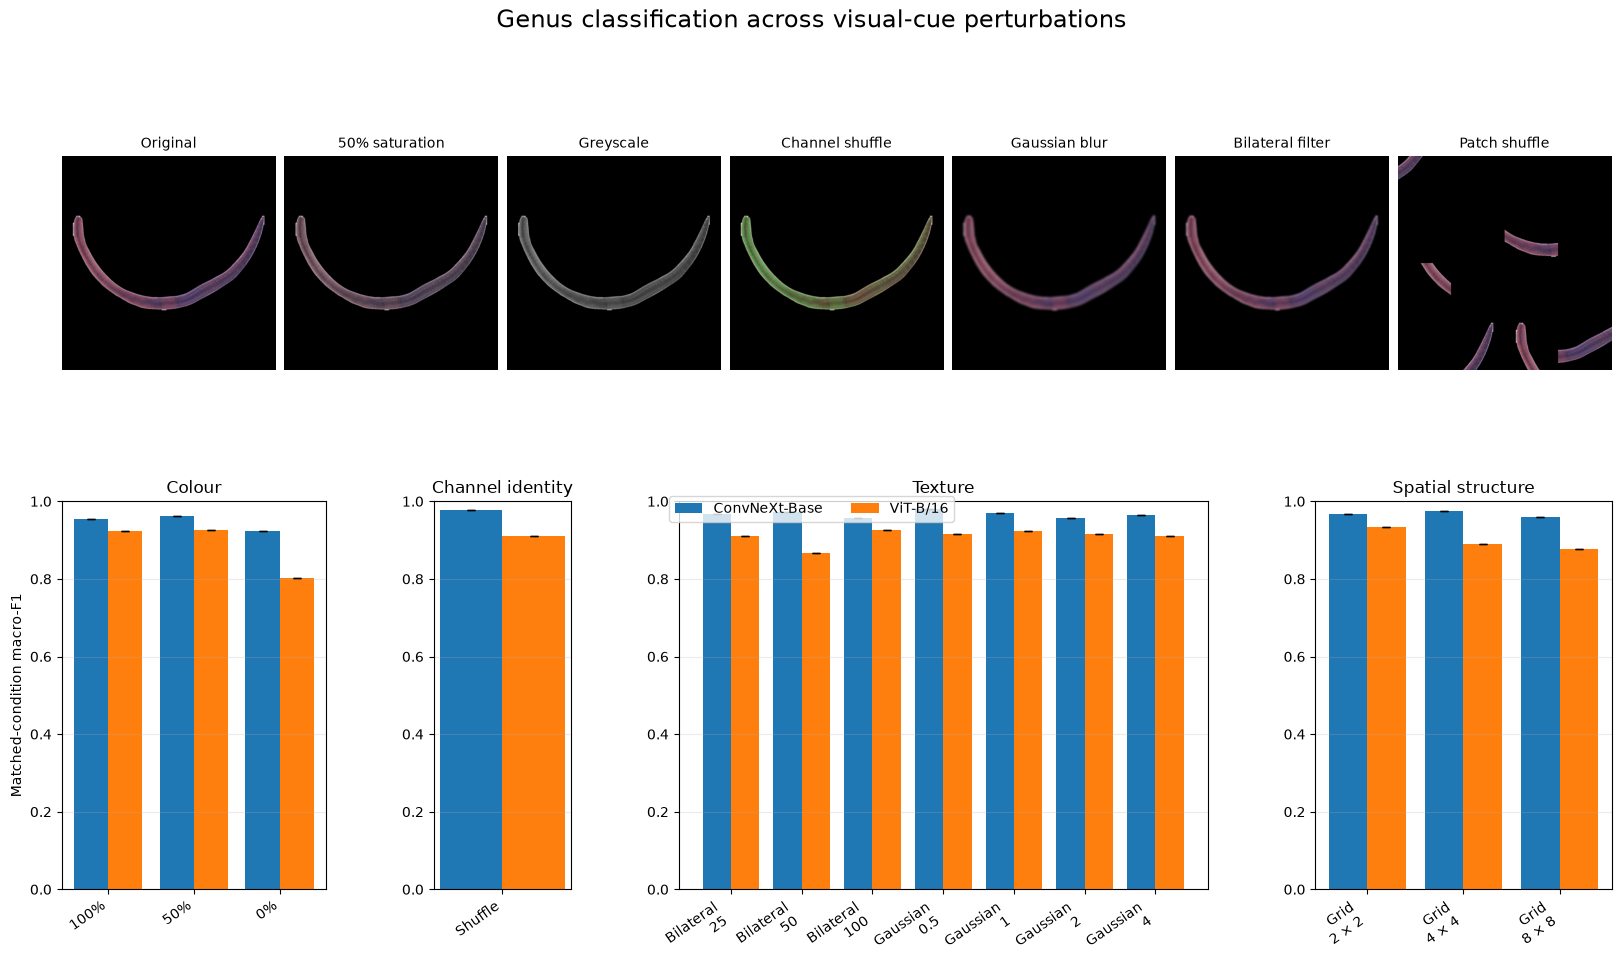

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_genus_matched_with_examples.png


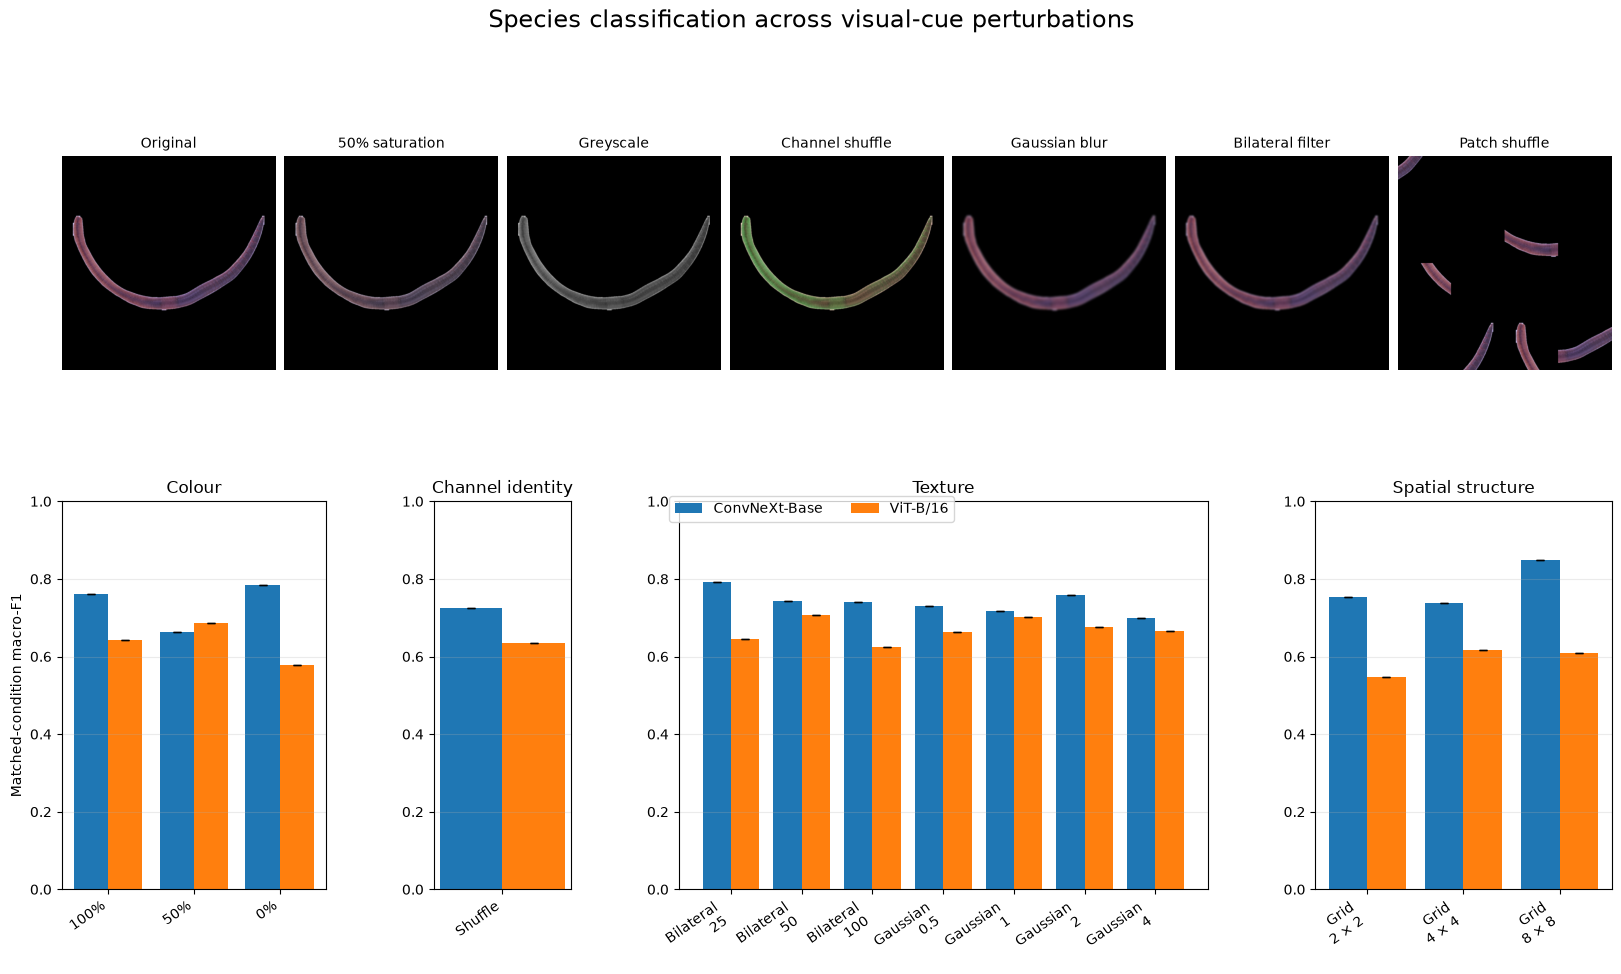

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_species_matched_with_examples.png


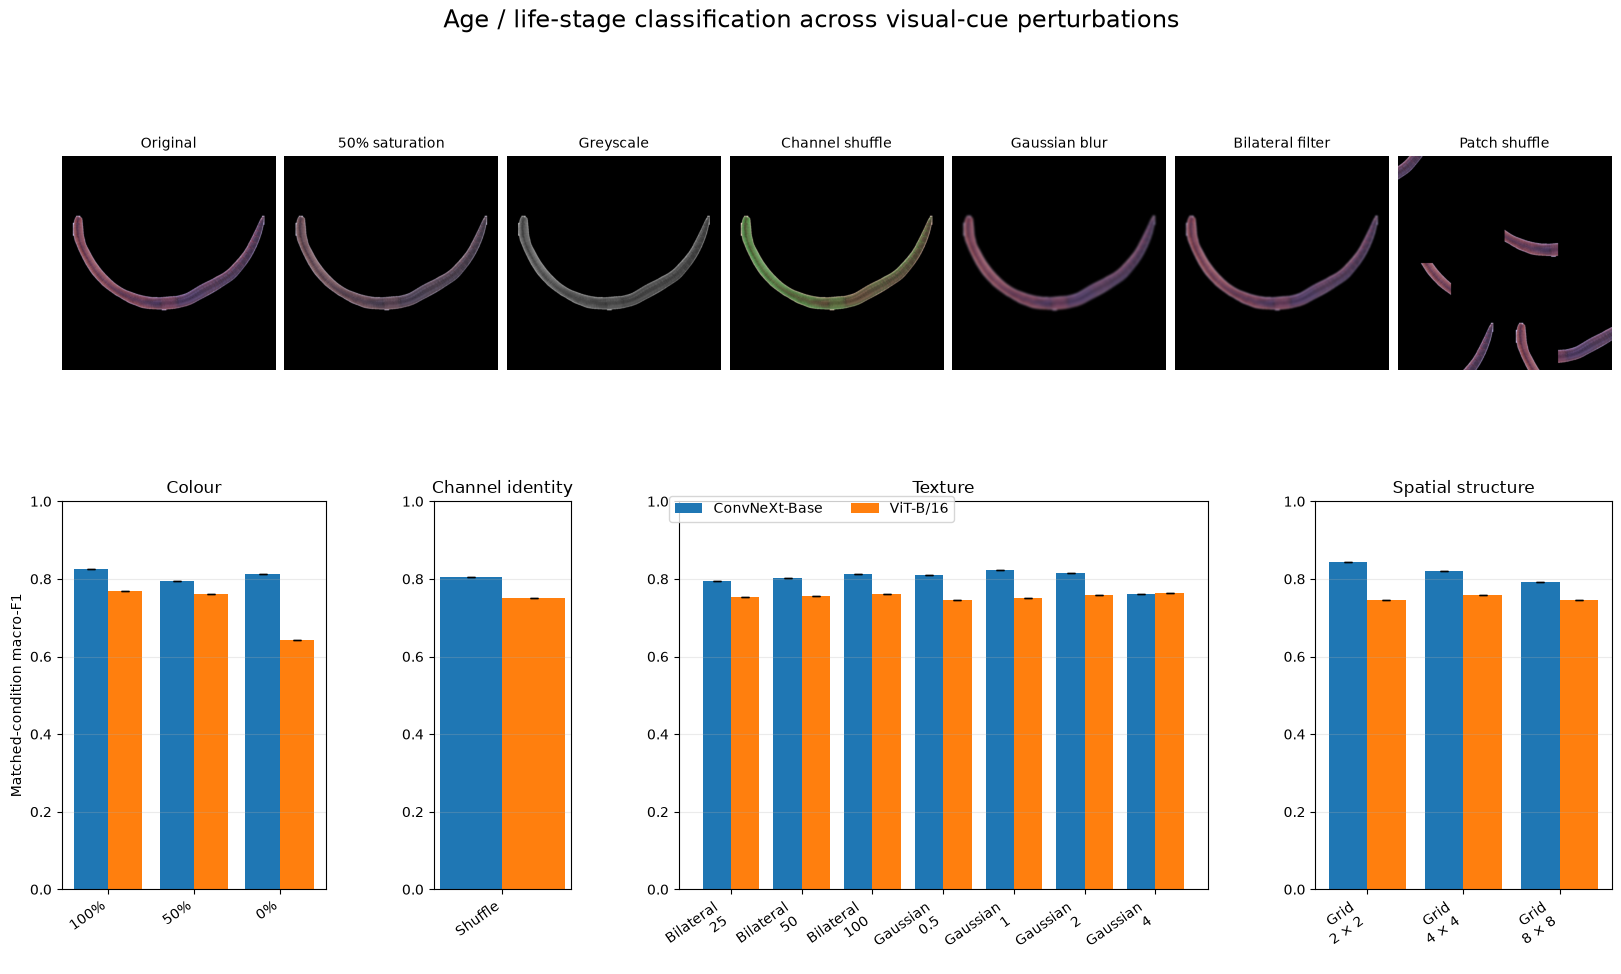

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_age_matched_with_examples.png


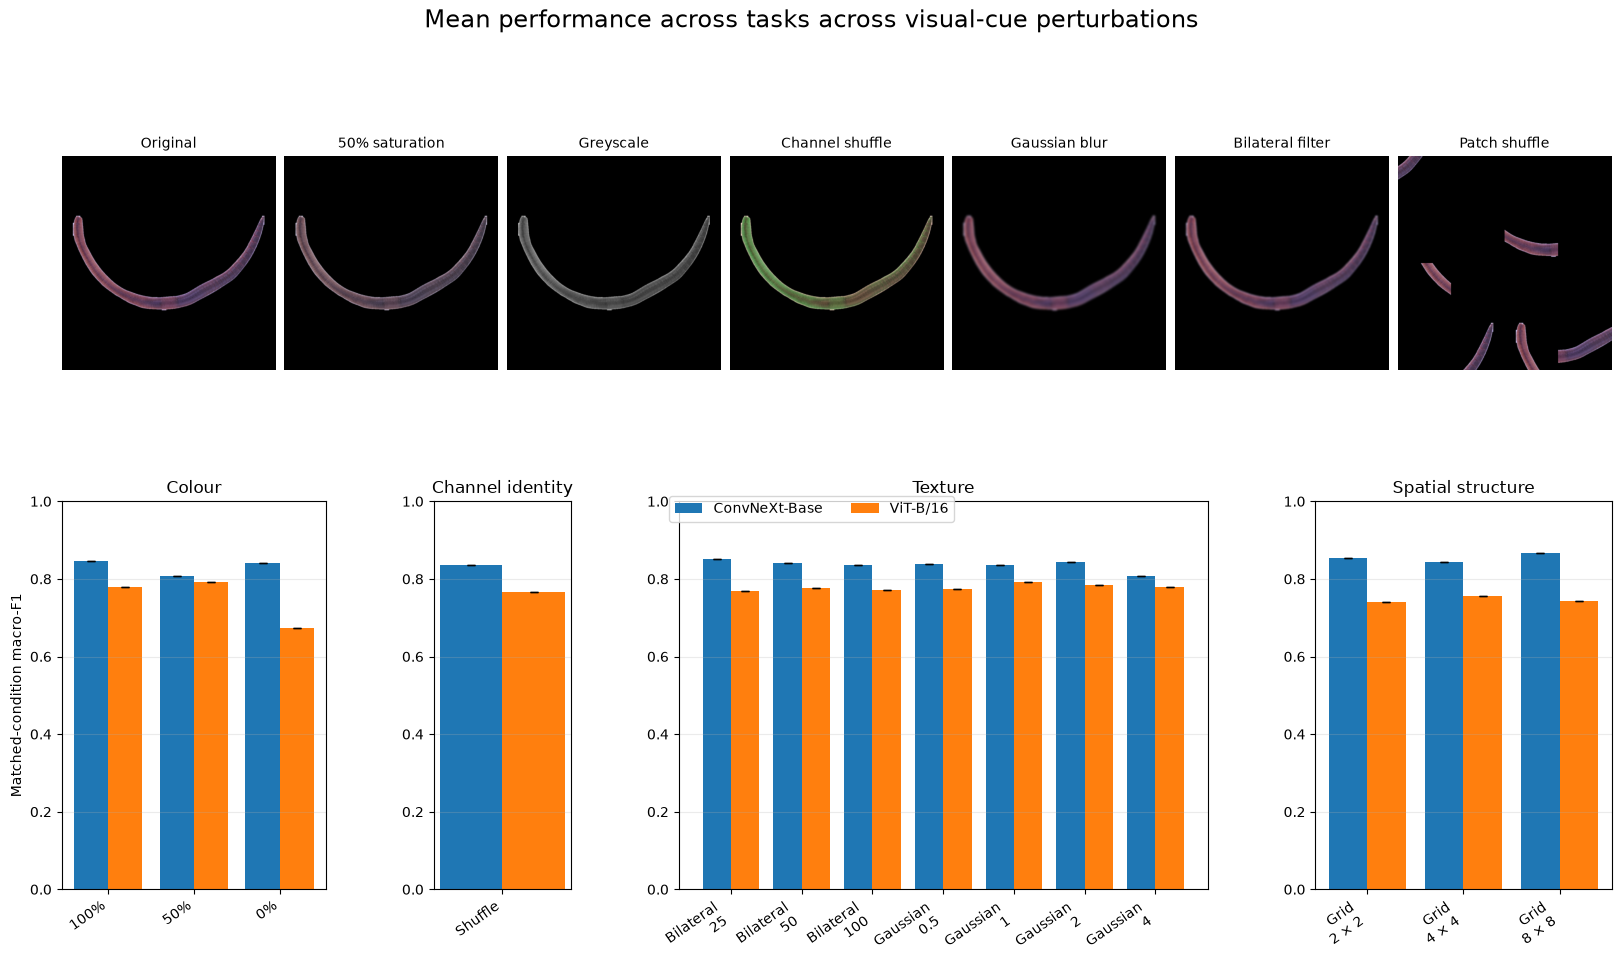

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_mean_matched_with_examples.png


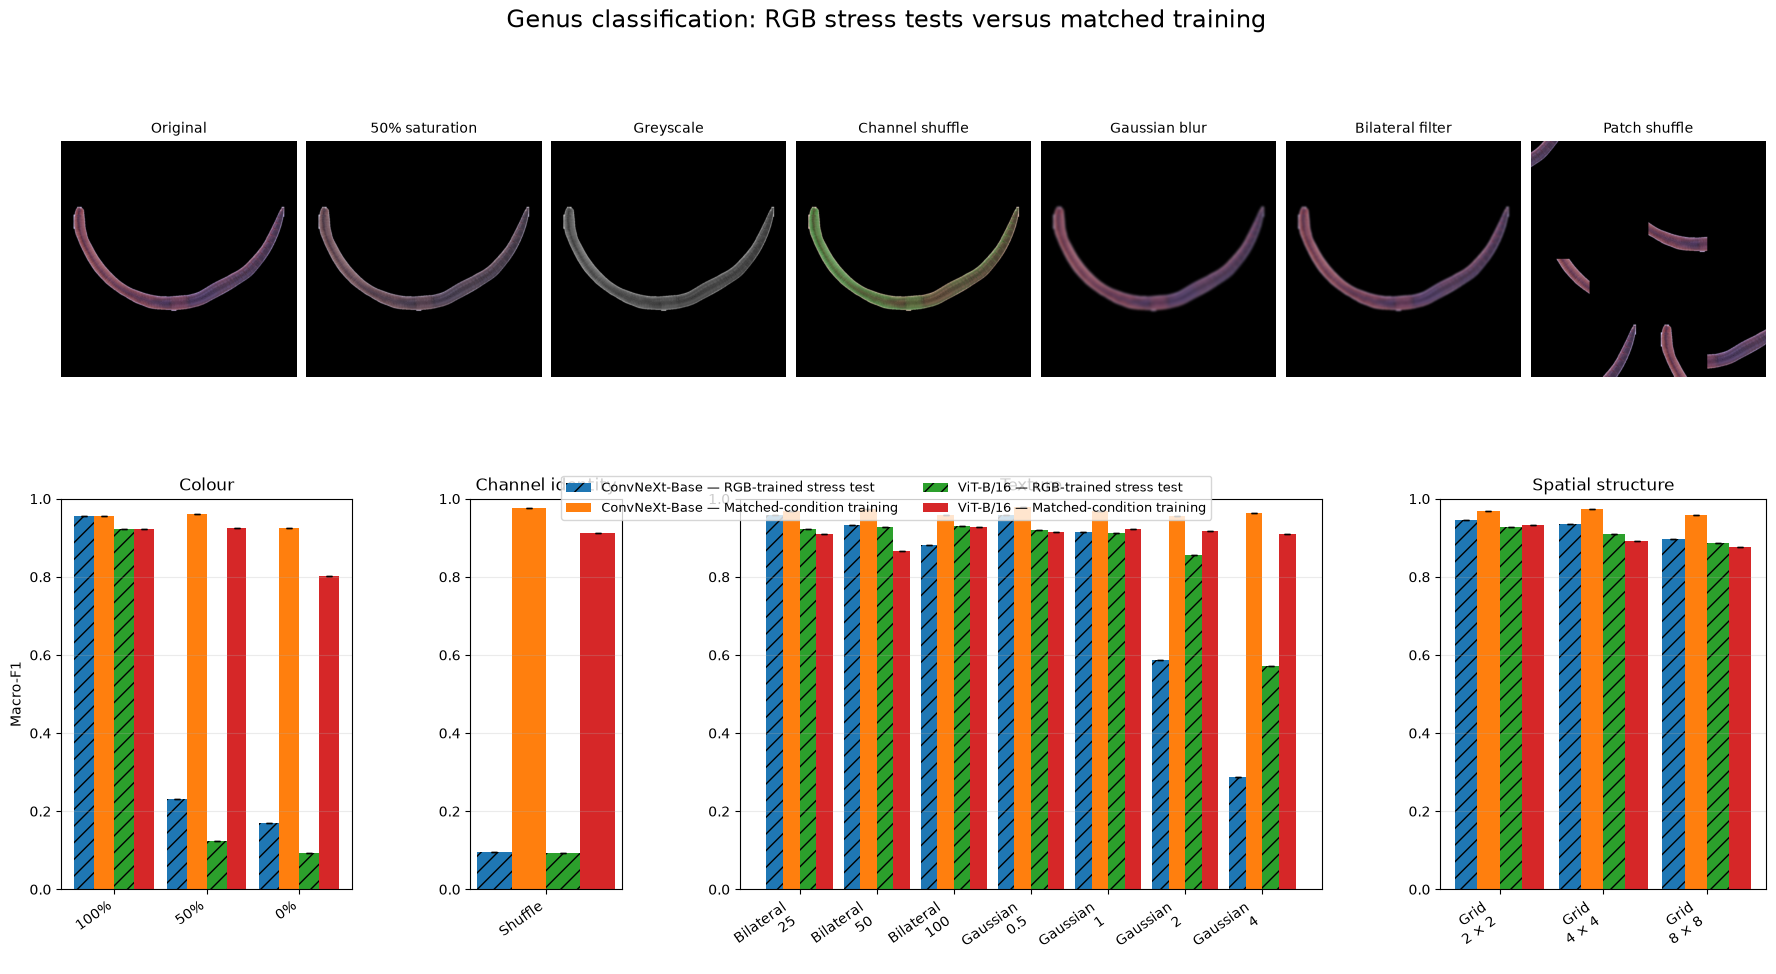

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_genus_stress_vs_matched_with_examples.png


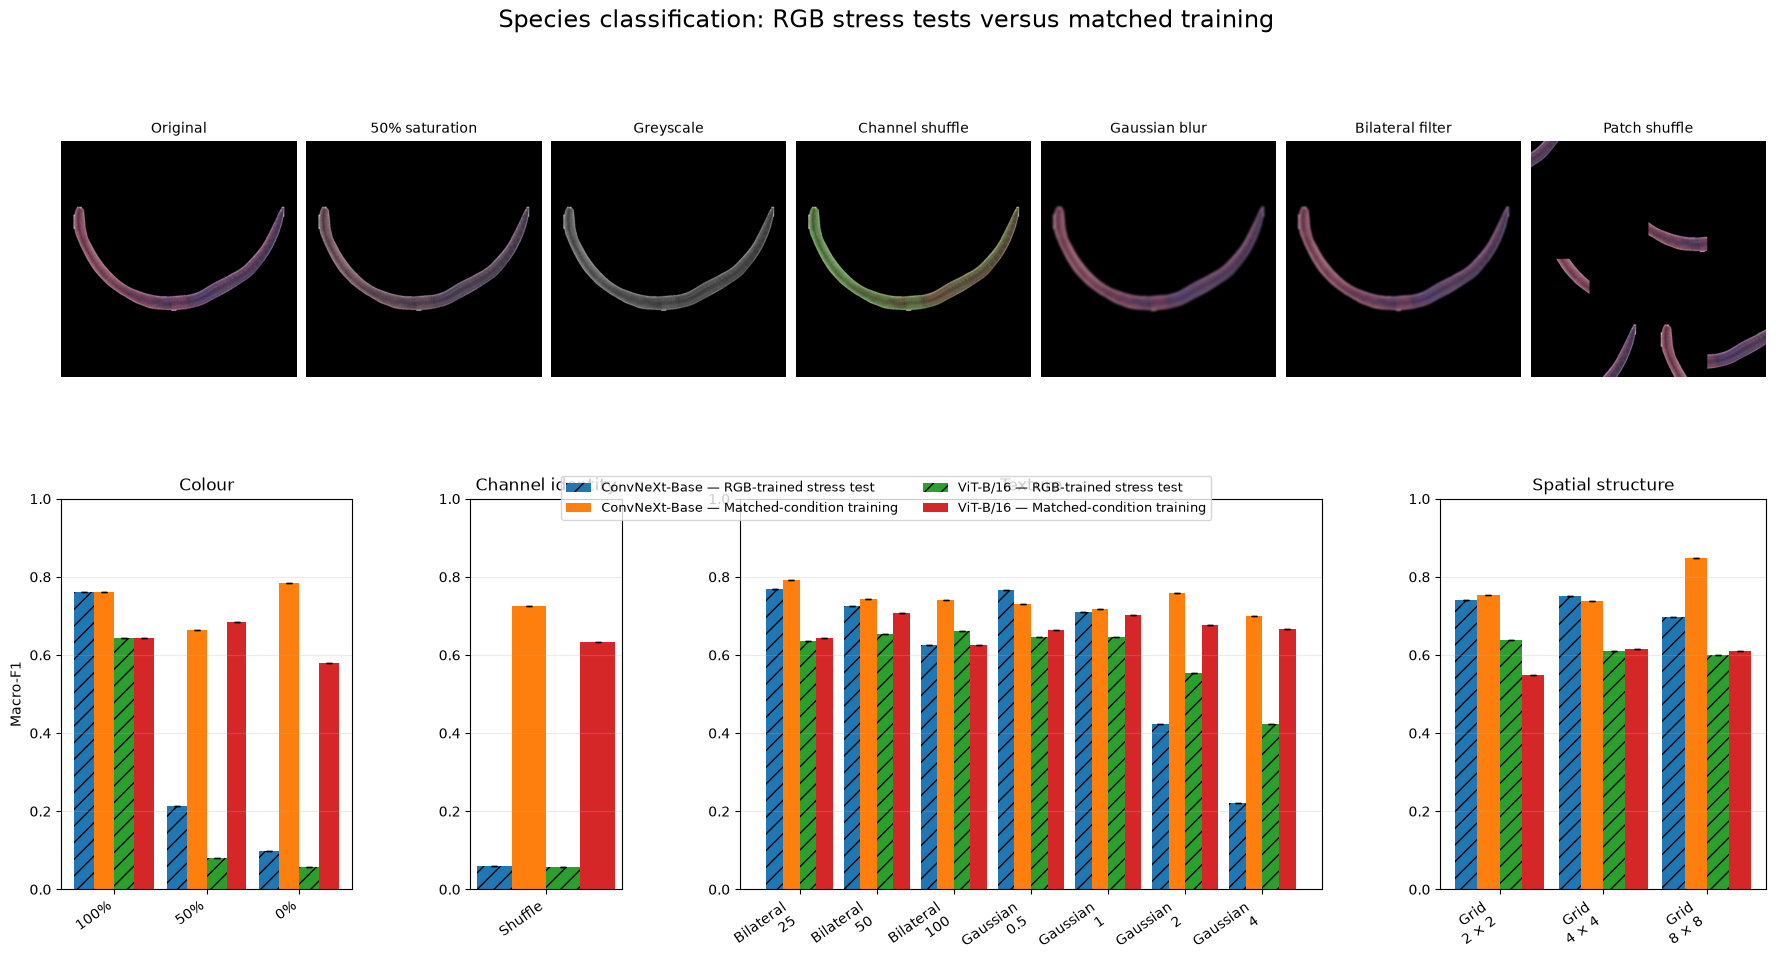

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_species_stress_vs_matched_with_examples.png


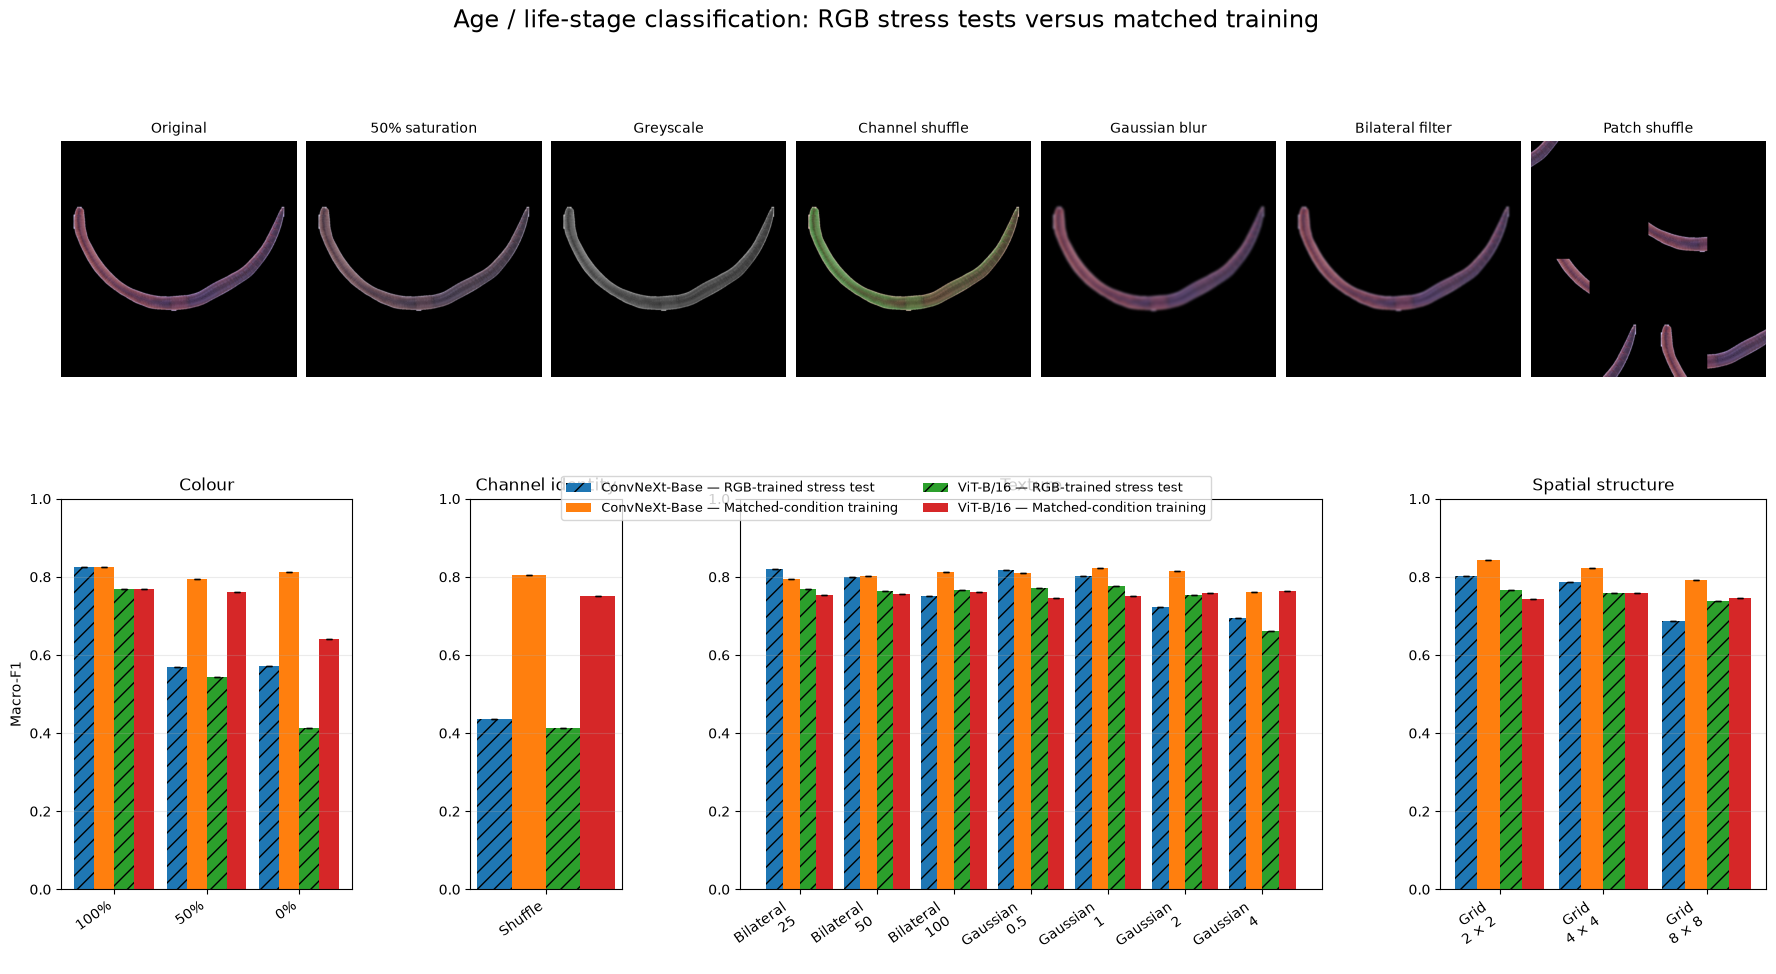

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_age_stress_vs_matched_with_examples.png


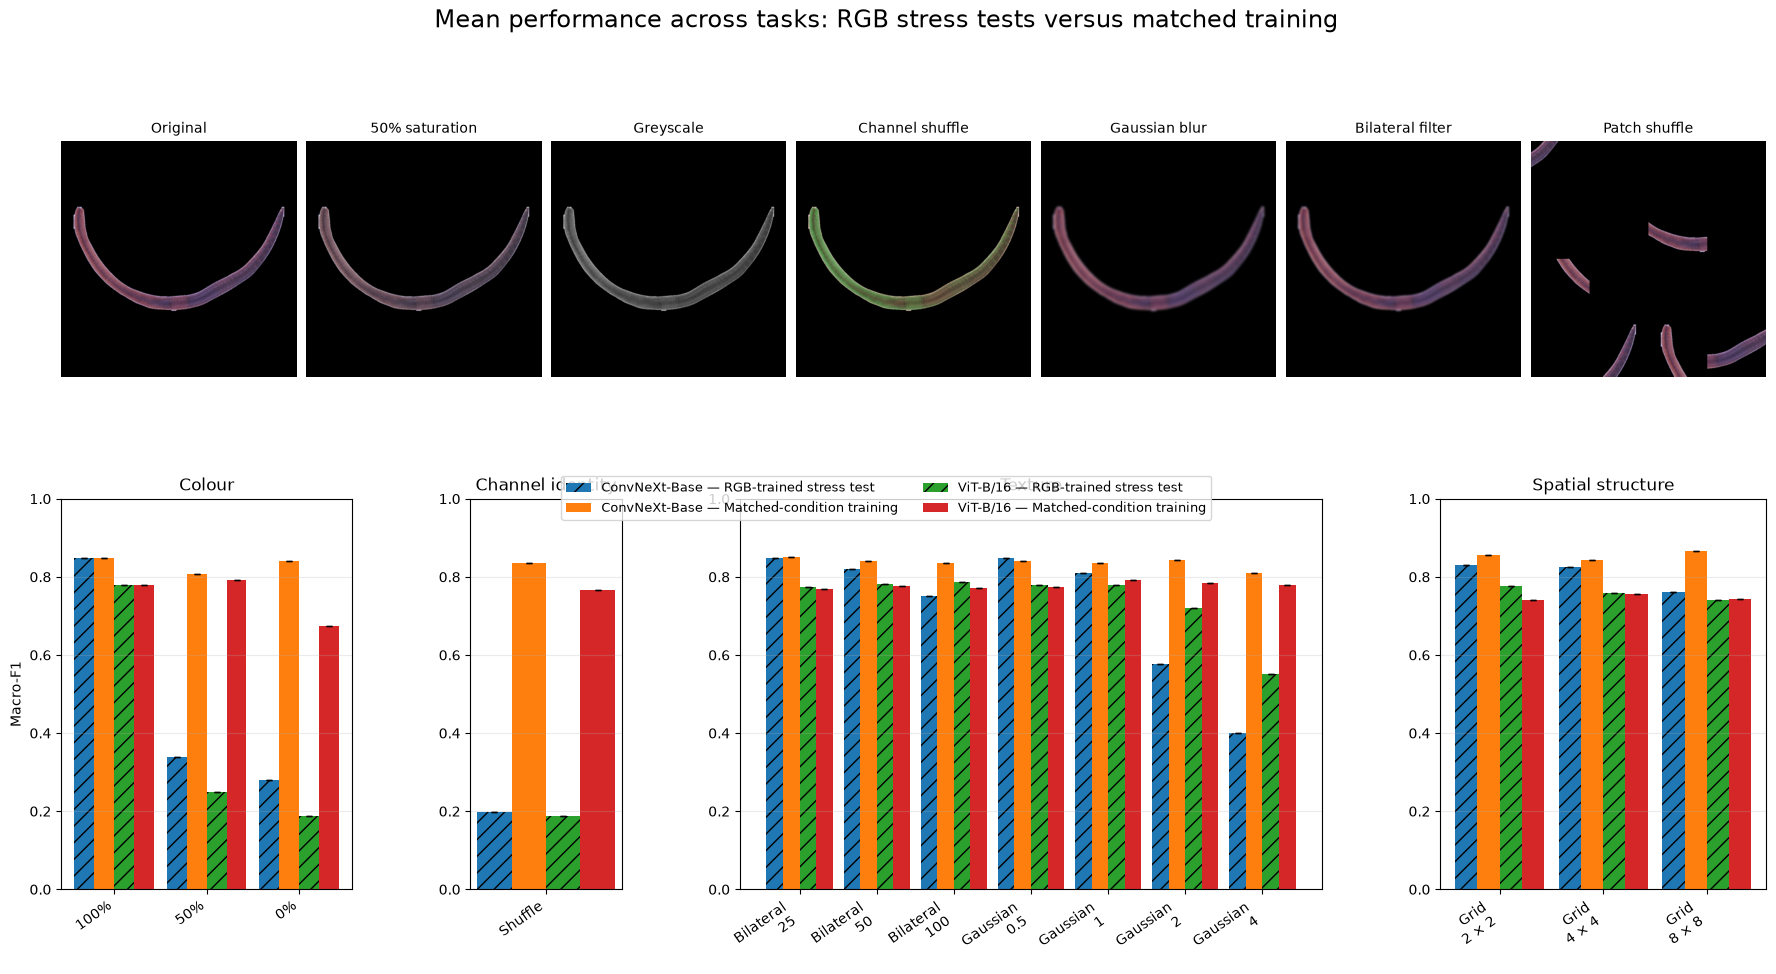

Saved: outputs_slurm/persistent_cache_sweep_20260713_150423/figures_cue_suppression/multipanel_mean_stress_vs_matched_with_examples.png


In [21]:
# ============================================================
# MULTI-PANEL CUE-SUPPRESSION FIGURES WITH EXAMPLE IMAGES
# ============================================================

from pathlib import Path
from matplotlib.container import BarContainer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image, ImageEnhance, ImageFilter, ImageOps


# ============================================================
# CONFIGURATION
# ============================================================

SAMPLE_IMAGE_PATH = Path(
    "/home/devd/worm-species/data/01_Segmented/Lumbricus_sp_terrestris_herculeus_Adult_04/Lumbricus_sp_terrestris_herculeus_Adult_04_4/Lumbricus_sp_terrestris_herculeus_Adult_04_4_seg.jpg"
)

OUTPUT_DIR = Path(
    globals().get(
        "FIGURE_DIR",
        Path.cwd() / "figures_cue_suppression",
    )
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DPI = globals().get(
    "FIGURE_DPI",
    300,
)

TASK_ORDER = [
    "genus",
    "species",
    "age",
    "mean",
]

TASK_TITLES = {
    "genus": "Genus classification",
    "species": "Species classification",
    "age": "Age / life-stage classification",
    "mean": "Mean performance across tasks",
}

ADD_VALUE_LABELS = False


# ============================================================
# CONDITION GROUPS
# ============================================================

PANEL_CONDITIONS = {
    "Colour": [
        "original",
        "saturation_050pct",
        "grayscale",
    ],
    "Channel identity": [
        "channel_shuffle_201",
    ],
    "Texture": [
        "bilateral_d5_c25_s25",
        "bilateral_d7_c50_s50",
        "bilateral_d9_c100_s100",
        "gaussian_sigma_0.5",
        "gaussian_sigma_1",
        "gaussian_sigma_2",
        "gaussian_sigma_4",
    ],
    "Spatial structure": [
        "patch_shuffle_grid_2",
        "patch_shuffle_grid_4",
        "patch_shuffle_grid_8",
    ],
}


CONDITION_LABELS = {
    "original": "100%",
    "saturation_100pct": "100%",
    "saturation_050pct": "50%",
    "grayscale": "0%",
    "greyscale": "0%",
    "saturation_000pct": "0%",

    "channel_shuffle_201": "Shuffle",

    "bilateral_d5_c25_s25": "Bilateral\n25",
    "bilateral_d7_c50_s50": "Bilateral\n50",
    "bilateral_d9_c100_s100": "Bilateral\n100",

    "gaussian_sigma_0.5": "Gaussian\n0.5",
    "gaussian_sigma_1": "Gaussian\n1",
    "gaussian_sigma_2": "Gaussian\n2",
    "gaussian_sigma_4": "Gaussian\n4",

    "patch_shuffle_grid_2": "Grid\n2 × 2",
    "patch_shuffle_grid_4": "Grid\n4 × 4",
    "patch_shuffle_grid_8": "Grid\n8 × 8",
}


# Example images shown at the top of every figure.
EXAMPLE_CONDITIONS = [
    ("Original", "original"),
    ("50% saturation", "saturation_050pct"),
    ("Greyscale", "grayscale"),
    ("Channel shuffle", "channel_shuffle_201"),
    ("Gaussian blur", "gaussian_sigma_2"),
    ("Bilateral filter", "bilateral_d7_c50_s50"),
    ("Patch shuffle", "patch_shuffle_grid_4"),
]


# ============================================================
# DATA PREPARATION
# ============================================================

def ensure_model_label(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """Create readable architecture labels."""

    out = frame.copy()

    if "model_label" in out.columns:
        return out

    labels = {
        "convnext_base": "ConvNeXt-Base",
        "vit_b_16": "ViT-B/16",
    }

    out["model_label"] = (
        out["model"]
        .astype(str)
        .map(labels)
        .fillna(out["model"].astype(str))
    )

    return out


def find_condition_column(
    frame: pd.DataFrame,
) -> str:
    """Find the raw perturbation-condition column."""

    candidates = [
        "condition",
        "train_condition",
        "test_condition",
    ]

    for column in candidates:
        if column in frame.columns:
            return column

    raise KeyError(
        "No condition column was found. "
        "Expected condition, train_condition, or test_condition."
    )


def normalise_condition_name(
    condition: object,
) -> str:
    """
    Map equivalent endpoint aliases to a single condition.
    """

    condition = str(condition).strip().lower()

    aliases = {
        "saturation_100pct": "original",
        "saturation_000pct": "grayscale",
        "greyscale": "grayscale",
    }

    return aliases.get(
        condition,
        condition,
    )


def append_matched_mean_task(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add mean macro-F1 across genus, species, and age when
    the aggregation table does not already contain task='mean'.
    """

    out = frame.copy()
    out["task"] = out["task"].astype(str).str.lower()

    if "mean" in out["task"].unique():
        return out

    condition_column = find_condition_column(out)

    component_rows = out[
        out["task"].isin(
            ["genus", "species", "age"]
        )
    ].copy()

    grouping_columns = [
        column
        for column in [
            "model",
            "model_label",
            condition_column,
            "run_name",
        ]
        if column in component_rows.columns
    ]

    mean_rows = (
        component_rows
        .groupby(
            grouping_columns,
            as_index=False,
            dropna=False,
        )
        .agg(
            matched_test_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            )
        )
    )

    mean_rows["task"] = "mean"

    return pd.concat(
        [out, mean_rows],
        ignore_index=True,
        sort=False,
    )


def append_comparison_mean_task(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add mean performance across genus, species, and age to
    the stress-test versus matched-training table.
    """

    out = frame.copy()
    out["task"] = out["task"].astype(str).str.lower()

    if "mean" in out["task"].unique():
        return out

    condition_column = find_condition_column(out)

    component_rows = out[
        out["task"].isin(
            ["genus", "species", "age"]
        )
    ].copy()

    value_columns = [
        column
        for column in [
            "rgb_model_test_macro_f1",
            "matched_test_macro_f1",
            "adaptation_gain_macro_f1",
            "rgb_original_macro_f1",
            "rgb_ratio_to_original",
            "matched_ratio_to_rgb_original",
        ]
        if column in component_rows.columns
    ]

    grouping_columns = [
        column
        for column in [
            "model",
            "model_label",
            condition_column,
        ]
        if column in component_rows.columns
    ]

    mean_rows = (
        component_rows
        .groupby(
            grouping_columns,
            as_index=False,
            dropna=False,
        )[value_columns]
        .mean()
    )

    mean_rows["task"] = "mean"

    return pd.concat(
        [out, mean_rows],
        ignore_index=True,
        sort=False,
    )


def prepare_matched_data(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prepare matched-condition performance for grouped bars.
    """

    out = ensure_model_label(frame)
    out = append_matched_mean_task(out)

    condition_column = find_condition_column(out)

    out["condition_key"] = (
        out[condition_column]
        .map(normalise_condition_name)
    )

    selected_conditions = {
        condition
        for conditions in PANEL_CONDITIONS.values()
        for condition in conditions
    }

    out = out[
        out["condition_key"].isin(
            selected_conditions
        )
        & out["task"].isin(TASK_ORDER)
    ].copy()

    summary = (
        out
        .groupby(
            [
                "task",
                "condition_key",
                "model_label",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            macro_f1=(
                "matched_test_macro_f1",
                "mean",
            ),
            standard_deviation=(
                "matched_test_macro_f1",
                "std",
            ),
            n=(
                "matched_test_macro_f1",
                "count",
            ),
        )
    )

    summary["standard_error"] = (
        summary["standard_deviation"]
        / np.sqrt(summary["n"])
    )

    summary["standard_error"] = (
        summary["standard_error"]
        .fillna(0.0)
    )

    return summary


def prepare_comparison_data(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Prepare RGB stress-test and matched-training results.
    """

    out = ensure_model_label(frame)
    out = append_comparison_mean_task(out)

    condition_column = find_condition_column(out)

    out["condition_key"] = (
        out[condition_column]
        .map(normalise_condition_name)
    )

    selected_conditions = {
        condition
        for conditions in PANEL_CONDITIONS.values()
        for condition in conditions
    }

    out = out[
        out["condition_key"].isin(
            selected_conditions
        )
        & out["task"].isin(TASK_ORDER)
    ].copy()

    long = out.melt(
        id_vars=[
            "task",
            "condition_key",
            "model_label",
        ],
        value_vars=[
            "rgb_model_test_macro_f1",
            "matched_test_macro_f1",
        ],
        var_name="evaluation_regime",
        value_name="macro_f1",
    )

    long["evaluation_regime"] = (
        long["evaluation_regime"].map({
            "rgb_model_test_macro_f1":
                "RGB-trained stress test",
            "matched_test_macro_f1":
                "Matched-condition training",
        })
    )

    summary = (
        long
        .groupby(
            [
                "task",
                "condition_key",
                "model_label",
                "evaluation_regime",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            macro_f1=("macro_f1", "mean"),
            standard_deviation=("macro_f1", "std"),
            n=("macro_f1", "count"),
        )
    )

    summary["standard_error"] = (
        summary["standard_deviation"]
        / np.sqrt(summary["n"])
    )

    summary["standard_error"] = (
        summary["standard_error"]
        .fillna(0.0)
    )

    return summary


matched_plot_data = prepare_matched_data(
    matched_long
)

comparison_plot_data = prepare_comparison_data(
    comparison
)

MODELS = sorted(
    matched_plot_data["model_label"]
    .dropna()
    .unique()
)


# ============================================================
# EXAMPLE IMAGE TRANSFORMATIONS
# ============================================================

def load_example_image(
    path: Path,
    size: int = 420,
) -> Image.Image:
    """
    Load and center-crop an example image to a square.
    """

    if not path.exists():
        raise FileNotFoundError(
            f"Example image was not found: {path}"
        )

    image = Image.open(path).convert("RGB")

    return ImageOps.fit(
        image,
        (size, size),
        method=Image.Resampling.LANCZOS,
    )


def bilateral_filter(
    image: Image.Image,
    diameter: int,
    sigma_colour: float,
    sigma_space: float,
) -> Image.Image:
    """
    Apply an OpenCV bilateral filter when OpenCV is available.
    """

    try:
        import cv2

        array = np.asarray(image)

        filtered = cv2.bilateralFilter(
            array,
            d=diameter,
            sigmaColor=sigma_colour,
            sigmaSpace=sigma_space,
        )

        return Image.fromarray(filtered)

    except ImportError:
        print(
            "OpenCV is unavailable; using Gaussian blur "
            "for the bilateral-filter preview."
        )

        return image.filter(
            ImageFilter.GaussianBlur(radius=1.5)
        )


def patch_shuffle(
    image: Image.Image,
    grid_size: int,
    seed: int = 2026,
) -> Image.Image:
    """
    Shuffle equal-sized square patches.
    """

    array = np.asarray(image).copy()

    height, width = array.shape[:2]

    usable_height = (
        height // grid_size
    ) * grid_size

    usable_width = (
        width // grid_size
    ) * grid_size

    array = array[
        :usable_height,
        :usable_width,
    ]

    patch_height = usable_height // grid_size
    patch_width = usable_width // grid_size

    patches = []

    for row in range(grid_size):
        for column in range(grid_size):
            patch = array[
                row * patch_height:
                (row + 1) * patch_height,
                column * patch_width:
                (column + 1) * patch_width,
            ].copy()

            patches.append(patch)

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(patches))

    shuffled = np.empty_like(array)

    patch_index = 0

    for row in range(grid_size):
        for column in range(grid_size):
            shuffled[
                row * patch_height:
                (row + 1) * patch_height,
                column * patch_width:
                (column + 1) * patch_width,
            ] = patches[order[patch_index]]

            patch_index += 1

    return Image.fromarray(shuffled)


def transform_example_image(
    image: Image.Image,
    condition: str,
) -> Image.Image:
    """
    Apply one representative cue-suppression condition.
    """

    if condition == "original":
        return image.copy()

    if condition == "saturation_050pct":
        return ImageEnhance.Color(
            image
        ).enhance(0.5)

    if condition == "grayscale":
        return ImageEnhance.Color(
            image
        ).enhance(0.0)

    if condition == "channel_shuffle_201":
        array = np.asarray(image)

        shuffled = array[
            ...,
            [2, 0, 1],
        ]

        return Image.fromarray(shuffled)

    if condition == "gaussian_sigma_2":
        return image.filter(
            ImageFilter.GaussianBlur(radius=2)
        )

    if condition == "bilateral_d7_c50_s50":
        return bilateral_filter(
            image,
            diameter=7,
            sigma_colour=50,
            sigma_space=50,
        )

    if condition == "patch_shuffle_grid_4":
        return patch_shuffle(
            image,
            grid_size=4,
            seed=2026,
        )

    raise ValueError(
        f"Unsupported image transformation: {condition}"
    )


example_image = load_example_image(
    SAMPLE_IMAGE_PATH
)

EXAMPLE_IMAGES = {
    condition: transform_example_image(
        example_image,
        condition,
    )
    for _, condition in EXAMPLE_CONDITIONS
}


# ============================================================
# BAR-LABEL HELPER
# ============================================================

def add_vertical_bar_labels(
    ax: plt.Axes,
    decimals: int = 2,
) -> None:
    """
    Add labels only to actual bar containers, not error bars.
    """

    for container in ax.containers:
        if not isinstance(
            container,
            BarContainer,
        ):
            continue

        labels = []

        for bar in container.patches:
            height = bar.get_height()

            if (
                height is not None
                and np.isfinite(height)
            ):
                labels.append(
                    f"{height:.{decimals}f}"
                )
            else:
                labels.append("")

        ax.bar_label(
            container,
            labels=labels,
            padding=2,
            fontsize=7,
            rotation=90,
        )


# ============================================================
# SHARED IMAGE STRIP
# ============================================================

def draw_example_image_strip(
    figure: plt.Figure,
    grid_spec,
) -> None:
    """
    Draw representative transformed images along the top.
    """

    image_grid = grid_spec.subgridspec(
        1,
        len(EXAMPLE_CONDITIONS),
        wspace=0.04,
    )

    for index, (title, condition) in enumerate(
        EXAMPLE_CONDITIONS
    ):
        ax = figure.add_subplot(
            image_grid[0, index]
        )

        ax.imshow(
            EXAMPLE_IMAGES[condition]
        )

        ax.set_title(
            title,
            fontsize=10,
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)


# ============================================================
# MATCHED-CONDITION FIGURE
# One figure for each task
# ============================================================

def plot_matched_task(
    task: str,
) -> None:
    """
    Plot one task with image examples and four cue panels.
    """

    task_data = matched_plot_data[
        matched_plot_data["task"] == task
    ].copy()

    figure = plt.figure(
        figsize=(20, 10)
    )

    outer_grid = figure.add_gridspec(
        2,
        1,
        height_ratios=[1.0, 1.35],
        hspace=0.28,
    )

    draw_example_image_strip(
        figure,
        outer_grid[0],
    )

    panel_grid = outer_grid[1].subgridspec(
        1,
        4,
        width_ratios=[
            2.5,
            1.3,
            5.0,
            2.8,
        ],
        wspace=0.35,
    )

    panel_axes = []

    for panel_index, (
        panel_title,
        conditions,
    ) in enumerate(PANEL_CONDITIONS.items()):

        ax = figure.add_subplot(
            panel_grid[0, panel_index]
        )

        panel_axes.append(ax)

        panel_data = task_data[
            task_data["condition_key"].isin(
                conditions
            )
        ]

        x = np.arange(
            len(conditions)
        )

        width = 0.8 / max(
            len(MODELS),
            1,
        )

        for model_index, model in enumerate(
            MODELS
        ):
            model_data = (
                panel_data[
                    panel_data["model_label"] == model
                ]
                .set_index("condition_key")
                .reindex(conditions)
            )

            offset = (
                model_index
                - (len(MODELS) - 1) / 2
            ) * width

            values = model_data[
                "macro_f1"
            ].to_numpy(dtype=float)

            errors = model_data[
                "standard_error"
            ].to_numpy(dtype=float)

            ax.bar(
                x + offset,
                values,
                width=width,
                yerr=errors,
                capsize=3,
                label=model,
            )

        ax.set_xticks(x)

        ax.set_xticklabels(
            [
                CONDITION_LABELS[condition]
                for condition in conditions
            ],
            rotation=35,
            ha="right",
        )

        ax.set_title(
            panel_title,
            fontsize=12,
        )

        ax.set_ylim(0, 1)

        ax.set_ylabel(
            "Matched-condition macro-F1"
            if panel_index == 0
            else ""
        )

        ax.grid(
            axis="y",
            alpha=0.25,
        )

        if ADD_VALUE_LABELS:
            add_vertical_bar_labels(ax)

    handles, labels = (
        panel_axes[0]
        .get_legend_handles_labels()
    )

    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.51),
        ncol=max(len(labels), 1),
    )

    figure.suptitle(
        f"{TASK_TITLES[task]} across visual-cue perturbations",
        fontsize=17,
        y=0.99,
    )

    output_path = (
        OUTPUT_DIR
        / f"multipanel_{task}_matched_with_examples.png"
    )

    figure.savefig(
        output_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)


for task in TASK_ORDER:
    plot_matched_task(task)


# ============================================================
# STRESS TEST VERSUS MATCHED-TRAINING FIGURE
# One figure for each task
# ============================================================

def plot_comparison_task(
    task: str,
) -> None:
    """
    Plot RGB stress tests and matched-condition training
    for one task, with separate cue-family panels.
    """

    task_data = comparison_plot_data[
        comparison_plot_data["task"] == task
    ].copy()

    figure = plt.figure(
        figsize=(22, 10)
    )

    outer_grid = figure.add_gridspec(
        2,
        1,
        height_ratios=[1.0, 1.4],
        hspace=0.30,
    )

    draw_example_image_strip(
        figure,
        outer_grid[0],
    )

    panel_grid = outer_grid[1].subgridspec(
        1,
        4,
        width_ratios=[
            2.5,
            1.3,
            5.0,
            2.8,
        ],
        wspace=0.35,
    )

    regimes = [
        "RGB-trained stress test",
        "Matched-condition training",
    ]

    series = [
        (model, regime)
        for model in MODELS
        for regime in regimes
    ]

    panel_axes = []

    for panel_index, (
        panel_title,
        conditions,
    ) in enumerate(PANEL_CONDITIONS.items()):

        ax = figure.add_subplot(
            panel_grid[0, panel_index]
        )

        panel_axes.append(ax)

        panel_data = task_data[
            task_data["condition_key"].isin(
                conditions
            )
        ]

        x = np.arange(
            len(conditions)
        )

        width = 0.86 / max(
            len(series),
            1,
        )

        for series_index, (
            model,
            regime,
        ) in enumerate(series):

            series_data = (
                panel_data[
                    panel_data["model_label"].eq(model)
                    & panel_data[
                        "evaluation_regime"
                    ].eq(regime)
                ]
                .set_index("condition_key")
                .reindex(conditions)
            )

            offset = (
                series_index
                - (len(series) - 1) / 2
            ) * width

            values = series_data[
                "macro_f1"
            ].to_numpy(dtype=float)

            errors = series_data[
                "standard_error"
            ].to_numpy(dtype=float)

            hatch = (
                "//"
                if regime == "RGB-trained stress test"
                else None
            )

            ax.bar(
                x + offset,
                values,
                width=width,
                yerr=errors,
                capsize=2,
                hatch=hatch,
                label=f"{model} — {regime}",
            )

        ax.set_xticks(x)

        ax.set_xticklabels(
            [
                CONDITION_LABELS[condition]
                for condition in conditions
            ],
            rotation=35,
            ha="right",
        )

        ax.set_title(
            panel_title,
            fontsize=12,
        )

        ax.set_ylim(0, 1)

        ax.set_ylabel(
            "Macro-F1"
            if panel_index == 0
            else ""
        )

        ax.grid(
            axis="y",
            alpha=0.25,
        )

        if ADD_VALUE_LABELS:
            add_vertical_bar_labels(ax)

    handles, labels = (
        panel_axes[0]
        .get_legend_handles_labels()
    )

    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.53),
        ncol=2,
        fontsize=9,
    )

    figure.suptitle(
        f"{TASK_TITLES[task]}: RGB stress tests versus matched training",
        fontsize=17,
        y=0.99,
    )

    output_path = (
        OUTPUT_DIR
        / f"multipanel_{task}_stress_vs_matched_with_examples.png"
    )

    figure.savefig(
        output_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)


for task in TASK_ORDER:
    plot_comparison_task(task)

OpenCV is unavailable. Using Gaussian blur for bilateral previews.
OpenCV is unavailable. Using Gaussian blur for bilateral previews.
OpenCV is unavailable. Using Gaussian blur for bilateral previews.


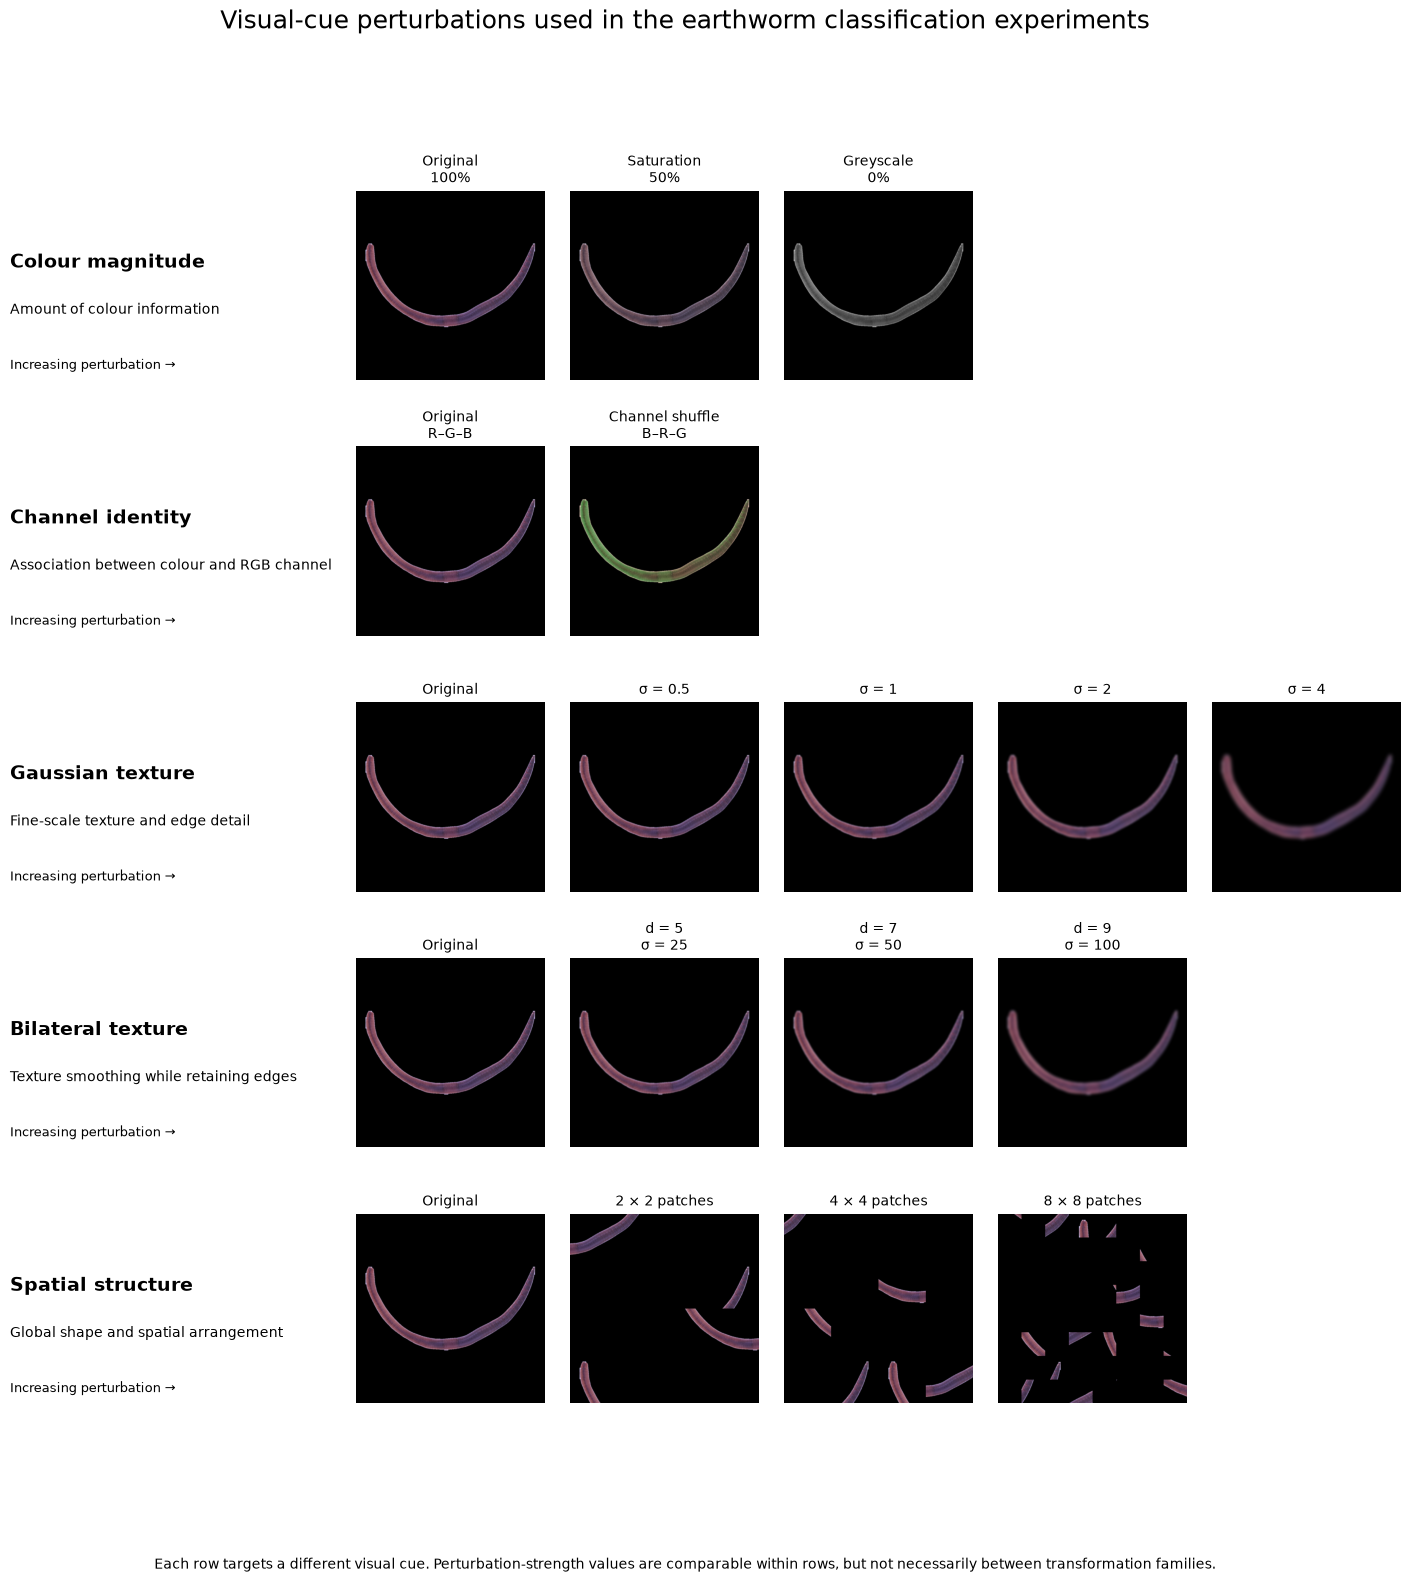

Saved condition atlas to: /faststorage/project/worm-species/source/earthworm_cue_suppression_condition_atlas.png


In [22]:
# ============================================================
# EXPERIMENTAL CONDITION ATLAS
#
# One figure describing all cue-suppression conditions using
# a representative earthworm image.
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image, ImageEnhance, ImageFilter, ImageOps


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SAMPLE_IMAGE_PATH = Path(
    "/home/devd/worm-species/data/01_Segmented/Lumbricus_sp_terrestris_herculeus_Adult_04/Lumbricus_sp_terrestris_herculeus_Adult_04_4/Lumbricus_sp_terrestris_herculeus_Adult_04_4_seg.jpg"

)

OUTPUT_PATH = PROJECT_ROOT / "figures/cue_suppression/earthworm_cue_suppression_condition_atlas.png"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 420
PATCH_SHUFFLE_SEED = 2026


# ------------------------------------------------------------
# Load and standardise the example image
# ------------------------------------------------------------

def load_square_image(
    path: Path,
    size: int = IMAGE_SIZE,
) -> Image.Image:
    if not path.exists():
        raise FileNotFoundError(
            f"Image not found: {path}"
        )

    image = Image.open(path).convert("RGB")

    return ImageOps.fit(
        image,
        (size, size),
        method=Image.Resampling.LANCZOS,
    )


original = load_square_image(
    SAMPLE_IMAGE_PATH
)


# ------------------------------------------------------------
# Transformations
# ------------------------------------------------------------

def change_saturation(
    image: Image.Image,
    retained_saturation: float,
) -> Image.Image:
    """
    retained_saturation:
        1.0 = original colour
        0.5 = half saturation
        0.0 = greyscale
    """
    return ImageEnhance.Color(
        image
    ).enhance(retained_saturation)


def channel_shuffle_201(
    image: Image.Image,
) -> Image.Image:
    """
    Transform RGB channels from [R, G, B] to [B, R, G].
    """
    array = np.asarray(image)

    shuffled = array[
        ...,
        [2, 0, 1],
    ]

    return Image.fromarray(shuffled)


def gaussian_blur(
    image: Image.Image,
    sigma: float,
) -> Image.Image:
    return image.filter(
        ImageFilter.GaussianBlur(
            radius=sigma
        )
    )


def bilateral_filter(
    image: Image.Image,
    diameter: int,
    sigma_colour: float,
    sigma_space: float,
) -> Image.Image:
    """
    Requires OpenCV.

    If OpenCV is unavailable, the function falls back to a
    Gaussian blur so that the figure can still be produced.
    """

    try:
        import cv2

        array = np.asarray(image)

        filtered = cv2.bilateralFilter(
            array,
            d=diameter,
            sigmaColor=sigma_colour,
            sigmaSpace=sigma_space,
        )

        return Image.fromarray(filtered)

    except ImportError:
        print(
            "OpenCV is unavailable. "
            "Using Gaussian blur for bilateral previews."
        )

        fallback_radius = (
            sigma_colour / 35.0
        )

        return gaussian_blur(
            image,
            sigma=fallback_radius,
        )


def patch_shuffle(
    image: Image.Image,
    grid_size: int,
    seed: int = PATCH_SHUFFLE_SEED,
) -> Image.Image:
    """
    Divide the image into grid_size × grid_size patches and
    randomly permute their locations.
    """

    array = np.asarray(image).copy()

    height, width = array.shape[:2]

    usable_height = (
        height // grid_size
    ) * grid_size

    usable_width = (
        width // grid_size
    ) * grid_size

    array = array[
        :usable_height,
        :usable_width,
    ]

    patch_height = (
        usable_height // grid_size
    )

    patch_width = (
        usable_width // grid_size
    )

    patches = []

    for row in range(grid_size):
        for column in range(grid_size):
            patch = array[
                row * patch_height:
                (row + 1) * patch_height,
                column * patch_width:
                (column + 1) * patch_width,
            ].copy()

            patches.append(patch)

    rng = np.random.default_rng(seed)
    order = rng.permutation(
        len(patches)
    )

    shuffled = np.empty_like(array)

    patch_index = 0

    for row in range(grid_size):
        for column in range(grid_size):
            shuffled[
                row * patch_height:
                (row + 1) * patch_height,
                column * patch_width:
                (column + 1) * patch_width,
            ] = patches[
                order[patch_index]
            ]

            patch_index += 1

    return Image.fromarray(shuffled)


# ------------------------------------------------------------
# Define the experimental-condition rows
# ------------------------------------------------------------

condition_rows = [
    {
        "family": "Colour magnitude",
        "target": "Amount of colour information",
        "images": [
            original,
            change_saturation(
                original,
                retained_saturation=0.50,
            ),
            change_saturation(
                original,
                retained_saturation=0.00,
            ),
        ],
        "labels": [
            "Original\n100%",
            "Saturation\n50%",
            "Greyscale\n0%",
        ],
    },
    {
        "family": "Channel identity",
        "target": "Association between colour and RGB channel",
        "images": [
            original,
            channel_shuffle_201(
                original
            ),
        ],
        "labels": [
            "Original\nR–G–B",
            "Channel shuffle\nB–R–G",
        ],
    },
    {
        "family": "Gaussian texture",
        "target": "Fine-scale texture and edge detail",
        "images": [
            original,
            gaussian_blur(
                original,
                sigma=0.5,
            ),
            gaussian_blur(
                original,
                sigma=1.0,
            ),
            gaussian_blur(
                original,
                sigma=2.0,
            ),
            gaussian_blur(
                original,
                sigma=4.0,
            ),
        ],
        "labels": [
            "Original",
            "σ = 0.5",
            "σ = 1",
            "σ = 2",
            "σ = 4",
        ],
    },
    {
        "family": "Bilateral texture",
        "target": "Texture smoothing while retaining edges",
        "images": [
            original,
            bilateral_filter(
                original,
                diameter=5,
                sigma_colour=25,
                sigma_space=25,
            ),
            bilateral_filter(
                original,
                diameter=7,
                sigma_colour=50,
                sigma_space=50,
            ),
            bilateral_filter(
                original,
                diameter=9,
                sigma_colour=100,
                sigma_space=100,
            ),
        ],
        "labels": [
            "Original",
            "d = 5\nσ = 25",
            "d = 7\nσ = 50",
            "d = 9\nσ = 100",
        ],
    },
    {
        "family": "Spatial structure",
        "target": "Global shape and spatial arrangement",
        "images": [
            original,
            patch_shuffle(
                original,
                grid_size=2,
            ),
            patch_shuffle(
                original,
                grid_size=4,
            ),
            patch_shuffle(
                original,
                grid_size=8,
            ),
        ],
        "labels": [
            "Original",
            "2 × 2 patches",
            "4 × 4 patches",
            "8 × 8 patches",
        ],
    },
]


# ------------------------------------------------------------
# Create the figure
# ------------------------------------------------------------

n_rows = len(condition_rows)

# Five image columns are required because Gaussian blur has
# five conditions including the original image.
n_image_columns = max(
    len(row["images"])
    for row in condition_rows
)

fig = plt.figure(
    figsize=(18, 3.15 * n_rows)
)

grid = fig.add_gridspec(
    n_rows,
    n_image_columns + 1,
    width_ratios=[
        1.65,
        *([1.0] * n_image_columns),
    ],
    hspace=0.35,
    wspace=0.08,
)


for row_index, condition_row in enumerate(
    condition_rows
):
    # --------------------------------------------------------
    # Row description
    # --------------------------------------------------------

    label_ax = fig.add_subplot(
        grid[row_index, 0]
    )

    label_ax.axis("off")

    label_ax.text(
        0.0,
        0.62,
        condition_row["family"],
        fontsize=14,
        fontweight="bold",
        va="center",
    )

    label_ax.text(
        0.0,
        0.37,
        condition_row["target"],
        fontsize=10,
        va="center",
        wrap=True,
    )

    # Arrow indicating increasing perturbation strength
    if len(condition_row["images"]) > 1:
        label_ax.text(
            0.0,
            0.08,
            "Increasing perturbation →",
            fontsize=9,
            va="center",
        )

    # --------------------------------------------------------
    # Transformation images
    # --------------------------------------------------------

    for column_index in range(
        n_image_columns
    ):
        image_ax = fig.add_subplot(
            grid[
                row_index,
                column_index + 1,
            ]
        )

        image_ax.set_xticks([])
        image_ax.set_yticks([])

        for spine in image_ax.spines.values():
            spine.set_visible(False)

        if column_index < len(
            condition_row["images"]
        ):
            image_ax.imshow(
                condition_row["images"][
                    column_index
                ]
            )

            image_ax.set_title(
                condition_row["labels"][
                    column_index
                ],
                fontsize=10,
                pad=6,
            )
        else:
            image_ax.axis("off")


fig.suptitle(
    "Visual-cue perturbations used in the earthworm classification experiments",
    fontsize=18,
    y=0.995,
)

fig.text(
    0.5,
    0.005,
    (
        "Each row targets a different visual cue. "
        "Perturbation-strength values are comparable within rows, "
        "but not necessarily between transformation families."
    ),
    ha="center",
    fontsize=10,
)

fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved condition atlas to: {OUTPUT_PATH.resolve()}"
)

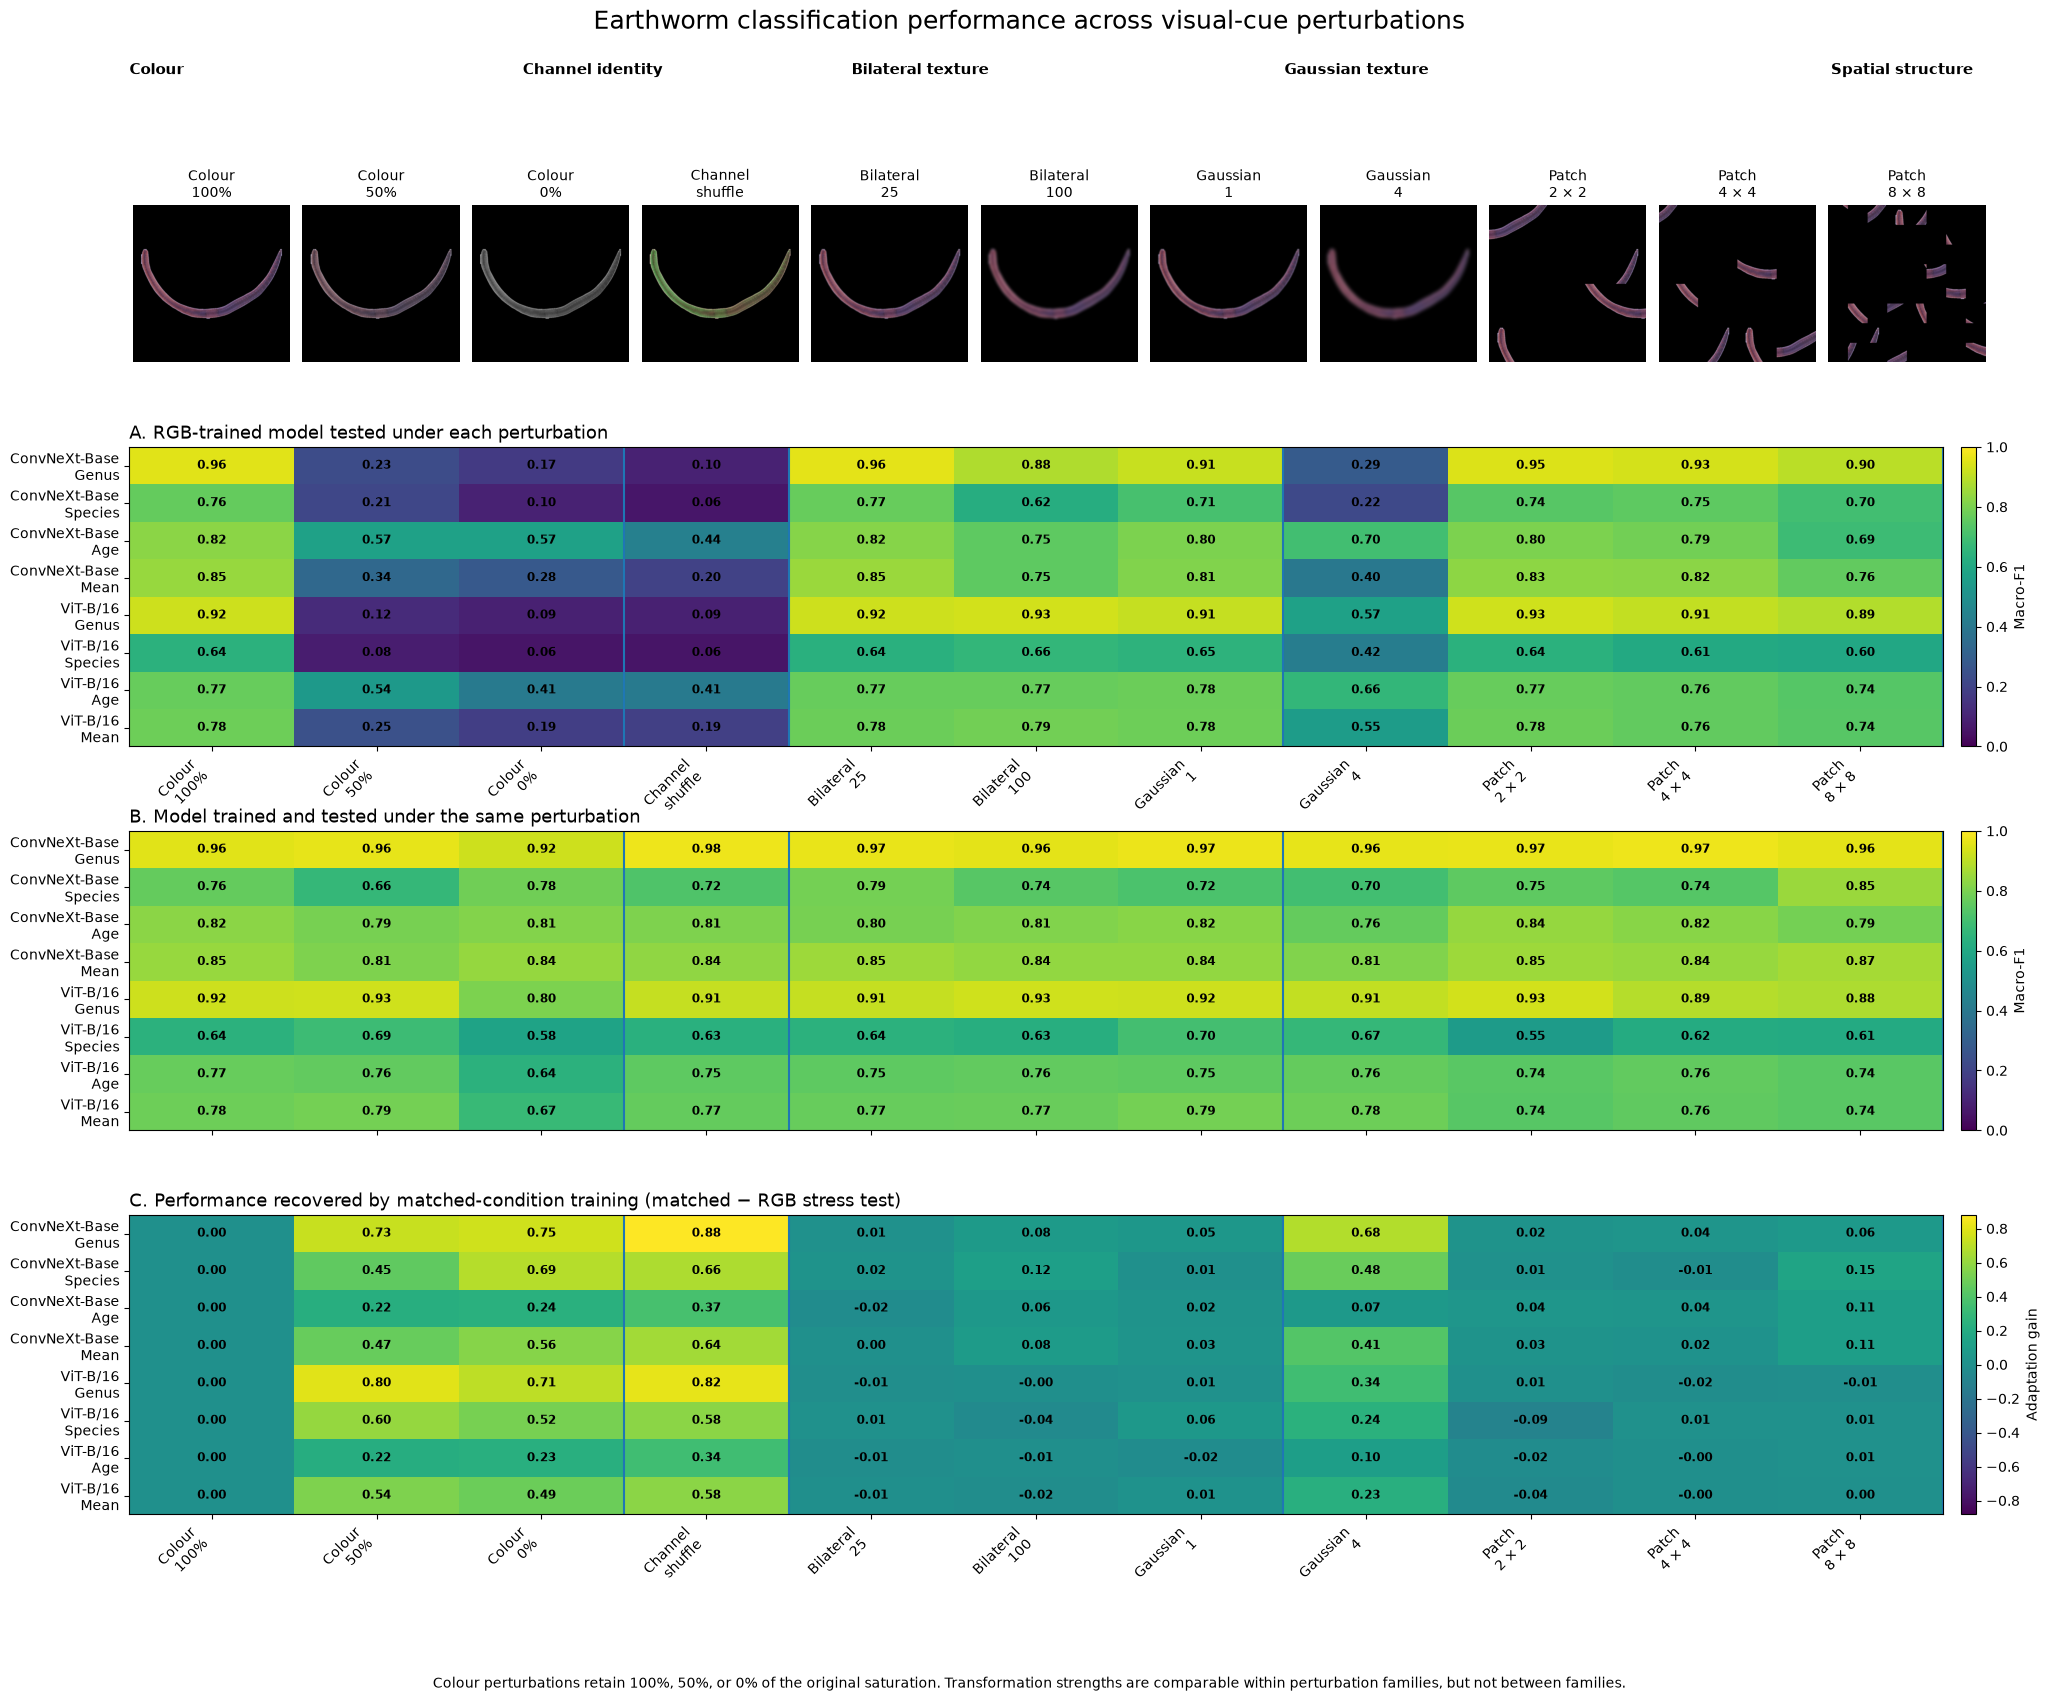

Saved results atlas to: /faststorage/project/worm-species/source/earthworm_cue_suppression_results_atlas.png


In [24]:
# ============================================================
# CUE-SUPPRESSION RESULTS ATLAS
#
# Columns:
#   Selected colour conditions + all channel, texture and
#   spatial-structure conditions
#
# Rows:
#   Example transformed images
#   RGB-trained stress-test macro-F1
#   Matched-condition macro-F1
#   Adaptation gain
#
# Requires:
#   matched_long
#   comparison
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image, ImageEnhance, ImageFilter, ImageOps


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

OUTPUT_PATH = PROJECT_ROOT / "figures/cue_suppression/earthworm_cue_suppression_results_atlas.png"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

FIGURE_DPI = 600
ANNOTATE_VALUES = True
PATCH_SHUFFLE_SEED = 2026

TASK_ORDER = [
    "genus",
    "species",
    "age",
    "mean",
]

MODEL_ORDER = [
    "ConvNeXt-Base",
    "ViT-B/16",
]


# Only three saturation conditions are retained.
CONDITION_ORDER = [
    "original",
    "saturation_050pct",
    "grayscale",

    "channel_shuffle_201",

    "bilateral_d5_c25_s25",
   
    "bilateral_d9_c100_s100",

   
    "gaussian_sigma_1",
   
    "gaussian_sigma_4",

    "patch_shuffle_grid_2",
    "patch_shuffle_grid_4",
    "patch_shuffle_grid_8",
]


CONDITION_LABELS = {
    "original": "Colour\n100%",
    "saturation_050pct": "Colour\n50%",
    "grayscale": "Colour\n0%",

    "channel_shuffle_201": "Channel\nshuffle",

    "bilateral_d5_c25_s25": "Bilateral\n25",
    "bilateral_d7_c50_s50": "Bilateral\n50",
    "bilateral_d9_c100_s100": "Bilateral\n100",

    "gaussian_sigma_0.5": "Gaussian\n0.5",
    "gaussian_sigma_1": "Gaussian\n1",
    "gaussian_sigma_2": "Gaussian\n2",
    "gaussian_sigma_4": "Gaussian\n4",

    "patch_shuffle_grid_2": "Patch\n2 × 2",
    "patch_shuffle_grid_4": "Patch\n4 × 4",
    "patch_shuffle_grid_8": "Patch\n8 × 8",
}


# Family boundaries used to separate the condition groups.
FAMILY_RANGES = {
    "Colour": (0, 3),
    "Channel identity": (3, 4),
    "Bilateral texture": (4, 6),
    "Gaussian texture": (6, 8),
    "Spatial structure": (8, 11),
}


# ============================================================
# DATA HELPERS
# ============================================================

def ensure_model_label(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    out = frame.copy()

    if "model_label" in out.columns:
        return out

    mapping = {
        "convnext_base": "ConvNeXt-Base",
        "vit_b_16": "ViT-B/16",
    }

    out["model_label"] = (
        out["model"]
        .astype(str)
        .map(mapping)
        .fillna(out["model"].astype(str))
    )

    return out


def find_condition_column(
    frame: pd.DataFrame,
) -> str:
    for column in [
        "condition",
        "train_condition",
        "test_condition",
    ]:
        if column in frame.columns:
            return column

    raise KeyError(
        "Could not find condition, train_condition, "
        "or test_condition."
    )


def normalise_condition(
    value: object,
) -> str:
    value = str(value).strip().lower()

    aliases = {
        "saturation_100pct": "original",
        "saturation_000pct": "grayscale",
        "greyscale": "grayscale",
    }

    return aliases.get(value, value)


def append_matched_mean(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add arithmetic mean across genus, species and age if the
    matched-condition table does not already contain task=mean.
    """

    out = frame.copy()
    out["task"] = out["task"].astype(str).str.lower()

    if "mean" in out["task"].unique():
        return out

    condition_column = find_condition_column(out)

    component_rows = out[
        out["task"].isin(
            ["genus", "species", "age"]
        )
    ].copy()

    grouping_columns = [
        column
        for column in [
            "model",
            "model_label",
            condition_column,
            "run_name",
        ]
        if column in component_rows.columns
    ]

    mean_rows = (
        component_rows
        .groupby(
            grouping_columns,
            as_index=False,
            dropna=False,
        )
        .agg(
            matched_test_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            )
        )
    )

    mean_rows["task"] = "mean"

    return pd.concat(
        [out, mean_rows],
        ignore_index=True,
        sort=False,
    )


def append_comparison_mean(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """
    Add arithmetic mean across genus, species and age to the
    stress-test versus matched-training table.
    """

    out = frame.copy()
    out["task"] = out["task"].astype(str).str.lower()

    if "mean" in out["task"].unique():
        return out

    condition_column = find_condition_column(out)

    value_columns = [
        column
        for column in [
            "rgb_model_test_macro_f1",
            "matched_test_macro_f1",
            "adaptation_gain_macro_f1",
        ]
        if column in out.columns
    ]

    grouping_columns = [
        column
        for column in [
            "model",
            "model_label",
            condition_column,
        ]
        if column in out.columns
    ]

    component_rows = out[
        out["task"].isin(
            ["genus", "species", "age"]
        )
    ]

    mean_rows = (
        component_rows
        .groupby(
            grouping_columns,
            as_index=False,
            dropna=False,
        )[value_columns]
        .mean()
    )

    mean_rows["task"] = "mean"

    return pd.concat(
        [out, mean_rows],
        ignore_index=True,
        sort=False,
    )


def prepare_matched(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    out = ensure_model_label(frame)
    out = append_matched_mean(out)

    condition_column = find_condition_column(out)

    out["condition_key"] = (
        out[condition_column]
        .map(normalise_condition)
    )

    out["task"] = (
        out["task"]
        .astype(str)
        .str.lower()
    )

    out = out[
        out["condition_key"].isin(CONDITION_ORDER)
        & out["task"].isin(TASK_ORDER)
    ].copy()

    return (
        out
        .groupby(
            [
                "model_label",
                "task",
                "condition_key",
            ],
            as_index=False,
        )
        .agg(
            matched_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            )
        )
    )


def prepare_comparison(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    out = ensure_model_label(frame)
    out = append_comparison_mean(out)

    condition_column = find_condition_column(out)

    out["condition_key"] = (
        out[condition_column]
        .map(normalise_condition)
    )

    out["task"] = (
        out["task"]
        .astype(str)
        .str.lower()
    )

    out = out[
        out["condition_key"].isin(CONDITION_ORDER)
        & out["task"].isin(TASK_ORDER)
    ].copy()

    return (
        out
        .groupby(
            [
                "model_label",
                "task",
                "condition_key",
            ],
            as_index=False,
        )
        .agg(
            rgb_stress_macro_f1=(
                "rgb_model_test_macro_f1",
                "mean",
            ),
            matched_macro_f1=(
                "matched_test_macro_f1",
                "mean",
            ),
            adaptation_gain=(
                "adaptation_gain_macro_f1",
                "mean",
            ),
        )
    )


matched_summary = prepare_matched(
    matched_long
)

comparison_summary = prepare_comparison(
    comparison
)


# ============================================================
# CREATE RESULT MATRICES
# ============================================================

ROW_ORDER = [
    (model, task)
    for model in MODEL_ORDER
    for task in TASK_ORDER
]


ROW_LABELS = [
    f"{model}\n{task.capitalize()}"
    for model, task in ROW_ORDER
]


def result_matrix(
    frame: pd.DataFrame,
    value_column: str,
) -> np.ndarray:
    matrix = (
        frame
        .pivot_table(
            index=[
                "model_label",
                "task",
            ],
            columns="condition_key",
            values=value_column,
            aggfunc="mean",
        )
        .reindex(
            index=pd.MultiIndex.from_tuples(
                ROW_ORDER,
                names=[
                    "model_label",
                    "task",
                ],
            ),
            columns=CONDITION_ORDER,
        )
    )

    return matrix.to_numpy(
        dtype=float
    )


rgb_stress_matrix = result_matrix(
    comparison_summary,
    "rgb_stress_macro_f1",
)

matched_matrix = result_matrix(
    comparison_summary,
    "matched_macro_f1",
)

gain_matrix = result_matrix(
    comparison_summary,
    "adaptation_gain",
)


# ============================================================
# EXAMPLE IMAGE TRANSFORMATIONS
# ============================================================

def load_example_image(
    path: Path,
    size: int = 360,
) -> Image.Image:
    if not path.exists():
        raise FileNotFoundError(
            f"Example image not found: {path}"
        )

    image = Image.open(path).convert("RGB")

    return ImageOps.fit(
        image,
        (size, size),
        method=Image.Resampling.LANCZOS,
    )


def channel_shuffle(
    image: Image.Image,
) -> Image.Image:
    array = np.asarray(image)

    return Image.fromarray(
        array[..., [2, 0, 1]]
    )


def gaussian_blur(
    image: Image.Image,
    sigma: float,
) -> Image.Image:
    return image.filter(
        ImageFilter.GaussianBlur(
            radius=sigma
        )
    )


def bilateral_filter(
    image: Image.Image,
    diameter: int,
    sigma_colour: float,
    sigma_space: float,
) -> Image.Image:
    try:
        import cv2

        array = np.asarray(image)

        filtered = cv2.bilateralFilter(
            array,
            d=diameter,
            sigmaColor=sigma_colour,
            sigmaSpace=sigma_space,
        )

        return Image.fromarray(filtered)

    except ImportError:
        # The figure still runs without OpenCV.
        radius = sigma_colour / 35

        return gaussian_blur(
            image,
            sigma=radius,
        )


def patch_shuffle(
    image: Image.Image,
    grid_size: int,
    seed: int = PATCH_SHUFFLE_SEED,
) -> Image.Image:
    array = np.asarray(image).copy()

    height, width = array.shape[:2]

    usable_height = (
        height // grid_size
    ) * grid_size

    usable_width = (
        width // grid_size
    ) * grid_size

    array = array[
        :usable_height,
        :usable_width,
    ]

    patch_height = (
        usable_height // grid_size
    )

    patch_width = (
        usable_width // grid_size
    )

    patches = []

    for row in range(grid_size):
        for column in range(grid_size):
            patches.append(
                array[
                    row * patch_height:
                    (row + 1) * patch_height,
                    column * patch_width:
                    (column + 1) * patch_width,
                ].copy()
            )

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(patches))

    shuffled = np.empty_like(array)

    position = 0

    for row in range(grid_size):
        for column in range(grid_size):
            shuffled[
                row * patch_height:
                (row + 1) * patch_height,
                column * patch_width:
                (column + 1) * patch_width,
            ] = patches[order[position]]

            position += 1

    return Image.fromarray(shuffled)


def apply_condition(
    image: Image.Image,
    condition: str,
) -> Image.Image:
    if condition == "original":
        return image.copy()

    if condition == "saturation_050pct":
        return ImageEnhance.Color(
            image
        ).enhance(0.5)

    if condition == "grayscale":
        return ImageEnhance.Color(
            image
        ).enhance(0.0)

    if condition == "channel_shuffle_201":
        return channel_shuffle(image)

    if condition == "bilateral_d5_c25_s25":
        return bilateral_filter(
            image,
            diameter=5,
            sigma_colour=25,
            sigma_space=25,
        )

    if condition == "bilateral_d7_c50_s50":
        return bilateral_filter(
            image,
            diameter=7,
            sigma_colour=50,
            sigma_space=50,
        )

    if condition == "bilateral_d9_c100_s100":
        return bilateral_filter(
            image,
            diameter=9,
            sigma_colour=100,
            sigma_space=100,
        )

    if condition == "gaussian_sigma_0.5":
        return gaussian_blur(
            image,
            sigma=0.5,
        )

    if condition == "gaussian_sigma_1":
        return gaussian_blur(
            image,
            sigma=1,
        )

    if condition == "gaussian_sigma_2":
        return gaussian_blur(
            image,
            sigma=2,
        )

    if condition == "gaussian_sigma_4":
        return gaussian_blur(
            image,
            sigma=4,
        )

    if condition == "patch_shuffle_grid_2":
        return patch_shuffle(
            image,
            grid_size=2,
        )

    if condition == "patch_shuffle_grid_4":
        return patch_shuffle(
            image,
            grid_size=4,
        )

    if condition == "patch_shuffle_grid_8":
        return patch_shuffle(
            image,
            grid_size=8,
        )

    raise ValueError(
        f"Unsupported condition: {condition}"
    )


original_image = load_example_image(
    SAMPLE_IMAGE_PATH
)

condition_images = {
    condition: apply_condition(
        original_image,
        condition,
    )
    for condition in CONDITION_ORDER
}


# ============================================================
# FIGURE HELPERS
# ============================================================

def add_family_boundaries(
    ax: plt.Axes,
) -> None:
    """
    Separate colour, channel, texture and spatial families.
    """

    boundaries = [
        3,
        4,
        7,
        11,
    ]

    for boundary in boundaries:
        ax.axvline(
            boundary - 0.5,
            linewidth=1.5,
        )


def annotate_heatmap(
    ax: plt.Axes,
    matrix: np.ndarray,
    decimals: int = 2,
) -> None:
    if not ANNOTATE_VALUES:
        return

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix[row, column]

            if np.isfinite(value):
                ax.text(
                    column,
                    row,
                    f"{value:.{decimals}f}",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    fontweight="bold"
                )


def draw_heatmap(
    fig: plt.Figure,
    ax: plt.Axes,
    matrix: np.ndarray,
    title: str,
    vmin: float,
    vmax: float,
    show_x_labels: bool,
    colourbar_label: str,
):
    image = ax.imshow(
        matrix,
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_yticks(
        np.arange(len(ROW_LABELS))
    )

    ax.set_yticklabels(
        ROW_LABELS,
        fontsize=10,
    )

    ax.set_xticks(
        np.arange(len(CONDITION_ORDER))
    )

    if show_x_labels:
        ax.set_xticklabels(
            [
                CONDITION_LABELS[condition]
                for condition in CONDITION_ORDER
            ],
            rotation=45,
            ha="right",
            fontsize=10,
        )
    else:
        ax.set_xticklabels([])

    ax.set_title(
        title,
        fontsize=13,
        loc="left",
    )

    add_family_boundaries(ax)
    annotate_heatmap(ax, matrix)

    colourbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.015,
        pad=0.01,
    )

    colourbar.set_label(
        colourbar_label
    )

    return image


# ============================================================
# CREATE THE RESULTS ATLAS
# ============================================================

fig = plt.figure(
    figsize=(24, 17)
)

outer_grid = fig.add_gridspec(
    4,
    1,
    height_ratios=[
        2.1,
        4.0,
        4.0,
        4.0,
    ],
    hspace=0.32,
)


# ------------------------------------------------------------
# Top row: transformed image examples
# ------------------------------------------------------------

image_grid = outer_grid[0].subgridspec(
    1,
    len(CONDITION_ORDER),
    wspace=0.03,
)

for column, condition in enumerate(
    CONDITION_ORDER
):
    ax = fig.add_subplot(
        image_grid[0, column]
    )

    ax.imshow(
        condition_images[condition]
    )

    ax.set_title(
        CONDITION_LABELS[condition],
        fontsize=10,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


# ------------------------------------------------------------
# Family headings above the image conditions
# ------------------------------------------------------------

for family, (start, end) in FAMILY_RANGES.items():
    center = (
        start + end
    ) / 2 / len(CONDITION_ORDER)

    fig.text(
        center,
        0.955,
        family,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )


# ------------------------------------------------------------
# Heatmap 1: RGB-trained stress tests
# ------------------------------------------------------------

rgb_ax = fig.add_subplot(
    outer_grid[1]
)

draw_heatmap(
    fig=fig,
    ax=rgb_ax,
    matrix=rgb_stress_matrix,
    title="A. RGB-trained model tested under each perturbation",
    vmin=0,
    vmax=1,
    show_x_labels=True,
    colourbar_label="Macro-F1",
)


# ------------------------------------------------------------
# Heatmap 2: matched-condition training
# ------------------------------------------------------------

matched_ax = fig.add_subplot(
    outer_grid[2]
)

draw_heatmap(
    fig=fig,
    ax=matched_ax,
    matrix=matched_matrix,
    title="B. Model trained and tested under the same perturbation",
    vmin=0,
    vmax=1,
    show_x_labels=False,
    colourbar_label="Macro-F1",
)


# ------------------------------------------------------------
# Heatmap 3: adaptation gain
# ------------------------------------------------------------

gain_ax = fig.add_subplot(
    outer_grid[3]
)

finite_gain = gain_matrix[
    np.isfinite(gain_matrix)
]

gain_limit = (
    np.max(np.abs(finite_gain))
    if len(finite_gain)
    else 1.0
)

draw_heatmap(
    fig=fig,
    ax=gain_ax,
    matrix=gain_matrix,
    title=(
        "C. Performance recovered by matched-condition training "
        "(matched − RGB stress test)"
    ),
    vmin=-gain_limit,
    vmax=gain_limit,
    show_x_labels=True,
    colourbar_label="Adaptation gain",
)


fig.suptitle(
    "Earthworm classification performance across visual-cue perturbations",
    fontsize=18,
    y=0.995,
)

fig.text(
    0.5,
    0.008,
    (
        "Colour perturbations retain 100%, 50%, or 0% of the "
        "original saturation. Transformation strengths are "
        "comparable within perturbation families, but not between families."
    ),
    ha="center",
    fontsize=10,
)

plt.show()

fig.savefig(
    OUTPUT_PATH,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)



print(
    f"Saved results atlas to: {OUTPUT_PATH.resolve()}"
)